# Stereo Pedestrian Localization - Residual Corrector

**Kaggle-optimized notebook** (optimized from ResPos-Residual.py)

Key Design: Start from the baseline triangulation and only improve it.

## Features

Multiple corrector architectures available:
- **MLP Corrector** - Simple feedforward for single-frame corrections
- **GRU Corrector** - Lightweight recurrent for temporal context
- **Mamba Corrector** - State Space Model (efficient, no attention overhead)
- **Kalman Filter** - Classical approach with learned noise matrices

## How to Use

1. **Run all cells up to "Mode Selection"** to load code and data
2. **Choose a mode** by running the appropriate cell:
   - **Mode 1**: Train a single architecture
   - **Mode 2**: Compare all architectures
3. Results are saved to the output directory

## ⚙️ Configuration

Edit the settings below to customize your run. These replace command-line arguments.

In [1]:
# ============================================
# MAIN CONFIGURATION - Edit this cell only!
# ============================================
# This cell contains ALL user-configurable parameters.
# Change RUNNING_ON_KAGGLE to switch between Kaggle and local execution.

# ==== ENVIRONMENT TOGGLE ====
# Set to True when running on Kaggle, False for local execution
RUNNING_ON_KAGGLE = True  # <-- CHANGE THIS

# ==== Dataset paths ====
# Paths are automatically set based on RUNNING_ON_KAGGLE
if RUNNING_ON_KAGGLE:
    GT_DIR = "/kaggle/input/stereo-pedestrian-detection/Data-CarlaGT"
    DET_DIR = "/kaggle/input/stereo-pedestrian-detection/Data-RTMPoseEvaluated"
    OUTPUT_DIR = "/kaggle/working/Residual_Output"
    # Kaggle resource limits (T4 GPU has 16GB VRAM, instance has ~22GB RAM)
    MAX_RAM_GB = 22.0
    MAX_VRAM_GB = 16.0
else:
    # Local paths - using mini dataset for testing
    import os
    _SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
    GT_DIR = os.path.join(_SCRIPT_DIR, "Data-CarlaGT-Mini")
    DET_DIR = os.path.join(_SCRIPT_DIR, "Data-RTMPoseEvaluated-Mini")
    OUTPUT_DIR = os.path.join(_SCRIPT_DIR, "Residual_Output")
    # Local resource limits (more conservative)
    MAX_RAM_GB = 10.0
    MAX_VRAM_GB = 4.0

# ==== Training Mode ====
# Architecture selection: 'mlp', 'gru', 'lstm', 'mamba', or 'kalman'
ARCHITECTURE = 'gru'

# Set to True to compare all architectures instead of training one
COMPARE_ALL_ARCHITECTURES = True

# Number of training epochs
NUM_EPOCHS = 1000  # Reduce for local testing (e.g., 50)

# ==== Resource Monitoring ====
TRACK_RESOURCES = True

# ==== Checkpoint Settings ====
# Save checkpoint every N epochs (0 to disable)
CHECKPOINT_INTERVAL = 10

# ==== Threshold Analysis ====
RUN_THRESHOLD_ANALYSIS = True
CONFIDENCE_VALUES = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
KEYPOINT_VALUES = [4, 6, 8, 10, 12]

# ==== Pedestrian Tracking Settings ====
ENABLE_TRAJECTORY_PREDICTION = True
PREDICTION_HORIZON = 5  # Predict this many future frames

ENABLE_PEDESTRIAN_TRACKING = True
MAX_TRACKING_DISTANCE = 2.0  # Maximum distance (meters) to associate pedestrians
MAX_MISSING_FRAMES = 10  # Dispose pedestrian if missing for this many frames

# ==== STAGED TRAINING SETTINGS ====
# Multi-stage curriculum learning approach:
# STAGE 1: Train skeleton position correction (localization) with all weights trainable
# STAGE 2: Freeze localization weights, train future prediction progressively
#
# Benefits:
# - Preserves localization accuracy while adding prediction capability
# - Prevents catastrophic forgetting of localization task
# - Each horizon stage builds on the previous one
ENABLE_STAGED_TRAINING = True

# Stage 1: Localization training epochs
STAGE1_LOCALIZATION_EPOCHS = 1000  # Reduce for local testing (e.g., 50)

# Whether to freeze localization weights during Stage 2
FREEZE_LOCALIZATION_IN_STAGE2 = True

# ==== PROGRESSIVE HORIZON TRAINING (Stage 2) ====
# Train future prediction progressively:
# - First train to predict 1 frame ahead
# - Then train to predict 2 frames ahead
# - Continue until reaching PREDICTION_HORIZON
ENABLE_PROGRESSIVE_HORIZON = True

# Epochs per horizon level
EPOCHS_PER_HORIZON = 200  # Reduce for local testing (e.g., 10)

# Learning rate adjustment for Stage 2
STAGE2_LEARNING_RATE_MULTIPLIER = 0.1

# Learning rate decay between horizon stages
HORIZON_LR_DECAY = 0.9

# ============================================
# Configuration Verification
# ============================================
import os

print("=" * 60)
print("CONFIGURATION SUMMARY")
print("=" * 60)
print(f"  Environment: {'KAGGLE' if RUNNING_ON_KAGGLE else 'LOCAL'}")
print(f"  Ground Truth Dir: {GT_DIR}")
print(f"  Detection Dir:    {DET_DIR}")
print(f"  Output Dir:       {OUTPUT_DIR}")
print("-" * 60)
print(f"  Architecture:     {ARCHITECTURE}")
print(f"  Epochs:           {NUM_EPOCHS}")
print(f"  Compare All:      {COMPARE_ALL_ARCHITECTURES}")
print(f"  Track Resources:  {TRACK_RESOURCES}")
print(f"  Max RAM:          {MAX_RAM_GB} GB")
print(f"  Max VRAM:         {MAX_VRAM_GB} GB")
print("-" * 60)
print("  STAGED TRAINING:")
print(f"    Enabled:             {ENABLE_STAGED_TRAINING}")
print(f"    Stage 1 Epochs:      {STAGE1_LOCALIZATION_EPOCHS}")
print(f"    Freeze Localization: {FREEZE_LOCALIZATION_IN_STAGE2}")
print("-" * 60)
print("  PROGRESSIVE HORIZON:")
print(f"    Enabled:             {ENABLE_PROGRESSIVE_HORIZON}")
print(f"    Epochs Per Horizon:  {EPOCHS_PER_HORIZON}")
print(f"    Prediction Horizon:  {PREDICTION_HORIZON}")
print(f"    Stage 2 LR Mult:     {STAGE2_LEARNING_RATE_MULTIPLIER}")
print(f"    Horizon LR Decay:    {HORIZON_LR_DECAY}")
print(f"    Total Stage 2 Epochs: {EPOCHS_PER_HORIZON * PREDICTION_HORIZON}")
print("=" * 60)

# Path validation
if os.path.exists(GT_DIR):
    print(f"✓ Ground Truth directory found")
    contents = os.listdir(GT_DIR)
    print(f"  Contents: {contents[:5]}{'...' if len(contents) > 5 else ''}")
else:
    print(f"⚠ Ground Truth directory not found: {GT_DIR}")

if os.path.exists(DET_DIR):
    print(f"✓ Detection directory found")
    contents = os.listdir(DET_DIR)
    print(f"  Contents: {contents[:5]}{'...' if len(contents) > 5 else ''}")
else:
    print(f"⚠ Detection directory not found: {DET_DIR}")

print(f"\nOutput will be saved to: {OUTPUT_DIR}")


CONFIGURATION SUMMARY
  Environment: KAGGLE
  Ground Truth Dir: /kaggle/input/stereo-pedestrian-detection/Data-CarlaGT
  Detection Dir:    /kaggle/input/stereo-pedestrian-detection/Data-RTMPoseEvaluated
  Output Dir:       /kaggle/working/Residual_Output
------------------------------------------------------------
  Architecture:     gru
  Epochs:           1000
  Compare All:      True
  Track Resources:  True
  Max RAM:          22.0 GB
  Max VRAM:         16.0 GB
------------------------------------------------------------
  STAGED TRAINING:
    Enabled:             True
    Stage 1 Epochs:      1000
    Freeze Localization: True
------------------------------------------------------------
  PROGRESSIVE HORIZON:
    Enabled:             True
    Epochs Per Horizon:  200
    Prediction Horizon:  5
    Stage 2 LR Mult:     0.1
    Horizon LR Decay:    0.9
    Total Stage 2 Epochs: 1000
✓ Ground Truth directory found
  Contents: ['S1', 'S2']
✓ Detection directory found
  Contents: ['S1

In [2]:
# ==============================================================================
# RESIDUAL-BASED STEREO PEDESTRIAN LOCALIZATION
# ==============================================================================

# Key Design Principle: START FROM THE BASELINE AND ONLY IMPROVE IT

# The baseline triangulation achieves ~0.67m mean error. Any learned model must:
# 1. Take triangulated positions as input (not predict from scratch)
# 2. Predict small residual corrections (initialized to near-zero)
# 3. Use confidence gating to preserve good triangulations
# 4. Never degrade performance on easy cases

# This file implements multiple corrector architectures:
# 1. MLP Corrector - Simple feedforward for single-frame corrections
# 2. GRU Corrector - Lightweight recurrent for temporal context
# 3. Mamba Corrector - State Space Model (efficient, no attention overhead)
# 4. Kalman Filter - Classical approach with learned noise matrices

# All architectures:
# - Output starts at ZERO (triangulation unchanged initially)
# - Learn to make small corrections only where needed
# - Use per-keypoint confidence to gate corrections

import os
import json
import gzip
import warnings
import argparse
import math
import time
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any
from collections import defaultdict

# Optional psutil for resource monitoring
try:
    import psutil
    PSUTIL_AVAILABLE = True
except ImportError:
    PSUTIL_AVAILABLE = False

import numpy as np
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm

# PyTorch imports
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("WARNING: PyTorch not available. Install with: pip install torch")

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

warnings.filterwarnings('ignore')

EPSILON = 1e-6

# ==============================================================================
# REPRODUCIBILITY - SET RANDOM SEEDS
# ==============================================================================
RANDOM_SEED = 2050415

def set_random_seeds(seed: int = RANDOM_SEED):
    """Set all random seeds for reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set seeds immediately
set_random_seeds(RANDOM_SEED)
print(f"Random seeds set to {RANDOM_SEED} for reproducibility")

# ==============================================================================
# ARCHITECTURE COLOR SCHEME
# ==============================================================================
# Consistent color scheme for architecture comparisons across all visualizations
ARCH_COLORS = {
    'mlp': '#2ecc71',    # Green
    'gru': '#3498db',    # Blue
    'lstm': '#e67e22',   # Orange
    'mamba': '#9b59b6',  # Purple
    'kalman': '#e74c3c'  # Red
}




Random seeds set to 2050415 for reproducibility


## RESOURCE MONITORING


In [3]:
# ==============================================================================
# RESOURCE MONITORING
# ==============================================================================

class ResourceMonitor:
    """Monitor resource usage (memory, GPU, time) during training and evaluation.
    
    Constraints: 10GB RAM + 4GB VRAM budget
    """
    
    def __init__(self, max_ram_gb: float = 10.0, max_vram_gb: float = 4.0):
        self.start_time = None
        self.checkpoints = []
        self.gpu_available = TORCH_AVAILABLE and torch.cuda.is_available()
        self.psutil_available = PSUTIL_AVAILABLE
        self.max_ram_gb = max_ram_gb
        self.max_vram_gb = max_vram_gb
    
    def start(self, label: str = ""):
        """Start monitoring."""
        self.start_time = time.time()
        self.checkpoints = []
        self._record("start", label)
    
    def checkpoint(self, label: str = ""):
        """Record a checkpoint."""
        self._record("checkpoint", label)
    
    def stop(self, label: str = ""):
        """Stop monitoring and return summary."""
        self._record("stop", label)
        return self.get_summary()
    
    def _record(self, event_type: str, label: str):
        """Record current resource usage."""
        record = {
            'event': event_type,
            'label': label,
            'timestamp': time.time(),
            'elapsed': time.time() - self.start_time if self.start_time else 0,
        }
        
        # Get RAM and CPU info if psutil is available
        if self.psutil_available:
            record['ram_used_gb'] = psutil.Process().memory_info().rss / 1e9
            record['ram_percent'] = psutil.virtual_memory().percent
            # Use interval=None to get non-blocking CPU percent (uses cached value)
            record['cpu_percent'] = psutil.cpu_percent(interval=None)
        else:
            record['ram_used_gb'] = 0.0
            record['ram_percent'] = 0.0
            record['cpu_percent'] = 0.0
        
        if self.gpu_available:
            record['gpu_memory_used_gb'] = torch.cuda.memory_allocated() / 1e9
            record['gpu_memory_cached_gb'] = torch.cuda.memory_reserved() / 1e9
            record['gpu_max_memory_gb'] = torch.cuda.max_memory_allocated() / 1e9
        
        self.checkpoints.append(record)
        
        # Check resource limits
        self._check_limits(record)
    
    def _check_limits(self, record: Dict):
        """Check if resource usage exceeds limits and warn."""
        ram_used = record.get('ram_used_gb', 0)
        gpu_used = record.get('gpu_memory_used_gb', 0)
        
        if ram_used > self.max_ram_gb * 0.9:
            print(f"⚠️ WARNING: RAM usage ({ram_used:.2f}GB) approaching limit ({self.max_ram_gb}GB)")
        
        if gpu_used > self.max_vram_gb * 0.9:
            print(f"⚠️ WARNING: VRAM usage ({gpu_used:.2f}GB) approaching limit ({self.max_vram_gb}GB)")
    
    def get_summary(self) -> Dict[str, Any]:
        """Get summary of resource usage."""
        if not self.checkpoints:
            return {}
        
        # Compute statistics in a single pass for efficiency
        ram_values = [c['ram_used_gb'] for c in self.checkpoints]
        cpu_values = [c['cpu_percent'] for c in self.checkpoints]
        peak_ram = max(ram_values)
        
        summary = {
            'total_time_seconds': self.checkpoints[-1]['elapsed'],
            'peak_ram_gb': peak_ram,
            'avg_ram_gb': np.mean(ram_values),
            'peak_cpu_percent': max(cpu_values),
            'checkpoints': self.checkpoints,
            'psutil_available': self.psutil_available,
            'within_ram_limit': peak_ram <= self.max_ram_gb,
            'max_ram_gb_limit': self.max_ram_gb,
        }
        
        if self.gpu_available and 'gpu_memory_used_gb' in self.checkpoints[0]:
            summary['peak_gpu_memory_gb'] = max(c.get('gpu_max_memory_gb', 0) for c in self.checkpoints)
            summary['avg_gpu_memory_gb'] = np.mean([c.get('gpu_memory_used_gb', 0) for c in self.checkpoints])
            summary['within_vram_limit'] = summary['peak_gpu_memory_gb'] <= self.max_vram_gb
            summary['max_vram_gb_limit'] = self.max_vram_gb
        
        return summary
    
    def print_summary(self):
        """Print formatted summary."""
        summary = self.get_summary()
        if not summary:
            print("No resource data recorded")
            return
        
        print("\n" + "=" * 50)
        print("RESOURCE USAGE SUMMARY")
        print("=" * 50)
        print(f"  Total Time:       {summary['total_time_seconds']:.2f}s")
        
        if summary.get('psutil_available', False):
            ram_status = "✓" if summary.get('within_ram_limit', True) else "✗"
            print(f"  Peak RAM:         {summary['peak_ram_gb']:.2f} GB / {self.max_ram_gb:.1f} GB {ram_status}")
            print(f"  Average RAM:      {summary['avg_ram_gb']:.2f} GB")
            print(f"  Peak CPU:         {summary['peak_cpu_percent']:.1f}%")
        else:
            print("  Note: Install psutil for RAM/CPU monitoring")
        
        if 'peak_gpu_memory_gb' in summary:
            vram_status = "✓" if summary.get('within_vram_limit', True) else "✗"
            print(f"  Peak GPU Memory:  {summary['peak_gpu_memory_gb']:.2f} GB / {self.max_vram_gb:.1f} GB {vram_status}")
            print(f"  Avg GPU Memory:   {summary['avg_gpu_memory_gb']:.2f} GB")
        
        print("=" * 50)




## CONFIGURATION


In [4]:
# ==============================================================================
# CONFIGURATION CLASS
# ==============================================================================
# This dataclass uses the global configuration values set in the first cell.
# Do NOT modify values here - modify them in the MAIN CONFIGURATION cell above.

@dataclass
class ResidualConfig:
    """Configuration for Residual Corrector architectures.
    
    This class uses the global configuration values from the first code cell.
    All configurable parameters are controlled by the MAIN CONFIGURATION cell.
    
    Staged Training Support:
    - Stage 1: Train localization first
    - Stage 2: Freeze localization, train future prediction progressively
    
    Progressive Horizon Training:
    - Train to predict 1 frame ahead first
    - Then 2 frames, then 3, etc. up to prediction_horizon
    """
    
    # Data parameters
    num_keypoints: int = 17
    temporal_window: int = 8
    
    # Camera parameters  
    focal_length: float = 960.0
    baseline_meters: float = 1.0
    image_width: int = 1920
    image_height: int = 1080
    principal_point: Tuple[float, float] = (960.0, 540.0)
    
    # Architecture selection - uses global ARCHITECTURE
    architecture: str = field(default_factory=lambda: ARCHITECTURE)
    
    # Model dimensions
    hidden_dim: int = 128
    num_layers: int = 4
    dropout: float = 0.1
    
    # Mamba-specific
    mamba_d_state: int = 16
    mamba_d_conv: int = 4
    mamba_expand: int = 2
    
    # LSTM-specific
    lstm_hidden_size: int = 128
    lstm_num_layers: int = 2
    lstm_bidirectional: bool = False
    
    # Training - uses global NUM_EPOCHS
    learning_rate: float = 1e-3
    batch_size: int = 64
    num_epochs: int = field(default_factory=lambda: NUM_EPOCHS)
    gradient_clip: float = 1.0
    
    # Early stopping
    patience: int = 200
    min_delta: float = 0.001
    
    # Loss weights
    position_loss_weight: float = 1.0
    per_keypoint_loss_weight: float = 1.0
    bone_loss_weight: float = 0.1
    correction_penalty_weight: float = 0.001
    no_harm_penalty_weight: float = 2.0
    
    # Residual constraints
    max_correction: float = 3.0
    
    # Hard case training
    hard_case_threshold: float = 0.5
    hard_case_ratio: float = 0.5
    
    # Matching thresholds
    min_confidence: float = 0.6
    min_valid_keypoints: int = 8
    
    # Bones
    bones: Dict[str, Tuple[int, int, float, float]] = field(default_factory=lambda: {
        'left_shoulder_right_shoulder': (5, 6, 0.40, 0.05),
        'left_hip_right_hip': (11, 12, 0.30, 0.04),
        'left_shoulder_left_hip': (5, 11, 0.55, 0.06),
        'right_shoulder_right_hip': (6, 12, 0.55, 0.06),
        'left_shoulder_left_elbow': (5, 7, 0.28, 0.04),
        'right_shoulder_right_elbow': (6, 8, 0.28, 0.04),
        'left_elbow_left_wrist': (7, 9, 0.25, 0.03),
        'right_elbow_right_wrist': (8, 10, 0.25, 0.03),
        'left_hip_left_knee': (11, 13, 0.45, 0.05),
        'right_hip_right_knee': (12, 14, 0.45, 0.05),
        'left_knee_left_ankle': (13, 15, 0.42, 0.05),
        'right_knee_right_ankle': (14, 16, 0.42, 0.05),
    })
    
    # Output - uses global OUTPUT_DIR
    output_dir: str = field(default_factory=lambda: OUTPUT_DIR)
    
    # Resource constraints - uses global settings
    max_ram_gb: float = field(default_factory=lambda: MAX_RAM_GB)
    max_vram_gb: float = field(default_factory=lambda: MAX_VRAM_GB)
    
    # Trajectory prediction settings - uses global PREDICTION_HORIZON
    prediction_horizon: int = field(default_factory=lambda: PREDICTION_HORIZON)
    
    # Pedestrian tracking settings - uses global settings
    max_tracking_distance: float = field(default_factory=lambda: MAX_TRACKING_DISTANCE)
    max_missing_frames: int = field(default_factory=lambda: MAX_MISSING_FRAMES)
    
    # === STAGED TRAINING SETTINGS - uses global settings ===
    staged_training_enabled: bool = field(default_factory=lambda: ENABLE_STAGED_TRAINING)
    stage1_epochs: int = field(default_factory=lambda: STAGE1_LOCALIZATION_EPOCHS)
    freeze_localization_in_stage2: bool = field(default_factory=lambda: FREEZE_LOCALIZATION_IN_STAGE2)
    stage2_lr_multiplier: float = field(default_factory=lambda: STAGE2_LEARNING_RATE_MULTIPLIER)
    
    # === PROGRESSIVE HORIZON TRAINING - uses global settings ===
    progressive_horizon_enabled: bool = field(default_factory=lambda: ENABLE_PROGRESSIVE_HORIZON)
    epochs_per_horizon: int = field(default_factory=lambda: EPOCHS_PER_HORIZON)
    horizon_lr_decay: float = field(default_factory=lambda: HORIZON_LR_DECAY)
    
    # Loss weights for future prediction (Stage 2)
    future_position_loss_weight: float = 1.0
    velocity_loss_weight: float = 0.5
    direction_loss_weight: float = 0.3
    
    def get_device(self) -> str:
        if TORCH_AVAILABLE and torch.cuda.is_available():
            return 'cuda'
        return 'cpu'
    
    def get_localization_param_names(self) -> List[str]:
        """Get parameter name patterns that belong to localization (not prediction)."""
        return [
            'confidence_gate',
            'mlp',
            'input_encoder',
            'gru',
            'output_head',
            'mamba',
            'kalman'
        ]
    
    def get_total_stage2_epochs(self) -> int:
        """Calculate total epochs for Stage 2 with progressive horizon."""
        return self.epochs_per_horizon * self.prediction_horizon


## DATA STRUCTURES


In [5]:
# ==============================================================================
# DATA STRUCTURES
# ==============================================================================

@dataclass
class Skeleton2D:
    """2D skeleton from one camera."""
    keypoints: np.ndarray  # (17, 2)
    confidences: np.ndarray  # (17,)
    person_id: Optional[int] = None


@dataclass
class Skeleton3D:
    """3D skeleton with triangulated positions."""
    keypoints: np.ndarray  # (17, 3)
    confidences: np.ndarray  # (17,)
    valid_mask: np.ndarray  # (17,)
    frame_idx: int = 0
    
    @property
    def centroid(self) -> np.ndarray:
        if self.valid_mask.sum() > 0:
            return self.keypoints[self.valid_mask].mean(axis=0)
        return self.keypoints.mean(axis=0)




## 🚶 Pedestrian Tracking System

This module provides individual pedestrian tracking across consecutive frames:
- **Track Management**: Detect, track, and dispose individual pedestrians
- **Trajectory Prediction**: Predict position, movement direction, and velocity
- **Multi-Object Tracking**: Hungarian algorithm for optimal assignment

In [6]:
# ==============================================================================
# PEDESTRIAN TRACKING SYSTEM
# ==============================================================================

@dataclass
class PedestrianTrack:
    """Represents a tracked pedestrian over time."""
    track_id: int
    positions: List[np.ndarray]  # List of centroid positions over time
    keypoints_history: List[np.ndarray]  # History of 3D keypoints
    confidences_history: List[np.ndarray]  # History of confidences
    frame_indices: List[int]  # Frame indices where pedestrian was detected
    velocities: List[np.ndarray]  # Computed velocities
    directions: List[np.ndarray]  # Movement directions (unit vectors)
    last_seen_frame: int = 0
    is_active: bool = True
    
    @property
    def current_position(self) -> np.ndarray:
        """Get current (latest) position."""
        return self.positions[-1] if self.positions else np.zeros(3)
    
    @property
    def current_velocity(self) -> np.ndarray:
        """Get current velocity."""
        return self.velocities[-1] if self.velocities else np.zeros(3)
    
    @property
    def current_direction(self) -> np.ndarray:
        """Get current movement direction."""
        return self.directions[-1] if self.directions else np.zeros(3)
    
    @property
    def track_length(self) -> int:
        """Number of frames this pedestrian has been tracked."""
        return len(self.positions)
    
    def predict_future_position(self, frames_ahead: int = 1) -> np.ndarray:
        """Predict position N frames into the future using velocity."""
        if len(self.velocities) == 0:
            return self.current_position
        
        # Use exponential smoothing for velocity prediction
        if len(self.velocities) >= 3:
            alpha = 0.5
            smoothed_vel = self.velocities[-1]
            for v in reversed(self.velocities[-3:-1]):
                smoothed_vel = alpha * smoothed_vel + (1 - alpha) * v
            return self.current_position + smoothed_vel * frames_ahead
        else:
            return self.current_position + self.current_velocity * frames_ahead


class PedestrianTracker:
    """Multi-pedestrian tracker with trajectory prediction capabilities.
    
    Features:
    - Track individual pedestrians across frames
    - Compute position, velocity, movement direction
    - Predict future trajectories
    - Handle occlusions and re-identification
    """
    
    def __init__(self, config: ResidualConfig):
        self.config = config
        self.tracks: Dict[int, PedestrianTrack] = {}
        self.next_track_id = 0
        self.current_frame = 0
        self.track_history: List[Dict] = []  # Full history for analysis
    
    def update(self, skeletons: List[Skeleton3D], frame_idx: int) -> List[PedestrianTrack]:
        """Update tracker with new frame detections.
        
        Args:
            skeletons: List of detected 3D skeletons in current frame
            frame_idx: Current frame index
            
        Returns:
            List of active tracks after update
        """
        self.current_frame = frame_idx
        
        # Get current detections as centroids
        detections = []
        for skel in skeletons:
            centroid = skel.centroid
            detections.append({
                'centroid': centroid,
                'keypoints': skel.keypoints.copy(),
                'confidences': skel.confidences.copy(),
                'valid_mask': skel.valid_mask.copy()
            })
        
        # Get active track positions
        active_tracks = [t for t in self.tracks.values() if t.is_active]
        
        if len(active_tracks) == 0 and len(detections) == 0:
            return []
        
        if len(active_tracks) == 0:
            # Initialize new tracks for all detections
            for det in detections:
                self._create_track(det, frame_idx)
        elif len(detections) == 0:
            # No detections - update missing frames for all tracks
            for track in active_tracks:
                self._handle_missing_detection(track, frame_idx)
        else:
            # Hungarian algorithm for optimal assignment
            self._associate_detections(active_tracks, detections, frame_idx)
        
        # Dispose tracks that have been missing too long
        self._dispose_lost_tracks(frame_idx)
        
        # Record history
        self._record_frame_history(frame_idx)
        
        return [t for t in self.tracks.values() if t.is_active]
    
    def _create_track(self, detection: Dict, frame_idx: int) -> PedestrianTrack:
        """Create a new pedestrian track."""
        track = PedestrianTrack(
            track_id=self.next_track_id,
            positions=[detection['centroid'].copy()],
            keypoints_history=[detection['keypoints'].copy()],
            confidences_history=[detection['confidences'].copy()],
            frame_indices=[frame_idx],
            velocities=[],
            directions=[],
            last_seen_frame=frame_idx,
            is_active=True
        )
        self.tracks[self.next_track_id] = track
        self.next_track_id += 1
        return track
    
    def _associate_detections(self, tracks: List[PedestrianTrack], 
                              detections: List[Dict], frame_idx: int):
        """Associate detections to tracks using Hungarian algorithm."""
        num_tracks = len(tracks)
        num_detections = len(detections)
        
        # Build cost matrix (distances)
        cost_matrix = np.zeros((num_tracks, num_detections))
        for i, track in enumerate(tracks):
            # Use predicted position for better association
            predicted_pos = track.predict_future_position(
                frame_idx - track.last_seen_frame
            )
            for j, det in enumerate(detections):
                cost_matrix[i, j] = np.linalg.norm(predicted_pos - det['centroid'])
        
        # Hungarian algorithm
        row_indices, col_indices = linear_sum_assignment(cost_matrix)
        
        # Track which detections and tracks are matched
        matched_tracks = set()
        matched_detections = set()
        
        # Process matches
        for row, col in zip(row_indices, col_indices):
            if cost_matrix[row, col] <= self.config.max_tracking_distance:
                track = tracks[row]
                det = detections[col]
                self._update_track(track, det, frame_idx)
                matched_tracks.add(row)
                matched_detections.add(col)
            else:
                # Distance too large - treat as unmatched
                self._handle_missing_detection(tracks[row], frame_idx)
        
        # Handle unmatched tracks
        for i, track in enumerate(tracks):
            if i not in matched_tracks:
                self._handle_missing_detection(track, frame_idx)
        
        # Create new tracks for unmatched detections
        for j, det in enumerate(detections):
            if j not in matched_detections:
                self._create_track(det, frame_idx)
    
    def _update_track(self, track: PedestrianTrack, detection: Dict, frame_idx: int):
        """Update an existing track with new detection."""
        new_pos = detection['centroid']
        
        # Compute velocity (if we have previous position)
        if len(track.positions) > 0:
            dt = frame_idx - track.last_seen_frame
            if dt > 0:
                velocity = (new_pos - track.positions[-1]) / dt
                track.velocities.append(velocity)
                
                # Compute direction (normalized velocity)
                vel_norm = np.linalg.norm(velocity)
                if vel_norm > EPSILON:
                    direction = velocity / vel_norm
                else:
                    direction = track.current_direction if len(track.directions) > 0 else np.zeros(3)
                track.directions.append(direction)
        
        # Update track
        track.positions.append(new_pos.copy())
        track.keypoints_history.append(detection['keypoints'].copy())
        track.confidences_history.append(detection['confidences'].copy())
        track.frame_indices.append(frame_idx)
        track.last_seen_frame = frame_idx
    
    def _handle_missing_detection(self, track: PedestrianTrack, frame_idx: int):
        """Handle a track with no detection in current frame."""
        # Track continues but no update - use prediction
        pass
    
    def _dispose_lost_tracks(self, frame_idx: int):
        """Dispose tracks that have been missing too long."""
        for track in self.tracks.values():
            if track.is_active:
                frames_missing = frame_idx - track.last_seen_frame
                if frames_missing > self.config.max_missing_frames:
                    track.is_active = False
    
    def _record_frame_history(self, frame_idx: int):
        """Record frame history for later analysis."""
        active_tracks = [t for t in self.tracks.values() if t.is_active]
        self.track_history.append({
            'frame': frame_idx,
            'num_active_tracks': len(active_tracks),
            'track_ids': [t.track_id for t in active_tracks],
            'positions': [t.current_position.tolist() for t in active_tracks],
            'velocities': [t.current_velocity.tolist() for t in active_tracks],
            'directions': [t.current_direction.tolist() for t in active_tracks]
        })
    
    def get_trajectory_predictions(self, horizon: int = 5) -> Dict[int, List[np.ndarray]]:
        """Get future position predictions for all active tracks.
        
        Args:
            horizon: Number of future frames to predict
            
        Returns:
            Dictionary mapping track_id to list of predicted positions
        """
        predictions = {}
        for track_id, track in self.tracks.items():
            if track.is_active and len(track.velocities) > 0:
                predictions[track_id] = [
                    track.predict_future_position(i) for i in range(1, horizon + 1)
                ]
        return predictions
    
    def get_statistics(self) -> Dict[str, Any]:
        """Get tracking statistics."""
        active_tracks = [t for t in self.tracks.values() if t.is_active]
        all_tracks = list(self.tracks.values())
        
        track_lengths = [t.track_length for t in all_tracks]
        
        velocities = []
        for t in active_tracks:
            if len(t.velocities) > 0:
                velocities.extend([np.linalg.norm(v) for v in t.velocities])
        
        return {
            'total_tracks_created': self.next_track_id,
            'active_tracks': len(active_tracks),
            'disposed_tracks': len(all_tracks) - len(active_tracks),
            'avg_track_length': np.mean(track_lengths) if track_lengths else 0,
            'max_track_length': max(track_lengths) if track_lengths else 0,
            'min_track_length': min(track_lengths) if track_lengths else 0,
            'avg_velocity': np.mean(velocities) if velocities else 0,
            'max_velocity': max(velocities) if velocities else 0,
        }
    
    def reset(self):
        """Reset tracker state."""
        self.tracks = {}
        self.next_track_id = 0
        self.current_frame = 0
        self.track_history = []




## 🎯 Trajectory Prediction Module

Predicts future pedestrian positions, velocities, and movement directions.
Integrates with the corrector models for improved predictions.

In [7]:
# ==============================================================================
# TRAJECTORY PREDICTION MODULE
# ==============================================================================

class TrajectoryPredictor(nn.Module):
    """Predicts future pedestrian trajectories using learned models.
    
    Takes corrected skeleton positions and predicts:
    - Future positions (over prediction_horizon frames)
    - Movement direction
    - Velocity
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__()
        self.config = config
        self.hidden_dim = config.hidden_dim
        self.prediction_horizon = config.prediction_horizon
        
        # Input: 3D position history (centroid) + velocity history
        input_dim = 3 * config.temporal_window  # Position history
        
        # Trajectory encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
        )
        
        # GRU for temporal dynamics
        self.gru = nn.GRU(
            input_size=self.hidden_dim,
            hidden_size=self.hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=config.dropout if config.num_layers > 1 else 0
        )
        
        # Future position predictor
        self.position_head = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(self.hidden_dim // 2, 3 * self.prediction_horizon)  # x, y, z for each future frame
        )
        
        # Velocity predictor
        self.velocity_head = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(self.hidden_dim // 2, 3)  # vx, vy, vz
        )
        
        # Direction predictor (unit vector)
        self.direction_head = nn.Sequential(
            nn.Linear(self.hidden_dim, self.hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(self.hidden_dim // 2, 3)  # dx, dy, dz (will be normalized)
        )
    
    def forward(self, position_history: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Predict future trajectory.
        
        Args:
            position_history: (batch, temporal_window, 3) centroid positions over time
            
        Returns:
            Dictionary with:
                - future_positions: (batch, prediction_horizon, 3)
                - velocity: (batch, 3)
                - direction: (batch, 3) unit vector
        """
        batch_size = position_history.shape[0]
        
        # Flatten position history for encoder
        x = position_history.view(batch_size, -1)  # (batch, temporal_window * 3)
        
        # Encode
        encoded = self.encoder(x)  # (batch, hidden_dim)
        
        # Add sequence dimension for GRU
        encoded = encoded.unsqueeze(1)  # (batch, 1, hidden_dim)
        
        # Process with GRU
        gru_out, _ = self.gru(encoded)  # (batch, 1, hidden_dim)
        features = gru_out[:, -1]  # (batch, hidden_dim)
        
        # Predict future positions
        future_flat = self.position_head(features)  # (batch, prediction_horizon * 3)
        future_positions = future_flat.view(batch_size, self.prediction_horizon, 3)
        
        # Make predictions relative to last known position
        last_pos = position_history[:, -1, :]  # (batch, 3)
        future_positions = future_positions + last_pos.unsqueeze(1)
        
        # Predict velocity
        velocity = self.velocity_head(features)  # (batch, 3)
        
        # Predict direction (normalized)
        direction = self.direction_head(features)  # (batch, 3)
        direction = F.normalize(direction, dim=-1)  # Normalize to unit vector
        
        return {
            'future_positions': future_positions,
            'velocity': velocity,
            'direction': direction
        }


def evaluate_trajectory_predictions(
    predictor: TrajectoryPredictor,
    tracker: PedestrianTracker,
    sequences: List[Dict],
    config: ResidualConfig
) -> Dict[str, Any]:
    """Evaluate trajectory prediction accuracy.
    
    Args:
        predictor: Trained trajectory predictor
        tracker: Pedestrian tracker with history
        sequences: Validation sequences
        config: Configuration
        
    Returns:
        Dictionary with prediction metrics
    """
    device = config.get_device()
    predictor = predictor.to(device)
    predictor.eval()
    
    position_errors = []  # Error at each future timestep
    velocity_errors = []
    direction_errors = []
    
    with torch.no_grad():
        for track_id, track in tracker.tracks.items():
            if track.track_length < config.temporal_window + config.prediction_horizon:
                continue
            
            # Get position history
            for start_idx in range(track.track_length - config.temporal_window - config.prediction_horizon):
                # Input: positions from start_idx to start_idx + temporal_window
                history = np.array(track.positions[start_idx:start_idx + config.temporal_window])
                history_tensor = torch.tensor(history, dtype=torch.float32).unsqueeze(0).to(device)
                
                # Predict
                outputs = predictor(history_tensor)
                
                # Ground truth future positions
                gt_future = np.array(track.positions[
                    start_idx + config.temporal_window:
                    start_idx + config.temporal_window + config.prediction_horizon
                ])
                
                # Compute errors
                pred_future = outputs['future_positions'].cpu().numpy()[0]
                for t in range(min(len(gt_future), config.prediction_horizon)):
                    err = np.linalg.norm(pred_future[t] - gt_future[t])
                    if len(position_errors) <= t:
                        position_errors.append([])
                    position_errors[t].append(err)
    
    # Compute statistics
    results = {
        'num_predictions': sum(len(errs) for errs in position_errors),
        'position_error_by_horizon': [np.mean(errs) if errs else np.nan for errs in position_errors],
        'position_error_std_by_horizon': [np.std(errs) if errs else np.nan for errs in position_errors],
    }
    
    if position_errors:
        all_errors = [e for errs in position_errors for e in errs]
        results['mean_position_error'] = np.mean(all_errors)
        results['median_position_error'] = np.median(all_errors)
    
    return results




## 📊 Tracking Visualization

Visualizations for pedestrian tracking and trajectory prediction results.

In [8]:
# ==============================================================================
# TRACKING VISUALIZATION
# ==============================================================================

def plot_tracking_statistics(tracker: PedestrianTracker, output_dir: Path = None, show: bool = True) -> None:
    """Plot pedestrian tracking statistics."""
    import matplotlib.pyplot as plt
    
    stats = tracker.get_statistics()
    history = tracker.track_history
    
    if not history:
        print("No tracking history to visualize")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Number of active tracks over time
    ax = axes[0, 0]
    frames = np.array([h['frame'] for h in history])
    num_tracks = np.array([h['num_active_tracks'] for h in history])
    # Sort by frame number to prevent jittering
    sorted_indices = np.argsort(frames)
    frames_sorted = frames[sorted_indices]
    num_tracks_sorted = num_tracks[sorted_indices]
    ax.plot(frames_sorted, num_tracks_sorted, 'b-', linewidth=2)
    ax.fill_between(frames_sorted, num_tracks_sorted, alpha=0.3)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Active Tracks')
    ax.set_title('Active Pedestrian Tracks Over Time', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 2. Track lengths distribution
    ax = axes[0, 1]
    track_lengths = [t.track_length for t in tracker.tracks.values()]
    if track_lengths:
        ax.hist(track_lengths, bins=min(20, max(track_lengths)), 
               alpha=0.7, color='#3498db', edgecolor='black')
        ax.axvline(x=np.mean(track_lengths), color='r', linestyle='--', 
                  label=f'Mean: {np.mean(track_lengths):.1f}')
    ax.set_xlabel('Track Length (frames)')
    ax.set_ylabel('Count')
    ax.set_title('Track Length Distribution', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Velocity distribution
    ax = axes[1, 0]
    all_velocities = []
    for track in tracker.tracks.values():
        all_velocities.extend([np.linalg.norm(v) for v in track.velocities])
    if all_velocities:
        ax.hist(all_velocities, bins=30, alpha=0.7, color='#2ecc71', edgecolor='black')
        ax.axvline(x=np.mean(all_velocities), color='r', linestyle='--',
                  label=f'Mean: {np.mean(all_velocities):.2f} m/frame')
    ax.set_xlabel('Velocity (m/frame)')
    ax.set_ylabel('Count')
    ax.set_title('Velocity Distribution', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Summary statistics
    ax = axes[1, 1]
    ax.axis('off')
    summary_text = f"""
    TRACKING STATISTICS
    ==================
    
    Total Tracks Created:  {stats['total_tracks_created']}
    Active Tracks:         {stats['active_tracks']}
    Disposed Tracks:       {stats['disposed_tracks']}
    
    Track Lengths:
      - Average: {stats['avg_track_length']:.1f} frames
      - Maximum: {stats['max_track_length']} frames
      - Minimum: {stats['min_track_length']} frames
    
    Velocity:
      - Average: {stats['avg_velocity']:.3f} m/frame
      - Maximum: {stats['max_velocity']:.3f} m/frame
    """
    ax.text(0.1, 0.5, summary_text, transform=ax.transAxes, fontsize=11,
           verticalalignment='center', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'tracking_statistics.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'tracking_statistics.png'}")
    
    if show:
        plt.show()
    plt.close()


def plot_trajectory_predictions(
    tracker: PedestrianTracker,
    predictions: Dict[int, List[np.ndarray]],
    output_dir: Path = None,
    show: bool = True
) -> None:
    """Plot trajectory predictions for active pedestrians."""
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    # Check if there are any active tracks with positions to plot
    active_tracks_with_data = [
        (track_id, track) for track_id, track in tracker.tracks.items()
        if track.is_active and len(track.positions) > 0
    ]
    
    if not active_tracks_with_data:
        print("No active tracks with position data to visualize")
        return
    
    fig = plt.figure(figsize=(14, 6))
    
    # 2D plot (bird's eye view - X-Z plane)
    ax1 = fig.add_subplot(121)
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    has_plotted_data = False
    
    for track_id, track in active_tracks_with_data:
        color = colors[track_id % 10]
        
        # Plot track history - ensure positions is a 2D array
        positions = np.array(track.positions)
        if positions.ndim != 2 or positions.shape[1] < 3:
            continue
        
        has_plotted_data = True
        ax1.plot(positions[:, 0], positions[:, 2], '-', color=color, 
                linewidth=2, alpha=0.7, label=f'Track {track_id}')
        ax1.scatter(positions[-1, 0], positions[-1, 2], color=color, s=100, 
                   marker='o', zorder=5)
        
        # Plot predictions
        if track_id in predictions and len(predictions[track_id]) > 0:
            pred_positions = np.array(predictions[track_id])
            if pred_positions.ndim == 2 and pred_positions.shape[1] >= 3:
                ax1.plot(pred_positions[:, 0], pred_positions[:, 2], '--', 
                        color=color, linewidth=2, alpha=0.5)
                ax1.scatter(pred_positions[:, 0], pred_positions[:, 2], 
                           color=color, s=50, marker='x', alpha=0.7)
    
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Z (meters)')
    ax1.set_title("Bird's Eye View (X-Z plane)\nSolid=History, Dashed=Prediction", fontweight='bold')
    if has_plotted_data:
        ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    if has_plotted_data:
        ax1.set_aspect('equal')
    
    # 3D plot
    ax2 = fig.add_subplot(122, projection='3d')
    
    for track_id, track in active_tracks_with_data:
        color = colors[track_id % 10]
        
        # Plot track history - ensure positions is a 2D array
        positions = np.array(track.positions)
        if positions.ndim != 2 or positions.shape[1] < 3:
            continue
        
        ax2.plot(positions[:, 0], positions[:, 2], positions[:, 1], '-', 
                color=color, linewidth=2, alpha=0.7)
        ax2.scatter(positions[-1, 0], positions[-1, 2], positions[-1, 1], 
                   color=color, s=100, marker='o')
        
        # Plot predictions
        if track_id in predictions and len(predictions[track_id]) > 0:
            pred_positions = np.array(predictions[track_id])
            if pred_positions.ndim == 2 and pred_positions.shape[1] >= 3:
                ax2.plot(pred_positions[:, 0], pred_positions[:, 2], pred_positions[:, 1], 
                        '--', color=color, linewidth=2, alpha=0.5)
    
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Z (m)')
    ax2.set_zlabel('Y (m)')
    ax2.set_title('3D Trajectory View', fontweight='bold')
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'trajectory_predictions.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'trajectory_predictions.png'}")
    
    if show:
        plt.show()
    plt.close()


def _extract_history_data(history: Dict) -> Dict:
    """Extract history data from either flat or nested (staged) history format.
    
    Args:
        history: Either a flat history dict or a nested staged training dict
        
    Returns:
        Dictionary with normalized history data
    """
    # Check if this is a staged training history with nested structure
    if 'stage1' in history and isinstance(history['stage1'], dict):
        stage1 = history['stage1']
        return {
            'train_loss': stage1.get('train_loss', []),
            'val_loss': stage1.get('val_loss', []),
            'train_error': stage1.get('train_error', []),
            'val_error': stage1.get('val_error', []),
            'val_baseline_error': stage1.get('val_baseline_error', []),
            'improvement_pct': stage1.get('improvement_pct', []),
            'learning_rate': stage1.get('learning_rate', []),
            'position_loss': stage1.get('position_loss', []),
            'per_keypoint_loss': stage1.get('per_keypoint_loss', []),
            'bone_loss': stage1.get('bone_loss', []),
            'correction_penalty': stage1.get('correction_penalty', []),
            'no_harm_penalty': stage1.get('no_harm_penalty', []),
        }
    else:
        # Flat history format
        return {
            'train_loss': history.get('train_loss', []),
            'val_loss': history.get('val_loss', []),
            'train_error': history.get('train_error', []),
            'val_error': history.get('val_error', []),
            'val_baseline_error': history.get('val_baseline_error', []),
            'improvement_pct': history.get('improvement_pct', []),
            'learning_rate': history.get('learning_rate', []),
            'position_loss': history.get('position_loss', []),
            'per_keypoint_loss': history.get('per_keypoint_loss', []),
            'bone_loss': history.get('bone_loss', []),
            'correction_penalty': history.get('correction_penalty', []),
            'no_harm_penalty': history.get('no_harm_penalty', []),
        }


def plot_comparison_all_histories(
    all_histories: Dict[str, Dict],
    output_dir: Path = None,
    show: bool = True
) -> None:
    """Plot training histories for all architectures on same axes for comparison.
    
    Handles both flat and nested (staged training) history formats.
    Also saves individual loss components during training.
    """
    import matplotlib.pyplot as plt
    
    if not all_histories:
        print("No histories to compare")
        return
    
    # Extract normalized history data from each architecture
    normalized_histories = {}
    for arch, history in all_histories.items():
        normalized_histories[arch] = _extract_history_data(history)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = ARCH_COLORS
    
    # 1. Training Loss Comparison
    ax = axes[0, 0]
    has_data = False
    for arch, hist in normalized_histories.items():
        if hist['train_loss']:
            epochs = range(1, len(hist['train_loss']) + 1)
            ax.plot(epochs, hist['train_loss'], '-', color=colors.get(arch, 'gray'),
                   linewidth=2, label=arch.upper())
            has_data = True
    if not has_data:
        ax.text(0.5, 0.5, 'No training loss data', ha='center', va='center', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss Comparison', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Validation Error Comparison
    ax = axes[0, 1]
    has_data = False
    for arch, hist in normalized_histories.items():
        if hist['val_error']:
            epochs = range(1, len(hist['val_error']) + 1)
            ax.plot(epochs, hist['val_error'], '-', color=colors.get(arch, 'gray'),
                   linewidth=2, label=arch.upper())
            has_data = True
    if not has_data:
        ax.text(0.5, 0.5, 'No validation error data', ha='center', va='center', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Error (m)')
    ax.set_title('Validation Error Comparison', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Improvement Over Baseline
    ax = axes[1, 0]
    has_data = False
    for arch, hist in normalized_histories.items():
        if hist['improvement_pct']:
            epochs = range(1, len(hist['improvement_pct']) + 1)
            ax.plot(epochs, hist['improvement_pct'], '-', color=colors.get(arch, 'gray'),
                   linewidth=2, label=arch.upper())
            has_data = True
    if not has_data:
        ax.text(0.5, 0.5, 'No improvement data', ha='center', va='center', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Improvement (%)')
    ax.set_title('Improvement Over Baseline', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Final Performance Summary
    ax = axes[1, 1]
    archs = list(normalized_histories.keys())
    x = np.arange(len(archs))
    width = 0.25
    
    best_errors = []
    final_errors = []
    baselines = []
    for a in archs:
        hist = normalized_histories[a]
        val_err = hist.get('val_error', [])
        baseline_err = hist.get('val_baseline_error', [])
        best_errors.append(min(val_err) if val_err else np.inf)
        final_errors.append(val_err[-1] if val_err else np.inf)
        baselines.append(baseline_err[-1] if baseline_err else 0)
    
    ax.bar(x - width, best_errors, width, label='Best Val Error', 
          color=[colors.get(a, 'gray') for a in archs], alpha=0.8)
    ax.bar(x, final_errors, width, label='Final Val Error',
          color=[colors.get(a, 'gray') for a in archs], alpha=0.5)
    ax.bar(x + width, baselines, width, label='Baseline',
          color='lightgray', alpha=0.8)
    
    ax.set_xlabel('Architecture')
    ax.set_ylabel('Error (m)')
    ax.set_title('Final Performance Comparison', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([a.upper() for a in archs])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'all_architectures_comparison.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'all_architectures_comparison.png'}")
    
    if show:
        plt.show()
    plt.close()
    
    # === ADDITIONAL: Plot individual loss components for each architecture ===
    plot_loss_components(normalized_histories, output_dir, show)


def plot_loss_components(
    normalized_histories: Dict[str, Dict],
    output_dir: Path = None,
    show: bool = True
) -> None:
    """Plot individual loss components during training for all architectures.
    
    Visualizes: position_loss, per_keypoint_loss, bone_loss, correction_penalty, no_harm_penalty
    """
    import matplotlib.pyplot as plt
    
    loss_components = ['position_loss', 'per_keypoint_loss', 'bone_loss', 'correction_penalty', 'no_harm_penalty']
    component_names = ['Position Loss', 'Per-Keypoint Loss', 'Bone Loss', 'Correction Penalty', 'No-Harm Penalty']
    
    # Check if any architecture has loss component data
    has_any_data = False
    for arch, hist in normalized_histories.items():
        for comp in loss_components:
            if hist.get(comp):
                has_any_data = True
                break
        if has_any_data:
            break
    
    if not has_any_data:
        print("No loss component data available to plot")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    colors = ARCH_COLORS
    
    for idx, (comp, name) in enumerate(zip(loss_components, component_names)):
        ax = axes[idx]
        has_data = False
        
        for arch, hist in normalized_histories.items():
            data = hist.get(comp, [])
            if data:
                epochs = range(1, len(data) + 1)
                ax.plot(epochs, data, '-', color=colors.get(arch, 'gray'),
                       linewidth=2, label=arch.upper())
                has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, f'No {name} data', ha='center', va='center', fontsize=12)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss Value')
        ax.set_title(name, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide last subplot (we have 5 components, 6 subplots)
    axes[5].axis('off')
    
    plt.suptitle('Individual Loss Components During Training', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'loss_components_comparison.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'loss_components_comparison.png'}")
    
    if show:
        plt.show()
    plt.close()




## TRIANGULATOR


In [9]:
# ==============================================================================
# TRIANGULATOR
# ==============================================================================

class StereoTriangulator:
    """Triangulate 3D points from stereo 2D keypoints."""
    
    def __init__(self, config: ResidualConfig):
        self.config = config
        self.focal_length = config.focal_length
        self.baseline = config.baseline_meters
        self.cx, self.cy = config.principal_point
    
    def triangulate_point(self, left_pt: np.ndarray, right_pt: np.ndarray) -> np.ndarray:
        disparity = left_pt[0] - right_pt[0]
        if abs(disparity) < 1.0:
            disparity = 1.0 * np.sign(disparity) if disparity != 0 else 1.0
        
        z = (self.focal_length * self.baseline) / disparity
        x = (left_pt[0] - self.cx) * z / self.focal_length
        y = (left_pt[1] - self.cy) * z / self.focal_length
        
        return np.array([x, y, z])
    
    def triangulate_skeleton(self,
                             left_skel: Skeleton2D,
                             right_skel: Skeleton2D,
                             frame_idx: int = 0) -> Optional[Skeleton3D]:
        keypoints_3d = np.zeros((self.config.num_keypoints, 3))
        confidences = np.zeros(self.config.num_keypoints)
        valid_mask = np.zeros(self.config.num_keypoints, dtype=bool)
        
        for i in range(self.config.num_keypoints):
            if (left_skel.confidences[i] >= self.config.min_confidence and
                right_skel.confidences[i] >= self.config.min_confidence):
                pt_3d = self.triangulate_point(
                    left_skel.keypoints[i],
                    right_skel.keypoints[i]
                )
                if 0 < pt_3d[2] < 100:
                    keypoints_3d[i] = pt_3d
                    confidences[i] = (left_skel.confidences[i] + right_skel.confidences[i]) / 2
                    valid_mask[i] = True
        
        if valid_mask.sum() < self.config.min_valid_keypoints:
            return None
        
        return Skeleton3D(
            keypoints=keypoints_3d,
            confidences=confidences,
            valid_mask=valid_mask,
            frame_idx=frame_idx
        )




## BASE CORRECTOR (shared interface)


In [10]:
# ==============================================================================
# BASE CORRECTOR (shared interface)
# ==============================================================================

class BaseCorrector(nn.Module):
    """
    Base class for all residual correctors.
    
    Key principle: corrections should be SMALL and GATED by confidence.
    Gate starts conservative (low) to preserve baseline, then learns when to correct.
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__()
        self.config = config
        
        # Confidence gate: learns when to apply corrections
        self.confidence_gate = nn.Sequential(
            nn.Linear(config.num_keypoints * 4, config.hidden_dim),  # 3D pos + conf
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.num_keypoints),
            nn.Sigmoid()  # Output 0-1: how much to trust correction
        )
        
        # Initialize gate to CONSERVATIVE values (preserve baseline initially)
        self._init_gate_conservative()
    
    def _init_gate_conservative(self):
        """Initialize confidence gate to conservative (low) values.
        
        This ensures the model preserves baseline performance initially,
        and must learn when corrections actually help.
        sigmoid(-2.0) ≈ 0.12, so only ~12% of correction is applied initially.
        """
        nn.init.constant_(self.confidence_gate[-2].bias, -2.0)
        # Also reduce weights to start near zero output
        nn.init.xavier_uniform_(self.confidence_gate[-2].weight, gain=0.1)
    
    def compute_confidence_gate(self, triangulated: torch.Tensor, confidences: torch.Tensor) -> torch.Tensor:
        """
        Compute per-keypoint gating values.
        
        Args:
            triangulated: (batch, 17, 3) triangulated 3D positions
            confidences: (batch, 17) triangulation confidence
        
        Returns:
            gate: (batch, 17) values in [0, 1], where 0 = keep triangulated
        """
        batch_size = triangulated.shape[0]
        features = torch.cat([
            triangulated.view(batch_size, -1),
            confidences
        ], dim=-1)
        return self.confidence_gate(features)
    
    def apply_correction(self, 
                        triangulated: torch.Tensor,
                        correction: torch.Tensor,
                        gate: torch.Tensor) -> torch.Tensor:
        """
        Apply gated correction to triangulated positions.
        
        corrected = triangulated + gate * clamp(correction, -max, +max)
        """
        # Clamp corrections to prevent wild predictions
        correction = torch.clamp(
            correction, 
            -self.config.max_correction, 
            self.config.max_correction
        )
        
        # Apply gating: only correct where gate > 0
        gate = gate.unsqueeze(-1)  # (batch, 17, 1)
        corrected = triangulated + gate * correction
        
        return corrected
    
    def forward(self, *args, **kwargs):
        raise NotImplementedError




## MLP CORRECTOR (single-frame)


In [11]:
# ==============================================================================
# MLP CORRECTOR (single-frame)
# ==============================================================================

class MLPCorrector(BaseCorrector):
    """
    Simple MLP that predicts residual corrections from a single frame.
    
    Input: triangulated 3D positions + 2D keypoints + confidences
    Output: residual corrections (initialized to zero)
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__(config)
        
        # Input: 17 keypoints * (3 + 2 + 2 + 1) = 17 * 8 = 136
        input_dim = config.num_keypoints * 8
        
        layers = []
        current_dim = input_dim
        for _ in range(config.num_layers):
            layers.extend([
                nn.Linear(current_dim, config.hidden_dim),
                nn.LayerNorm(config.hidden_dim),
                nn.ReLU(),
                nn.Dropout(config.dropout)
            ])
            current_dim = config.hidden_dim
        
        # Output: 17 keypoints * 3 corrections
        layers.append(nn.Linear(current_dim, config.num_keypoints * 3))
        
        self.mlp = nn.Sequential(*layers)
        
        # Initialize output to near-zero
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.zeros_(self.mlp[-1].bias)
    
    def forward(self,
                triangulated: torch.Tensor,    # (batch, 17, 3)
                left_2d: torch.Tensor,         # (batch, 17, 2)
                right_2d: torch.Tensor,        # (batch, 17, 2)
                confidences: torch.Tensor      # (batch, 17)
               ) -> Dict[str, torch.Tensor]:
        batch_size = triangulated.shape[0]
        
        # Concatenate all features
        features = torch.cat([
            triangulated.view(batch_size, -1),
            left_2d.view(batch_size, -1),
            right_2d.view(batch_size, -1),
            confidences.view(batch_size, -1)
        ], dim=-1)
        
        # Predict correction
        correction = self.mlp(features)
        correction = correction.view(batch_size, self.config.num_keypoints, 3)
        
        # Compute gating
        gate = self.compute_confidence_gate(triangulated, confidences)
        
        # Apply gated correction
        corrected = self.apply_correction(triangulated, correction, gate)
        
        return {
            'corrected': corrected,
            'correction': correction,
            'gate': gate
        }




## GRU CORRECTOR (temporal)


In [12]:
# ==============================================================================
# GRU CORRECTOR (temporal)
# ==============================================================================

class GRUCorrector(BaseCorrector):
    """
    GRU-based corrector that uses temporal context.
    
    Lighter weight than LSTM, good for sequential data.
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__(config)
        
        # Input: 17 * (3 + 2 + 2 + 1) = 17 * 8 = 136
        input_dim = config.num_keypoints * 8
        self.input_encoder = nn.Sequential(
            nn.Linear(input_dim, config.hidden_dim),
            nn.LayerNorm(config.hidden_dim),
            nn.ReLU()
        )
        
        # GRU for temporal modeling
        self.gru = nn.GRU(
            input_size=config.hidden_dim,
            hidden_size=config.hidden_dim,
            num_layers=config.num_layers,
            batch_first=True,
            dropout=config.dropout if config.num_layers > 1 else 0
        )
        
        # Output correction
        self.output_head = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.num_keypoints * 3)
        )
        
        # Initialize output to near-zero
        nn.init.zeros_(self.output_head[-1].weight)
        nn.init.zeros_(self.output_head[-1].bias)
    
    def forward(self,
                history_triangulated: torch.Tensor,  # (batch, seq, 17, 3)
                history_left_2d: torch.Tensor,       # (batch, seq, 17, 2)
                history_right_2d: torch.Tensor,      # (batch, seq, 17, 2)
                history_confidences: torch.Tensor,   # (batch, seq, 17)
                hidden: Optional[torch.Tensor] = None
               ) -> Dict[str, torch.Tensor]:
        
        batch_size, seq_len = history_triangulated.shape[:2]
        
        # Encode each frame
        frame_features = []
        for t in range(seq_len):
            features = torch.cat([
                history_triangulated[:, t].view(batch_size, -1),
                history_left_2d[:, t].view(batch_size, -1),
                history_right_2d[:, t].view(batch_size, -1),
                history_confidences[:, t].view(batch_size, -1)
            ], dim=-1)
            encoded = self.input_encoder(features)
            frame_features.append(encoded)
        
        temporal_features = torch.stack(frame_features, dim=1)  # (batch, seq, hidden)
        
        # Apply GRU
        gru_out, hidden_out = self.gru(temporal_features, hidden)
        
        # Use last frame's output
        last_output = gru_out[:, -1]  # (batch, hidden)
        
        # Predict correction for current frame
        correction = self.output_head(last_output)
        correction = correction.view(batch_size, self.config.num_keypoints, 3)
        
        # Current frame's triangulated positions
        current_triangulated = history_triangulated[:, -1]
        current_confidences = history_confidences[:, -1]
        
        # Gating
        gate = self.compute_confidence_gate(current_triangulated, current_confidences)
        
        # Apply correction
        corrected = self.apply_correction(current_triangulated, correction, gate)
        
        return {
            'corrected': corrected,
            'correction': correction,
            'gate': gate,
            'hidden': hidden_out
        }




## LSTM CORRECTOR (temporal)

In [13]:
# ==============================================================================
# LSTM CORRECTOR (temporal)
# ==============================================================================

class LSTMCorrector(BaseCorrector):
    """
    LSTM-based corrector that uses temporal context.
    
    Classic recurrent architecture for sequence modeling.
    Advantages:
    - Strong performance on sequence-to-sequence tasks
    - Better gradient flow than vanilla RNN
    - Well-established architecture with proven effectiveness
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__(config)
        
        # Input: 17 * (3 + 2 + 2 + 1) = 17 * 8 = 136
        input_dim = config.num_keypoints * 8
        self.input_encoder = nn.Sequential(
            nn.Linear(input_dim, config.hidden_dim),
            nn.LayerNorm(config.hidden_dim),
            nn.ReLU()
        )
        
        # LSTM for temporal modeling
        self.lstm = nn.LSTM(
            input_size=config.hidden_dim,
            hidden_size=config.lstm_hidden_size,
            num_layers=config.lstm_num_layers,
            batch_first=True,
            dropout=config.dropout if config.lstm_num_layers > 1 else 0,
            bidirectional=config.lstm_bidirectional
        )
        
        # Account for bidirectional
        lstm_output_dim = config.lstm_hidden_size * (2 if config.lstm_bidirectional else 1)
        
        # Output correction
        self.output_head = nn.Sequential(
            nn.Linear(lstm_output_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.num_keypoints * 3)
        )
        
        # Initialize output to near-zero
        nn.init.zeros_(self.output_head[-1].weight)
        nn.init.zeros_(self.output_head[-1].bias)
    
    def forward(self,
                history_triangulated: torch.Tensor,  # (batch, seq, 17, 3)
                history_left_2d: torch.Tensor,       # (batch, seq, 17, 2)
                history_right_2d: torch.Tensor,      # (batch, seq, 17, 2)
                history_confidences: torch.Tensor,   # (batch, seq, 17)
                hidden: Optional[Tuple[torch.Tensor, torch.Tensor]] = None
               ) -> Dict[str, torch.Tensor]:
        
        batch_size, seq_len = history_triangulated.shape[:2]
        
        # Encode each frame
        frame_features = []
        for t in range(seq_len):
            features = torch.cat([
                history_triangulated[:, t].view(batch_size, -1),
                history_left_2d[:, t].view(batch_size, -1),
                history_right_2d[:, t].view(batch_size, -1),
                history_confidences[:, t].view(batch_size, -1)
            ], dim=-1)
            encoded = self.input_encoder(features)
            frame_features.append(encoded)
        
        temporal_features = torch.stack(frame_features, dim=1)  # (batch, seq, hidden)
        
        # Apply LSTM
        lstm_out, (h_n, c_n) = self.lstm(temporal_features, hidden)
        
        # Use last frame's output
        last_output = lstm_out[:, -1]  # (batch, lstm_output_dim)
        
        # Predict correction for current frame
        correction = self.output_head(last_output)
        correction = correction.view(batch_size, self.config.num_keypoints, 3)
        
        # Current frame's triangulated positions
        current_triangulated = history_triangulated[:, -1]
        current_confidences = history_confidences[:, -1]
        
        # Gating
        gate = self.compute_confidence_gate(current_triangulated, current_confidences)
        
        # Apply correction
        corrected = self.apply_correction(current_triangulated, correction, gate)
        
        return {
            'corrected': corrected,
            'correction': correction,
            'gate': gate,
            'hidden': (h_n, c_n)
        }




## LSTM CORRECTOR (temporal)

In [14]:
# ==============================================================================
# LSTM CORRECTOR (temporal)
# ==============================================================================

class LSTMCorrector(BaseCorrector):
    """
    LSTM-based corrector that uses temporal context.
    
    Classic recurrent architecture for sequence modeling.
    Advantages:
    - Strong performance on sequence-to-sequence tasks
    - Better gradient flow than vanilla RNN
    - Well-established architecture with proven effectiveness
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__(config)
        
        # Input: 17 * (3 + 2 + 2 + 1) = 17 * 8 = 136
        input_dim = config.num_keypoints * 8
        self.input_encoder = nn.Sequential(
            nn.Linear(input_dim, config.hidden_dim),
            nn.LayerNorm(config.hidden_dim),
            nn.ReLU()
        )
        
        # LSTM for temporal modeling
        self.lstm = nn.LSTM(
            input_size=config.hidden_dim,
            hidden_size=config.lstm_hidden_size,
            num_layers=config.lstm_num_layers,
            batch_first=True,
            dropout=config.dropout if config.lstm_num_layers > 1 else 0,
            bidirectional=config.lstm_bidirectional
        )
        
        # Account for bidirectional
        lstm_output_dim = config.lstm_hidden_size * (2 if config.lstm_bidirectional else 1)
        
        # Output correction
        self.output_head = nn.Sequential(
            nn.Linear(lstm_output_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.num_keypoints * 3)
        )
        
        # Initialize output to near-zero
        nn.init.zeros_(self.output_head[-1].weight)
        nn.init.zeros_(self.output_head[-1].bias)
    
    def forward(self,
                history_triangulated: torch.Tensor,  # (batch, seq, 17, 3)
                history_left_2d: torch.Tensor,       # (batch, seq, 17, 2)
                history_right_2d: torch.Tensor,      # (batch, seq, 17, 2)
                history_confidences: torch.Tensor,   # (batch, seq, 17)
                hidden: Optional[Tuple[torch.Tensor, torch.Tensor]] = None
               ) -> Dict[str, torch.Tensor]:
        
        batch_size, seq_len = history_triangulated.shape[:2]
        
        # Encode each frame
        frame_features = []
        for t in range(seq_len):
            features = torch.cat([
                history_triangulated[:, t].view(batch_size, -1),
                history_left_2d[:, t].view(batch_size, -1),
                history_right_2d[:, t].view(batch_size, -1),
                history_confidences[:, t].view(batch_size, -1)
            ], dim=-1)
            encoded = self.input_encoder(features)
            frame_features.append(encoded)
        
        temporal_features = torch.stack(frame_features, dim=1)  # (batch, seq, hidden)
        
        # Apply LSTM
        lstm_out, (h_n, c_n) = self.lstm(temporal_features, hidden)
        
        # Use last frame's output
        last_output = lstm_out[:, -1]  # (batch, lstm_output_dim)
        
        # Predict correction for current frame
        correction = self.output_head(last_output)
        correction = correction.view(batch_size, self.config.num_keypoints, 3)
        
        # Current frame's triangulated positions
        current_triangulated = history_triangulated[:, -1]
        current_confidences = history_confidences[:, -1]
        
        # Gating
        gate = self.compute_confidence_gate(current_triangulated, current_confidences)
        
        # Apply correction
        corrected = self.apply_correction(current_triangulated, correction, gate)
        
        return {
            'corrected': corrected,
            'correction': correction,
            'gate': gate,
            'hidden': (h_n, c_n)
        }




## MAMBA CORRECTOR (State Space Model)


In [15]:
# ==============================================================================
# MAMBA CORRECTOR (State Space Model)
# ==============================================================================

class MambaBlock(nn.Module):
    """
    Simplified Mamba-style State Space Model block.
    
    Mamba uses selective state spaces for efficient sequence modeling.
    Key advantages over attention:
    - Linear time complexity O(L) vs O(L²)
    - Better for long sequences
    - Efficient parallel scan
    """
    
    def __init__(self, d_model: int, d_state: int = 16, d_conv: int = 4, expand: int = 2):
        super().__init__()
        
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand
        
        # Input projection
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        
        # Convolution for local context
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=d_conv,
            padding=d_conv - 1,
            groups=self.d_inner
        )
        
        # SSM parameters
        self.x_proj = nn.Linear(self.d_inner, d_state * 2, bias=False)
        self.dt_proj = nn.Linear(d_state, self.d_inner, bias=True)
        
        # A is fixed (discretized version learned implicitly through dt)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        self.register_buffer('A', -A)
        
        # D is a skip connection parameter
        self.D = nn.Parameter(torch.ones(self.d_inner))
        
        # Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, seq, d_model)
        Returns:
            out: (batch, seq, d_model)
        """
        batch, seq_len, _ = x.shape
        
        # Residual
        residual = x
        x = self.norm(x)
        
        # Input projection
        xz = self.in_proj(x)  # (batch, seq, d_inner * 2)
        x, z = xz.chunk(2, dim=-1)  # Each: (batch, seq, d_inner)
        
        # Convolution
        x = x.transpose(1, 2)  # (batch, d_inner, seq)
        x = self.conv1d(x)[:, :, :seq_len]  # Keep only valid positions
        x = x.transpose(1, 2)  # (batch, seq, d_inner)
        
        # Activation
        x = F.silu(x)
        
        # SSM
        x = self._ssm(x)
        
        # Gating with z
        z = F.silu(z)
        x = x * z
        
        # Output projection
        out = self.out_proj(x)
        
        return out + residual
    
    def _ssm(self, x: torch.Tensor) -> torch.Tensor:
        """Selective State Space computation."""
        batch, seq_len, d_inner = x.shape
        
        # Project to get B, C, and dt
        x_proj = self.x_proj(x)  # (batch, seq, d_state * 2)
        B, C = x_proj.chunk(2, dim=-1)  # Each: (batch, seq, d_state)
        
        # Compute dt (discretization step)
        # Average B across state dimension, then project to inner dimension
        B_mean = B.mean(dim=-1, keepdim=True).expand_as(B)  # (batch, seq, d_state)
        dt_raw = self.dt_proj(B_mean)  # (batch, seq, d_inner)
        dt = F.softplus(dt_raw)  # Ensure positive discretization step
        
        # Discretize A using dt: dA = exp(dt * A)
        dA = torch.exp(dt.unsqueeze(-1) * self.A)  # (batch, seq, d_inner, d_state)
        
        # Discretize B using dt: dB = dt * B
        dB = dt.unsqueeze(-1) * B.unsqueeze(2)  # (batch, seq, d_inner, d_state)
        
        # Sequential scan (simplified)
        h = torch.zeros(batch, d_inner, self.d_state, device=x.device)
        outputs = []
        
        for t in range(seq_len):
            h = dA[:, t] * h + dB[:, t] * x[:, t, :, None]
            y = (h * C[:, t, None, :]).sum(dim=-1)  # (batch, d_inner)
            outputs.append(y)
        
        y = torch.stack(outputs, dim=1)  # (batch, seq, d_inner)
        
        # Skip connection
        y = y + x * self.D
        
        return y


class MambaCorrector(BaseCorrector):
    """
    Mamba-based corrector using State Space Models.
    
    Advantages over Transformer:
    - Linear time complexity O(L) vs O(L²)
    - Better for long sequences
    - No attention overhead
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__(config)
        
        # Input: 17 * 8 = 136
        input_dim = config.num_keypoints * 8
        self.input_encoder = nn.Sequential(
            nn.Linear(input_dim, config.hidden_dim),
            nn.LayerNorm(config.hidden_dim),
            nn.ReLU()
        )
        
        # Mamba blocks
        self.mamba_blocks = nn.ModuleList([
            MambaBlock(
                d_model=config.hidden_dim,
                d_state=config.mamba_d_state,
                d_conv=config.mamba_d_conv,
                expand=config.mamba_expand
            )
            for _ in range(config.num_layers)
        ])
        
        # Output head
        self.output_head = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.num_keypoints * 3)
        )
        
        # Initialize to near-zero
        nn.init.zeros_(self.output_head[-1].weight)
        nn.init.zeros_(self.output_head[-1].bias)
    
    def forward(self,
                history_triangulated: torch.Tensor,
                history_left_2d: torch.Tensor,
                history_right_2d: torch.Tensor,
                history_confidences: torch.Tensor
               ) -> Dict[str, torch.Tensor]:
        
        batch_size, seq_len = history_triangulated.shape[:2]
        
        # Encode frames
        frame_features = []
        for t in range(seq_len):
            features = torch.cat([
                history_triangulated[:, t].view(batch_size, -1),
                history_left_2d[:, t].view(batch_size, -1),
                history_right_2d[:, t].view(batch_size, -1),
                history_confidences[:, t].view(batch_size, -1)
            ], dim=-1)
            encoded = self.input_encoder(features)
            frame_features.append(encoded)
        
        x = torch.stack(frame_features, dim=1)  # (batch, seq, hidden)
        
        # Apply Mamba blocks
        for block in self.mamba_blocks:
            x = block(x)
        
        # Use last frame's features
        last_features = x[:, -1]
        
        # Predict correction
        correction = self.output_head(last_features)
        correction = correction.view(batch_size, self.config.num_keypoints, 3)
        
        # Current frame
        current_triangulated = history_triangulated[:, -1]
        current_confidences = history_confidences[:, -1]
        
        # Gating
        gate = self.compute_confidence_gate(current_triangulated, current_confidences)
        
        # Apply correction
        corrected = self.apply_correction(current_triangulated, correction, gate)
        
        return {
            'corrected': corrected,
            'correction': correction,
            'gate': gate
        }




## KALMAN FILTER CORRECTOR (Classical + Learned)


In [16]:
# ==============================================================================
# KALMAN FILTER CORRECTOR (Classical + Learned)
# ==============================================================================

class KalmanCorrector(BaseCorrector):
    """
    Simplified Kalman-style filter with learned noise parameters.
    
    Uses a simpler formulation that's more stable numerically.
    """
    
    def __init__(self, config: ResidualConfig):
        super().__init__(config)
        
        # Learned smoothing factor (how much to trust current observation)
        # Initial value: sigmoid(-1.0) ≈ 0.27, meaning ~27% weight on new observation
        # and ~73% weight on predicted state (conservative, stable)
        self.log_alpha = nn.Parameter(torch.zeros(config.num_keypoints) - 1.0)
        
        # Learned velocity weight for motion prediction
        # Initial value: sigmoid(-2.0) ≈ 0.12, meaning slow velocity adaptation
        self.log_beta = nn.Parameter(torch.zeros(config.num_keypoints) - 2.0)
        
        # Correction MLP (simple)
        self.correction_mlp = nn.Sequential(
            nn.Linear(config.num_keypoints * 8, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.num_keypoints * 3)
        )
        
        # Initialize to near-zero corrections
        nn.init.zeros_(self.correction_mlp[-1].weight)
        nn.init.zeros_(self.correction_mlp[-1].bias)
    
    def forward(self,
                history_triangulated: torch.Tensor,  # (batch, seq, 17, 3)
                history_left_2d: torch.Tensor,
                history_right_2d: torch.Tensor,
                history_confidences: torch.Tensor
               ) -> Dict[str, torch.Tensor]:
        
        batch_size, seq_len = history_triangulated.shape[:2]
        device = history_triangulated.device
        
        # Smoothing factors
        alpha = torch.sigmoid(self.log_alpha)  # (17,)
        beta = torch.sigmoid(self.log_beta)
        
        # Initialize with first observation
        state = history_triangulated[:, 0].clone()  # Position estimate
        velocity = torch.zeros(batch_size, self.config.num_keypoints, 3, device=device)
        
        # Apply exponential smoothing over sequence
        for t in range(1, seq_len):
            obs = history_triangulated[:, t]  # Current observation
            
            # Predict with velocity
            predicted = state + velocity
            
            # Update position (weighted average of prediction and observation)
            alpha_expanded = alpha.view(1, -1, 1)
            state = alpha_expanded * obs + (1 - alpha_expanded) * predicted
            
            # Update velocity
            beta_expanded = beta.view(1, -1, 1)
            velocity = beta_expanded * (state - predicted) + (1 - beta_expanded) * velocity
        
        # Get MLP correction
        current = history_triangulated[:, -1]
        features = torch.cat([
            current.view(batch_size, -1),
            history_left_2d[:, -1].view(batch_size, -1),
            history_right_2d[:, -1].view(batch_size, -1),
            history_confidences[:, -1].view(batch_size, -1)
        ], dim=-1)
        
        mlp_correction = self.correction_mlp(features)
        mlp_correction = mlp_correction.view(batch_size, self.config.num_keypoints, 3)
        
        # Combine smoothed state with MLP correction
        correction = (state - current) + mlp_correction
        
        # Apply gating
        gate = self.compute_confidence_gate(current, history_confidences[:, -1])
        corrected = self.apply_correction(current, correction, gate)
        
        return {
            'corrected': corrected,
            'correction': correction,
            'gate': gate,
            'smoothed_state': state
        }




## UNIFIED CORRECTOR FACTORY


In [17]:
# ==============================================================================
# UNIFIED CORRECTOR FACTORY
# ==============================================================================

def create_corrector(config: ResidualConfig) -> BaseCorrector:
    """Create a corrector based on config.architecture."""
    architectures = {
        'mlp': MLPCorrector,
        'gru': GRUCorrector,
        'lstm': LSTMCorrector,
        'mamba': MambaCorrector,
        'kalman': KalmanCorrector
    }
    
    if config.architecture not in architectures:
        raise ValueError(f"Unknown architecture: {config.architecture}. "
                        f"Available: {list(architectures.keys())}")
    
    return architectures[config.architecture](config)




## DATASET


In [18]:
# ==============================================================================
# DATASET
# ==============================================================================

class ResidualDataset(Dataset):
    """Dataset for residual corrector training."""
    
    def __init__(self, sequences: List[Dict], config: ResidualConfig, is_temporal: bool = True):
        self.sequences = sequences
        self.config = config
        self.is_temporal = is_temporal
        self.samples = self._build_samples()
    
    def _build_samples(self) -> List[Dict]:
        samples = []
        hard_samples = []
        easy_samples = []
        
        window = self.config.temporal_window if self.is_temporal else 1
        
        for seq in self.sequences:
            frames = seq.get('frames', [])
            if len(frames) < window:
                continue
            
            for i in range(len(frames) - window + 1):
                history = frames[i:i + window]
                current = frames[i + window - 1]
                
                # Compute triangulation error for classification
                triangulated = np.array(current['triangulated_3d']).reshape(-1, 3)
                if current.get('gt_3d_keypoints') is not None:
                    gt_kps = np.array(current['gt_3d_keypoints']).reshape(-1, 3)
                    nan_mask = np.isnan(gt_kps)
                    gt_kps_clean = gt_kps.copy()
                    gt_kps_clean[nan_mask] = triangulated[nan_mask]
                    error = np.linalg.norm(triangulated - gt_kps_clean, axis=1).mean()
                    is_hard = error > self.config.hard_case_threshold
                else:
                    error = 0.0
                    is_hard = False
                
                sample = {
                    'history': history,
                    'triangulation_error': error,
                    'is_hard': is_hard
                }
                
                if is_hard:
                    hard_samples.append(sample)
                else:
                    easy_samples.append(sample)
        
        # Balance hard/easy cases
        n_hard = len(hard_samples)
        n_easy = len(easy_samples)
        
        if n_hard > 0 and n_easy > 0:
            target_hard = int((n_hard + n_easy) * self.config.hard_case_ratio)
            
            if n_hard < target_hard:
                oversample = int(np.ceil(target_hard / n_hard))
                hard_samples = hard_samples * oversample
            
            target_easy = int((n_hard + n_easy) * (1 - self.config.hard_case_ratio))
            if n_easy > target_easy:
                np.random.shuffle(easy_samples)
                easy_samples = easy_samples[:target_easy]
            
            samples = hard_samples + easy_samples
        else:
            samples = hard_samples + easy_samples
        
        print(f"  Dataset: {len(hard_samples)} hard, {len(easy_samples)} easy -> {len(samples)} total")
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        history = sample['history']
        current = history[-1]
        
        # Build tensors
        tri_list = []
        left_list = []
        right_list = []
        conf_list = []
        
        for frame in history:
            tri = np.array(frame['triangulated_3d']).reshape(-1, 3).astype(np.float32)
            
            left_kp = np.array(frame['left_keypoints']).reshape(-1, 2).astype(np.float32)
            left_kp[:, 0] = (left_kp[:, 0] / self.config.image_width) * 2 - 1
            left_kp[:, 1] = (left_kp[:, 1] / self.config.image_height) * 2 - 1
            
            right_kp = np.array(frame['right_keypoints']).reshape(-1, 2).astype(np.float32)
            right_kp[:, 0] = (right_kp[:, 0] / self.config.image_width) * 2 - 1
            right_kp[:, 1] = (right_kp[:, 1] / self.config.image_height) * 2 - 1
            
            conf = np.array(frame['triangulated_conf']).astype(np.float32)
            
            tri_list.append(tri)
            left_list.append(left_kp)
            right_list.append(right_kp)
            conf_list.append(conf)
        
        triangulated = torch.tensor(np.stack(tri_list), dtype=torch.float32)
        left_2d = torch.tensor(np.stack(left_list), dtype=torch.float32)
        right_2d = torch.tensor(np.stack(right_list), dtype=torch.float32)
        confidences = torch.tensor(np.stack(conf_list), dtype=torch.float32)
        
        # Target
        current_tri = np.array(current['triangulated_3d']).reshape(-1, 3).astype(np.float32)
        
        if current.get('gt_3d_keypoints') is not None:
            gt_kps = np.array(current['gt_3d_keypoints']).reshape(-1, 3).astype(np.float32)
            nan_mask = np.isnan(gt_kps)
            gt_kps[nan_mask] = current_tri[nan_mask]
            target = torch.tensor(gt_kps, dtype=torch.float32)
        else:
            target = torch.tensor(current_tri, dtype=torch.float32)
        
        return {
            'triangulated': triangulated,
            'left_2d': left_2d,
            'right_2d': right_2d,
            'confidences': confidences,
            'target': target,
            'current_triangulated': torch.tensor(current_tri, dtype=torch.float32),
            'hard_weight': torch.tensor(2.0 if sample['is_hard'] else 1.0, dtype=torch.float32)
        }




## 💾 Checkpoint & Progress Tracking

Functions for saving checkpoints during training and evaluating at intervals.

In [19]:
# ==============================================================================
# CHECKPOINT SAVING & EVALUATION
# ==============================================================================

class CheckpointManager:
    """Manages model checkpoints during training."""
    
    def __init__(self, output_dir: Path, save_interval: int = 5):
        self.output_dir = output_dir
        self.save_interval = save_interval
        self.checkpoints = []
        self.checkpoint_dir = output_dir / 'checkpoints'
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    def should_save(self, epoch: int) -> bool:
        """Check if checkpoint should be saved at this epoch."""
        if self.save_interval <= 0:
            return False
        return (epoch + 1) % self.save_interval == 0
    
    def save_checkpoint(self, model: BaseCorrector, config: ResidualConfig, 
                       history: Dict, epoch: int, val_sequences: List[Dict] = None) -> Dict:
        """Save model checkpoint and optionally evaluate.
        
        Args:
            model: Current model state
            config: Training configuration
            history: Training history up to this point
            epoch: Current epoch number (0-indexed)
            val_sequences: Optional validation data for evaluation
        
        Returns:
            Checkpoint info dictionary
        """
        checkpoint_name = f'epoch_{epoch + 1:03d}'
        checkpoint_path = self.checkpoint_dir / f'{checkpoint_name}.pt'
        
        # Save model state
        checkpoint_data = {
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'config_architecture': config.architecture,
            'history_snapshot': {
                'train_loss': history.get('train_loss', [])[:epoch+1],
                'val_error': history.get('val_error', [])[:epoch+1],
                'val_baseline_error': history.get('val_baseline_error', [])[:epoch+1],
                'improvement_pct': history.get('improvement_pct', [])[:epoch+1],
            }
        }
        
        # Evaluate if validation data provided
        eval_stats = None
        if val_sequences:
            eval_stats = calculate_matching_statistics(model, val_sequences, config)
            checkpoint_data['evaluation'] = eval_stats
        
        torch.save(checkpoint_data, checkpoint_path)
        
        checkpoint_info = {
            'epoch': epoch + 1,
            'path': str(checkpoint_path),
            'val_error': history.get('val_error', [float('inf')])[epoch] if epoch < len(history.get('val_error', [])) else None,
            'evaluation': eval_stats
        }
        
        self.checkpoints.append(checkpoint_info)
        print(f"  💾 Checkpoint saved: {checkpoint_name}")
        
        return checkpoint_info
    
    def get_best_checkpoint(self) -> Optional[Dict]:
        """Get the checkpoint with lowest validation error."""
        if not self.checkpoints:
            return None
        
        valid_checkpoints = [c for c in self.checkpoints if c.get('val_error') is not None]
        if not valid_checkpoints:
            return self.checkpoints[-1]
        
        return min(valid_checkpoints, key=lambda c: c['val_error'])
    
    def plot_checkpoint_progress(self, output_dir: Path = None, show: bool = True) -> None:
        """Plot evaluation metrics across checkpoints."""
        import matplotlib.pyplot as plt
        
        if not self.checkpoints:
            print("No checkpoints to plot")
            return
        
        epochs = [c['epoch'] for c in self.checkpoints]
        val_errors = [c.get('val_error', None) for c in self.checkpoints]
        
        # Filter out None values
        valid_data = [(e, v) for e, v in zip(epochs, val_errors) if v is not None]
        if not valid_data:
            return
        
        epochs, val_errors = zip(*valid_data)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(epochs, val_errors, 'bo-', linewidth=2, markersize=10, label='Checkpoint Val Error')
        ax.axhline(y=min(val_errors), color='g', linestyle='--', linewidth=1, 
                  label=f'Best: {min(val_errors):.4f}m')
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Validation Error (m)', fontsize=12)
        ax.set_title('Checkpoint Evaluation Progress', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if output_dir:
            plt.savefig(output_dir / 'checkpoint_progress.png', dpi=150, bbox_inches='tight')
            print(f"  ✓ Saved: {output_dir / 'checkpoint_progress.png'}")
        
        if show:
            plt.show()
        plt.close()
    
    def save_summary(self) -> None:
        """Save checkpoint summary to JSON."""
        import json
        
        def convert_to_python(obj):
            if hasattr(obj, 'item'):
                return obj.item()
            if hasattr(obj, 'tolist'):
                return obj.tolist()
            return obj
        
        summary = []
        for c in self.checkpoints:
            entry = {
                'epoch': c['epoch'],
                'path': c['path'],
                'val_error': convert_to_python(c.get('val_error'))
            }
            if c.get('evaluation'):
                entry['evaluation'] = {k: convert_to_python(v) for k, v in c['evaluation'].items()}
            summary.append(entry)
        
        with open(self.output_dir / 'checkpoint_summary.json', 'w') as f:
            json.dump(summary, f, indent=2)
        print(f"  ✓ Saved: {self.output_dir / 'checkpoint_summary.json'}")

## TRAINING


In [20]:
# ==============================================================================
# TRAINING
# ==============================================================================

def train_corrector(model: BaseCorrector,
                    train_sequences: List[Dict],
                    val_sequences: List[Dict],
                    config: ResidualConfig,
                    num_epochs: int = 30,
                    resource_monitor: Optional[ResourceMonitor] = None):
    """Train the residual corrector with per-keypoint loss.
    
    Uses a combination of:
    - Position loss (centroid-based for backward compatibility)
    - Per-keypoint loss (for individual joint optimization)
    - Bone length loss (anatomical constraints)
    - Correction penalty (encourage small residuals)
    - No-harm penalty (prevent degradation)
    
    Args:
        model: The corrector model to train
        train_sequences: Training data sequences
        val_sequences: Validation data sequences
        config: Configuration object
        num_epochs: Number of training epochs
        resource_monitor: Optional resource monitor
    """
    
    device = config.get_device()
    model = model.to(device)
    
    is_temporal = config.architecture in ['gru', 'lstm', 'mamba', 'kalman']
    
    print(f"\n{'='*70}")
    print(f"TRAINING {config.architecture.upper()} CORRECTOR")
    print(f"{'='*70}")
    print(f"Device: {device}")
    print(f"Temporal: {is_temporal}")
    print(f"Resource limits: {config.max_ram_gb}GB RAM, {config.max_vram_gb}GB VRAM")
    print(f"Loss weights: pos={config.position_loss_weight}, per_kp={config.per_keypoint_loss_weight}, "
          f"bone={config.bone_loss_weight}, corr={config.correction_penalty_weight}, no_harm={config.no_harm_penalty_weight}")
    
    if resource_monitor:
        resource_monitor.start(f"training_{config.architecture}")
    
    train_dataset = ResidualDataset(train_sequences, config, is_temporal)
    val_dataset = ResidualDataset(val_sequences, config, is_temporal)
    
    if len(train_dataset) == 0:
        print("No training samples!")
        return {}
    
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    # Extended history with individual loss components
    history = {
        'train_loss': [], 'val_loss': [],
        'train_error': [], 'val_error': [],
        'train_baseline_error': [], 'val_baseline_error': [],
        'improvement_pct': [],
        'learning_rate': [],
        # Individual loss components
        'position_loss': [],
        'per_keypoint_loss': [],
        'bone_loss': [],
        'correction_penalty': [],
        'no_harm_penalty': [],
        # Per-keypoint metrics
        'train_per_keypoint_error': [],
        'val_per_keypoint_error': [],
    }
    
    best_val_error = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_error = 0.0
        train_baseline = 0.0
        train_per_kp_error = 0.0
        num_batches = 0
        
        # Loss component accumulators
        epoch_position_loss = 0.0
        epoch_per_keypoint_loss = 0.0
        epoch_bone_loss = 0.0
        epoch_correction_penalty = 0.0
        epoch_no_harm_penalty = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            tri = batch['triangulated'].to(device)
            left = batch['left_2d'].to(device)
            right = batch['right_2d'].to(device)
            conf = batch['confidences'].to(device)
            target = batch['target'].to(device)
            current_tri = batch['current_triangulated'].to(device)
            hard_weight = batch['hard_weight'].to(device)
            
            if is_temporal:
                outputs = model(tri, left, right, conf)
            else:
                outputs = model(tri[:, -1], left[:, -1], right[:, -1], conf[:, -1])
            
            corrected = outputs['corrected']
            correction = outputs['correction']
            
            # === COMPUTE MASKS AND COUNTS ===
            current_conf = conf[:, -1]  # (batch, 17)
            valid_mask = current_conf > 0  # (batch, 17)
            valid_mask_3d = valid_mask.unsqueeze(-1).expand_as(current_tri)  # (batch, 17, 3)
            valid_counts = valid_mask.sum(dim=1).clamp(min=1)  # (batch,)
            valid_counts_3d = valid_counts.unsqueeze(-1)  # (batch, 1)
            
            # === CENTROID-BASED METRICS (for backward compatibility) ===
            baseline_centroids = (current_tri * valid_mask_3d).sum(dim=1) / valid_counts_3d
            corrected_centroids = (corrected * valid_mask_3d).sum(dim=1) / valid_counts_3d
            target_centroids = (target * valid_mask_3d).sum(dim=1) / valid_counts_3d
            
            baseline_centroid_err = torch.norm(baseline_centroids - target_centroids, dim=1)
            corrected_centroid_err = torch.norm(corrected_centroids - target_centroids, dim=1)
            
            # === LOSS 1: CENTROID POSITION LOSS ===
            position_loss = (hard_weight * corrected_centroid_err).mean()
            
            # === LOSS 2: PER-KEYPOINT LOSS (KEY FOR INDIVIDUAL JOINT OPTIMIZATION) ===
            per_keypoint_error = torch.norm(corrected - target, dim=2)  # (batch, 17)
            per_keypoint_error_masked = per_keypoint_error * valid_mask
            per_sample_kp_error = per_keypoint_error_masked.sum(dim=1) / valid_counts
            per_keypoint_loss = (hard_weight * per_sample_kp_error).mean()
            
            # === LOSS 3: BONE LENGTH LOSS ===
            bone_loss = torch.tensor(0.0, device=device)
            for bone_name, (start, end, expected, _) in config.bones.items():
                pred_bone = corrected[:, end] - corrected[:, start]
                pred_len = torch.norm(pred_bone, dim=1)
                bone_loss = bone_loss + ((pred_len - expected) ** 2).mean()
            bone_loss = bone_loss / len(config.bones)
            
            # === LOSS 4: CORRECTION PENALTY ===
            correction_magnitude = torch.norm(correction, dim=2).mean()
            correction_penalty = correction_magnitude
            
            # === LOSS 5: NO-HARM PENALTY (per-keypoint) ===
            baseline_per_kp_error = torch.norm(current_tri - target, dim=2) * valid_mask
            baseline_per_sample_error = baseline_per_kp_error.sum(dim=1) / valid_counts
            degradation = torch.clamp(per_sample_kp_error - baseline_per_sample_error, min=0)
            no_harm_penalty = (hard_weight * degradation).mean()
            
            # === TOTAL LOSS ===
            loss = (config.position_loss_weight * position_loss +
                    config.per_keypoint_loss_weight * per_keypoint_loss +
                    config.bone_loss_weight * bone_loss +
                    config.correction_penalty_weight * correction_penalty +
                    config.no_harm_penalty_weight * no_harm_penalty)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            optimizer.step()
            
            # Accumulate metrics
            train_loss += loss.item()
            train_error += corrected_centroid_err.mean().item()
            train_baseline += baseline_centroid_err.mean().item()
            train_per_kp_error += per_sample_kp_error.mean().item()
            
            # Accumulate loss components
            epoch_position_loss += position_loss.item()
            epoch_per_keypoint_loss += per_keypoint_loss.item()
            epoch_bone_loss += bone_loss.item()
            epoch_correction_penalty += correction_penalty.item()
            epoch_no_harm_penalty += no_harm_penalty.item()
            
            num_batches += 1
        
        scheduler.step()
        
        # Average metrics
        avg_train_loss = train_loss / max(num_batches, 1)
        avg_train_error = train_error / max(num_batches, 1)
        avg_train_baseline = train_baseline / max(num_batches, 1)
        avg_train_per_kp = train_per_kp_error / max(num_batches, 1)
        
        # Average loss components
        avg_position_loss = epoch_position_loss / max(num_batches, 1)
        avg_per_keypoint_loss = epoch_per_keypoint_loss / max(num_batches, 1)
        avg_bone_loss = epoch_bone_loss / max(num_batches, 1)
        avg_correction_penalty = epoch_correction_penalty / max(num_batches, 1)
        avg_no_harm_penalty = epoch_no_harm_penalty / max(num_batches, 1)
        
        # === VALIDATION ===
        model.eval()
        val_error = 0.0
        val_baseline = 0.0
        val_per_kp_error = 0.0
        num_val = 0
        
        with torch.no_grad():
            for batch in val_loader:
                tri = batch['triangulated'].to(device)
                left = batch['left_2d'].to(device)
                right = batch['right_2d'].to(device)
                conf = batch['confidences'].to(device)
                target = batch['target'].to(device)
                current_tri = batch['current_triangulated'].to(device)
                
                if is_temporal:
                    outputs = model(tri, left, right, conf)
                else:
                    outputs = model(tri[:, -1], left[:, -1], right[:, -1], conf[:, -1])
                
                corrected = outputs['corrected']
                batch_size = current_tri.shape[0]
                
                # Compute masks
                current_conf = conf[:, -1]
                valid_mask = current_conf > 0
                valid_mask_3d = valid_mask.unsqueeze(-1).expand_as(current_tri)
                valid_counts = valid_mask.sum(dim=1).clamp(min=1)
                valid_counts_3d = valid_counts.unsqueeze(-1)
                
                # Per-keypoint error (primary metric)
                per_kp_error = torch.norm(corrected - target, dim=2) * valid_mask
                per_sample_kp = per_kp_error.sum(dim=1) / valid_counts
                
                # Baseline per-keypoint error
                baseline_per_kp = torch.norm(current_tri - target, dim=2) * valid_mask
                baseline_sample = baseline_per_kp.sum(dim=1) / valid_counts
                
                val_error += per_sample_kp.sum().item()
                val_baseline += baseline_sample.sum().item()
                val_per_kp_error += per_sample_kp.sum().item()
                num_val += batch_size
        
        val_error /= max(num_val, 1)
        val_baseline /= max(num_val, 1)
        val_per_kp_error /= max(num_val, 1)
        
        # Compute improvement
        improvement_pct = (val_baseline - val_error) / val_baseline * 100 if val_baseline > 0 else 0
        
        # Record history
        history['train_loss'].append(avg_train_loss)
        history['train_error'].append(avg_train_error)
        history['train_baseline_error'].append(avg_train_baseline)
        history['val_error'].append(val_error)
        history['val_baseline_error'].append(val_baseline)
        history['improvement_pct'].append(improvement_pct)
        history['learning_rate'].append(scheduler.get_last_lr()[0])
        
        # Record loss components
        history['position_loss'].append(avg_position_loss)
        history['per_keypoint_loss'].append(avg_per_keypoint_loss)
        history['bone_loss'].append(avg_bone_loss)
        history['correction_penalty'].append(avg_correction_penalty)
        history['no_harm_penalty'].append(avg_no_harm_penalty)
        
        # Record per-keypoint metrics
        history['train_per_keypoint_error'].append(avg_train_per_kp)
        history['val_per_keypoint_error'].append(val_per_kp_error)
        
        # Save best and check early stopping
        if val_error < best_val_error - config.min_delta:
            best_val_error = val_error
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train: {avg_train_per_kp:.4f}m | "
                  f"Val: {val_per_kp_error:.4f}m | "
                  f"Baseline: {val_baseline:.4f}m | "
                  f"Imp: {improvement_pct:+.1f}% | "
                  f"LR: {current_lr:.2e}")
            
            if resource_monitor:
                resource_monitor.checkpoint(f"epoch_{epoch+1}")
        
        if patience_counter >= config.patience:
            print(f"\n⏹️ Early stopping at epoch {epoch+1} (no improvement for {config.patience} epochs)")
            break
    
    print(f"\nTraining complete.")
    print(f"Best validation error (per-keypoint): {best_val_error:.4f}m")
    print(f"Baseline error (per-keypoint): {val_baseline:.4f}m")
    
    if val_baseline > EPSILON:
        if best_val_error < val_baseline:
            print(f"✓ IMPROVEMENT over baseline: {(val_baseline - best_val_error) / val_baseline * 100:.1f}%")
        else:
            print(f"✗ No improvement over baseline (degraded by {(best_val_error - val_baseline) / val_baseline * 100:.1f}%)")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    if resource_monitor:
        resource_summary = resource_monitor.stop(f"training_{config.architecture}_complete")
        resource_monitor.print_summary()
        history['resource_usage'] = resource_summary
    
    return history


def train_corrector_with_checkpoints(
    model: BaseCorrector,
    train_sequences: List[Dict],
    val_sequences: List[Dict],
    config: ResidualConfig,
    num_epochs: int,
    resource_monitor: Optional[ResourceMonitor] = None,
    checkpoint_manager: Optional[CheckpointManager] = None
):
    """Train corrector with periodic checkpoint saving and per-keypoint loss.
    
    This version uses consistent per-keypoint loss and tracks all loss components.
    """
    
    device = config.get_device()
    model = model.to(device)
    
    is_temporal = config.architecture in ['gru', 'lstm', 'mamba', 'kalman']
    
    print(f"\n{'='*70}")
    print(f"TRAINING {config.architecture.upper()} CORRECTOR (with checkpoints)")
    print(f"{'='*70}")
    print(f"Loss weights: pos={config.position_loss_weight}, per_kp={config.per_keypoint_loss_weight}, "
          f"bone={config.bone_loss_weight}, corr={config.correction_penalty_weight}, no_harm={config.no_harm_penalty_weight}")
    
    if resource_monitor:
        resource_monitor.start(f"training_{config.architecture}")
    
    train_dataset = ResidualDataset(train_sequences, config, is_temporal)
    val_dataset = ResidualDataset(val_sequences, config, is_temporal)
    
    if len(train_dataset) == 0:
        print("No training samples!")
        return {}
    
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    # Extended history with loss components
    history = {
        'train_loss': [], 'val_loss': [],
        'train_error': [], 'val_error': [],
        'train_baseline_error': [], 'val_baseline_error': [],
        'improvement_pct': [],
        'learning_rate': [],
        'checkpoint_epochs': [],
        'checkpoint_errors': [],
        # Individual loss components
        'position_loss': [],
        'per_keypoint_loss': [],
        'bone_loss': [],
        'correction_penalty': [],
        'no_harm_penalty': [],
        # Per-keypoint metrics
        'train_per_keypoint_error': [],
        'val_per_keypoint_error': [],
    }
    
    best_val_error = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_error = 0.0
        train_baseline = 0.0
        train_per_kp_error = 0.0
        num_batches = 0
        
        # Loss component accumulators
        epoch_position_loss = 0.0
        epoch_per_keypoint_loss = 0.0
        epoch_bone_loss = 0.0
        epoch_correction_penalty = 0.0
        epoch_no_harm_penalty = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            
            tri = batch['triangulated'].to(device)
            left = batch['left_2d'].to(device)
            right = batch['right_2d'].to(device)
            conf = batch['confidences'].to(device)
            target = batch['target'].to(device)
            current_tri = batch['current_triangulated'].to(device)
            hard_weight = batch['hard_weight'].to(device)
            
            if is_temporal:
                outputs = model(tri, left, right, conf)
            else:
                outputs = model(tri[:, -1], left[:, -1], right[:, -1], conf[:, -1])
            
            corrected = outputs['corrected']
            correction = outputs['correction']
            
            # === COMPUTE MASKS AND COUNTS ===
            current_conf = conf[:, -1]
            valid_mask = current_conf > 0
            valid_mask_3d = valid_mask.unsqueeze(-1).expand_as(current_tri)
            valid_counts = valid_mask.sum(dim=1).clamp(min=1)
            valid_counts_3d = valid_counts.unsqueeze(-1)
            
            # === CENTROID-BASED METRICS ===
            baseline_centroids = (current_tri * valid_mask_3d).sum(dim=1) / valid_counts_3d
            corrected_centroids = (corrected * valid_mask_3d).sum(dim=1) / valid_counts_3d
            target_centroids = (target * valid_mask_3d).sum(dim=1) / valid_counts_3d
            
            baseline_centroid_err = torch.norm(baseline_centroids - target_centroids, dim=1)
            corrected_centroid_err = torch.norm(corrected_centroids - target_centroids, dim=1)
            
            # === LOSS 1: CENTROID POSITION LOSS ===
            position_loss = (hard_weight * corrected_centroid_err).mean()
            
            # === LOSS 2: PER-KEYPOINT LOSS ===
            per_keypoint_error = torch.norm(corrected - target, dim=2)
            per_keypoint_error_masked = per_keypoint_error * valid_mask
            per_sample_kp_error = per_keypoint_error_masked.sum(dim=1) / valid_counts
            per_keypoint_loss = (hard_weight * per_sample_kp_error).mean()
            
            # === LOSS 3: BONE LENGTH LOSS ===
            bone_loss = torch.tensor(0.0, device=device)
            for bone_name, (start, end, expected, _) in config.bones.items():
                pred_bone = corrected[:, end] - corrected[:, start]
                pred_len = torch.norm(pred_bone, dim=1)
                bone_loss = bone_loss + ((pred_len - expected) ** 2).mean()
            bone_loss = bone_loss / len(config.bones)
            
            # === LOSS 4: CORRECTION PENALTY ===
            correction_magnitude = torch.norm(correction, dim=2).mean()
            correction_penalty = correction_magnitude
            
            # === LOSS 5: NO-HARM PENALTY (per-keypoint based) ===
            baseline_per_kp = torch.norm(current_tri - target, dim=2) * valid_mask
            baseline_per_sample = baseline_per_kp.sum(dim=1) / valid_counts
            degradation = torch.clamp(per_sample_kp_error - baseline_per_sample, min=0)
            no_harm_penalty = (hard_weight * degradation).mean()
            
            # === TOTAL LOSS ===
            loss = (config.position_loss_weight * position_loss +
                    config.per_keypoint_loss_weight * per_keypoint_loss +
                    config.bone_loss_weight * bone_loss +
                    config.correction_penalty_weight * correction_penalty +
                    config.no_harm_penalty_weight * no_harm_penalty)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)
            optimizer.step()
            
            # Accumulate metrics
            train_loss += loss.item()
            train_error += corrected_centroid_err.mean().item()
            train_baseline += baseline_centroid_err.mean().item()
            train_per_kp_error += per_sample_kp_error.mean().item()
            
            # Accumulate loss components
            epoch_position_loss += position_loss.item()
            epoch_per_keypoint_loss += per_keypoint_loss.item()
            epoch_bone_loss += bone_loss.item()
            epoch_correction_penalty += correction_penalty.item()
            epoch_no_harm_penalty += no_harm_penalty.item()
            
            num_batches += 1
        
        scheduler.step()
        
        # Average metrics
        avg_train_loss = train_loss / max(num_batches, 1)
        avg_train_error = train_error / max(num_batches, 1)
        avg_train_baseline = train_baseline / max(num_batches, 1)
        avg_train_per_kp = train_per_kp_error / max(num_batches, 1)
        
        # Average loss components
        avg_position_loss = epoch_position_loss / max(num_batches, 1)
        avg_per_keypoint_loss = epoch_per_keypoint_loss / max(num_batches, 1)
        avg_bone_loss = epoch_bone_loss / max(num_batches, 1)
        avg_correction_penalty = epoch_correction_penalty / max(num_batches, 1)
        avg_no_harm_penalty = epoch_no_harm_penalty / max(num_batches, 1)
        
        # === VALIDATION (per-keypoint based) ===
        model.eval()
        val_error = 0.0
        val_baseline = 0.0
        val_per_kp_error = 0.0
        num_val = 0
        
        with torch.no_grad():
            for batch in val_loader:
                tri = batch['triangulated'].to(device)
                left = batch['left_2d'].to(device)
                right = batch['right_2d'].to(device)
                conf = batch['confidences'].to(device)
                target = batch['target'].to(device)
                current_tri = batch['current_triangulated'].to(device)
                
                if is_temporal:
                    outputs = model(tri, left, right, conf)
                else:
                    outputs = model(tri[:, -1], left[:, -1], right[:, -1], conf[:, -1])
                
                corrected = outputs['corrected']
                batch_size = current_tri.shape[0]
                
                current_conf = conf[:, -1]
                valid_mask = current_conf > 0
                valid_counts = valid_mask.sum(dim=1).clamp(min=1)
                
                # Per-keypoint error
                per_kp_error = torch.norm(corrected - target, dim=2) * valid_mask
                per_sample_kp = per_kp_error.sum(dim=1) / valid_counts
                
                # Baseline per-keypoint
                baseline_per_kp = torch.norm(current_tri - target, dim=2) * valid_mask
                baseline_sample = baseline_per_kp.sum(dim=1) / valid_counts
                
                val_error += per_sample_kp.sum().item()
                val_baseline += baseline_sample.sum().item()
                val_per_kp_error += per_sample_kp.sum().item()
                num_val += batch_size
        
        val_error /= max(num_val, 1)
        val_baseline /= max(num_val, 1)
        val_per_kp_error /= max(num_val, 1)
        
        improvement_pct = (val_baseline - val_error) / val_baseline * 100 if val_baseline > 0 else 0
        
        # Record history
        history['train_loss'].append(avg_train_loss)
        history['train_error'].append(avg_train_error)
        history['train_baseline_error'].append(avg_train_baseline)
        history['val_error'].append(val_error)
        history['val_baseline_error'].append(val_baseline)
        history['improvement_pct'].append(improvement_pct)
        history['learning_rate'].append(scheduler.get_last_lr()[0])
        
        # Record loss components
        history['position_loss'].append(avg_position_loss)
        history['per_keypoint_loss'].append(avg_per_keypoint_loss)
        history['bone_loss'].append(avg_bone_loss)
        history['correction_penalty'].append(avg_correction_penalty)
        history['no_harm_penalty'].append(avg_no_harm_penalty)
        
        # Record per-keypoint metrics
        history['train_per_keypoint_error'].append(avg_train_per_kp)
        history['val_per_keypoint_error'].append(val_per_kp_error)
        
        # Save checkpoint if requested
        if checkpoint_manager and checkpoint_manager.should_save(epoch):
            checkpoint_info = checkpoint_manager.save_checkpoint(
                model, config, history, epoch, val_sequences
            )
            history['checkpoint_epochs'].append(epoch + 1)
            history['checkpoint_errors'].append(val_error)
        
        if val_error < best_val_error - config.min_delta:
            best_val_error = val_error
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Per-KP: {val_per_kp_error:.4f}m | "
                  f"Baseline: {val_baseline:.4f}m | "
                  f"Imp: {improvement_pct:+.1f}%")
            
            if resource_monitor:
                resource_monitor.checkpoint(f"epoch_{epoch+1}")
        
        if patience_counter >= config.patience:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break
    
    print(f"\nTraining complete. Best per-keypoint error: {best_val_error:.4f}m")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    if resource_monitor:
        resource_summary = resource_monitor.stop(f"training_{config.architecture}_complete")
        history['resource_usage'] = resource_summary
    
    return history


def train_corrector_staged(
    model: BaseCorrector,
    train_sequences: List[Dict],
    val_sequences: List[Dict],
    config: ResidualConfig,
    trajectory_predictor: TrajectoryPredictor,
    resource_monitor: Optional[ResourceMonitor] = None,
    checkpoint_manager: Optional[CheckpointManager] = None
) -> Dict[str, Any]:
    """Multi-stage curriculum training with progressive horizon prediction.
    
    Stage 1: Train localization (skeleton position correction)
    Stage 2: Freeze localization, train future prediction progressively
    
    Args:
        model: The corrector model to train
        train_sequences: Training data sequences
        val_sequences: Validation data sequences
        config: Configuration object
        trajectory_predictor: TrajectoryPredictor module for Stage 2
        resource_monitor: Optional resource monitor
        checkpoint_manager: Optional checkpoint manager
        
    Returns:
        Dictionary containing training history for both stages
    """
    device = config.get_device()
    model = model.to(device)
    trajectory_predictor = trajectory_predictor.to(device)
    
    print(f"\n{'='*70}")
    print("MULTI-STAGE CURRICULUM TRAINING")
    print(f"{'='*70}")
    print(f"Device: {device}")
    print(f"Stage 1 Epochs: {config.stage1_epochs}")
    print(f"Stage 2: Progressive Horizon 1 -> {config.prediction_horizon}")
    print(f"Epochs per Horizon: {config.epochs_per_horizon}")
    print(f"Freeze Localization in Stage 2: {config.freeze_localization_in_stage2}")
    
    combined_history = {
        'stage1': {},
        'stage2': {
            'horizons': [],
            'total_epochs': 0
        }
    }
    
    # ========================================================================
    # STAGE 1: LOCALIZATION TRAINING
    # ========================================================================
    print(f"\n{'='*70}")
    print("STAGE 1: LOCALIZATION TRAINING")
    print(f"{'='*70}")
    print(f"Training corrector for {config.stage1_epochs} epochs...")
    
    if resource_monitor:
        resource_monitor.start("stage1_localization")
    
    # Train the localization model
    stage1_history = train_corrector_with_checkpoints(
        model=model,
        train_sequences=train_sequences,
        val_sequences=val_sequences,
        config=config,
        num_epochs=config.stage1_epochs,
        resource_monitor=None,  # We'll track at the stage level
        checkpoint_manager=checkpoint_manager
    )
    
    combined_history['stage1'] = stage1_history
    
    if resource_monitor:
        resource_monitor.checkpoint("stage1_complete")
    
    # Report Stage 1 results
    if stage1_history.get('val_error'):
        best_val_error = min(stage1_history['val_error'])
        baseline_error = stage1_history['val_baseline_error'][-1] if stage1_history.get('val_baseline_error') else 0
        improvement = (baseline_error - best_val_error) / baseline_error * 100 if baseline_error > 0 else 0
        print(f"\n✓ Stage 1 Complete:")
        print(f"  Best Validation Error: {best_val_error:.4f}m")
        print(f"  Baseline Error: {baseline_error:.4f}m")
        print(f"  Improvement: {improvement:+.1f}%")
    
    # ========================================================================
    # STAGE 2: PROGRESSIVE HORIZON PREDICTION TRAINING
    # ========================================================================
    if not config.progressive_horizon_enabled:
        print("\n⚠ Progressive horizon training disabled. Skipping Stage 2.")
        if resource_monitor:
            resource_monitor.stop("staged_training_complete")
        return combined_history
    
    print(f"\n{'='*70}")
    print("STAGE 2: PROGRESSIVE HORIZON PREDICTION")
    print(f"{'='*70}")
    
    # Freeze localization weights if configured
    if config.freeze_localization_in_stage2:
        print("\nFreezing localization model weights...")
        for param in model.parameters():
            param.requires_grad = False
        model.eval()  # Set to eval mode
        
        # Count frozen parameters
        frozen_params = sum(p.numel() for p in model.parameters())
        print(f"  Frozen parameters: {frozen_params:,}")
    
    # Prepare optimizer for trajectory predictor only
    # Note: We call trajectory_predictor.parameters() directly in the optimizer
    # to avoid exhausting a generator on multiple horizons
    base_lr = config.learning_rate * config.stage2_lr_multiplier
    
    print(f"\nTraining trajectory predictor:")
    print(f"  Base Learning Rate: {base_lr:.6f}")
    print(f"  Horizons: 1 -> {config.prediction_horizon}")
    print(f"  Epochs per Horizon: {config.epochs_per_horizon}")
    
    if resource_monitor:
        resource_monitor.start("stage2_prediction")
    
    # Progressive horizon training
    for horizon in range(1, config.prediction_horizon + 1):
        print(f"\n--- Training Horizon {horizon}/{config.prediction_horizon} ---")
        
        # Adjust learning rate for this horizon
        current_lr = base_lr * (config.horizon_lr_decay ** (horizon - 1))
        optimizer = torch.optim.AdamW(trajectory_predictor.parameters(), lr=current_lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config.epochs_per_horizon
        )
        
        horizon_history = {
            'horizon': horizon,
            'learning_rate': current_lr,
            'train_losses': [],
            'val_losses': [],
            'best_val_loss': float('inf')
        }
        
        # Build dataset for this horizon
        train_dataset = _build_trajectory_dataset(
            train_sequences, config, horizon, is_train=True
        )
        val_dataset = _build_trajectory_dataset(
            val_sequences, config, horizon, is_train=False
        )
        
        if len(train_dataset) == 0:
            print(f"  ⚠ No training samples for horizon {horizon}. Skipping.")
            combined_history['stage2']['horizons'].append(horizon_history)
            continue
        
        train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)
        
        best_model_state = None
        
        for epoch in range(config.epochs_per_horizon):
            # Training
            trajectory_predictor.train()
            train_loss = 0.0
            num_batches = 0
            
            for batch in train_loader:
                optimizer.zero_grad()
                
                position_history = batch['position_history'].to(device)
                target_future = batch['target_future'].to(device)
                target_velocity = batch.get('target_velocity', torch.zeros_like(target_future[:, 0])).to(device)
                target_direction = batch.get('target_direction', torch.zeros_like(target_future[:, 0])).to(device)
                
                # Forward pass
                outputs = trajectory_predictor(position_history)
                
                # Compute losses (only up to current horizon)
                future_pred = outputs['future_positions'][:, :horizon]
                future_target = target_future[:, :horizon]
                
                position_loss = F.mse_loss(future_pred, future_target)
                velocity_loss = F.mse_loss(outputs['velocity'], target_velocity)
                direction_loss = 1.0 - F.cosine_similarity(
                    outputs['direction'], target_direction, dim=-1
                ).mean()
                
                loss = (config.future_position_loss_weight * position_loss +
                        config.velocity_loss_weight * velocity_loss +
                        config.direction_loss_weight * direction_loss)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(trajectory_predictor.parameters(), config.gradient_clip)
                optimizer.step()
                
                train_loss += loss.item()
                num_batches += 1
            
            scheduler.step()
            avg_train_loss = train_loss / max(num_batches, 1)
            
            # Validation
            trajectory_predictor.eval()
            val_loss = 0.0
            num_val = 0
            
            with torch.no_grad():
                for batch in val_loader:
                    position_history = batch['position_history'].to(device)
                    target_future = batch['target_future'].to(device)
                    target_velocity = batch.get('target_velocity', torch.zeros_like(target_future[:, 0])).to(device)
                    target_direction = batch.get('target_direction', torch.zeros_like(target_future[:, 0])).to(device)
                    
                    outputs = trajectory_predictor(position_history)
                    
                    future_pred = outputs['future_positions'][:, :horizon]
                    future_target = target_future[:, :horizon]
                    
                    position_loss = F.mse_loss(future_pred, future_target)
                    velocity_loss = F.mse_loss(outputs['velocity'], target_velocity)
                    direction_loss = 1.0 - F.cosine_similarity(
                        outputs['direction'], target_direction, dim=-1
                    ).mean()
                    
                    batch_loss = (config.future_position_loss_weight * position_loss +
                                  config.velocity_loss_weight * velocity_loss +
                                  config.direction_loss_weight * direction_loss)
                    
                    val_loss += batch_loss.item() * position_history.shape[0]
                    num_val += position_history.shape[0]
            
            avg_val_loss = val_loss / max(num_val, 1)
            
            horizon_history['train_losses'].append(avg_train_loss)
            horizon_history['val_losses'].append(avg_val_loss)
            
            if avg_val_loss < horizon_history['best_val_loss']:
                horizon_history['best_val_loss'] = avg_val_loss
                best_model_state = trajectory_predictor.state_dict().copy()
            
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1}/{config.epochs_per_horizon} | "
                      f"Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f}")
        
        # Restore best model for this horizon
        if best_model_state is not None:
            trajectory_predictor.load_state_dict(best_model_state)
        
        print(f"  ✓ Horizon {horizon} complete. Best val loss: {horizon_history['best_val_loss']:.6f}")
        
        combined_history['stage2']['horizons'].append(horizon_history)
        combined_history['stage2']['total_epochs'] += config.epochs_per_horizon
        
        if resource_monitor:
            resource_monitor.checkpoint(f"horizon_{horizon}_complete")
    
    # Unfreeze localization weights for potential fine-tuning
    if config.freeze_localization_in_stage2:
        for param in model.parameters():
            param.requires_grad = True
    
    if resource_monitor:
        resource_summary = resource_monitor.stop("staged_training_complete")
        combined_history['resource_usage'] = resource_summary
    
    print(f"\n{'='*70}")
    print("STAGED TRAINING COMPLETE")
    print(f"{'='*70}")
    print(f"Stage 1: {config.stage1_epochs} epochs")
    print(f"Stage 2: {combined_history['stage2']['total_epochs']} epochs "
          f"({config.prediction_horizon} horizons)")
    
    return combined_history


def _build_trajectory_dataset(
    sequences: List[Dict],
    config: ResidualConfig,
    horizon: int,
    is_train: bool = True
) -> Dataset:
    """Build dataset for trajectory prediction training.
    
    Args:
        sequences: Data sequences
        config: Configuration
        horizon: Current prediction horizon
        is_train: Whether this is training data
        
    Returns:
        Dataset for trajectory prediction
    """
    samples = []
    window = config.temporal_window
    
    for seq in sequences:
        frames = seq.get('frames', [])
        if len(frames) < window + horizon:
            continue
        
        for i in range(len(frames) - window - horizon + 1):
            history_frames = frames[i:i + window]
            future_frames = frames[i + window:i + window + horizon]
            
            # Extract centroid positions from history
            position_history = []
            for frame in history_frames:
                tri = np.array(frame.get('triangulated_3d', np.zeros((17, 3)))).reshape(-1, 3)
                conf = np.array(frame.get('triangulated_conf', np.ones(17)))
                valid_mask = conf > 0
                if valid_mask.sum() > 0:
                    centroid = tri[valid_mask].mean(axis=0)
                else:
                    centroid = tri.mean(axis=0)
                position_history.append(centroid)
            
            position_history = np.array(position_history)
            
            # Extract future positions
            target_future = []
            for frame in future_frames:
                if frame.get('gt_3d_keypoints') is not None:
                    gt = np.array(frame['gt_3d_keypoints']).reshape(-1, 3)
                    valid = ~np.isnan(gt).any(axis=1)
                    if valid.sum() > 0:
                        centroid = gt[valid].mean(axis=0)
                    else:
                        tri = np.array(frame.get('triangulated_3d', np.zeros((17, 3)))).reshape(-1, 3)
                        centroid = tri.mean(axis=0)
                else:
                    tri = np.array(frame.get('triangulated_3d', np.zeros((17, 3)))).reshape(-1, 3)
                    centroid = tri.mean(axis=0)
                target_future.append(centroid)
            
            target_future = np.array(target_future)
            
            # Pad to max prediction horizon
            if len(target_future) < config.prediction_horizon:
                padding = np.tile(target_future[-1:], (config.prediction_horizon - len(target_future), 1))
                target_future = np.concatenate([target_future, padding], axis=0)
            
            # Compute velocity and direction from history
            if len(position_history) >= 2:
                velocity = position_history[-1] - position_history[-2]
                direction = velocity / (np.linalg.norm(velocity) + 1e-8)
            else:
                velocity = np.zeros(3)
                direction = np.array([0, 0, 1])
            
            samples.append({
                'position_history': torch.tensor(position_history, dtype=torch.float32),
                'target_future': torch.tensor(target_future, dtype=torch.float32),
                'target_velocity': torch.tensor(velocity, dtype=torch.float32),
                'target_direction': torch.tensor(direction, dtype=torch.float32),
            })
    
    if not samples:
        # Return empty dataset
        return _EmptyDataset()
    
    return _TrajectoryDataset(samples)


class _TrajectoryDataset(Dataset):
    """Simple dataset wrapper for trajectory samples."""
    
    def __init__(self, samples: List[Dict]):
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]


class _EmptyDataset(Dataset):
    """Empty dataset placeholder."""
    
    def __len__(self):
        return 0
    
    def __getitem__(self, idx):
        raise IndexError("Empty dataset")


## DATA LOADING


In [21]:
# ==============================================================================
# DATA LOADING
# ==============================================================================

def load_scene_data(gt_dir: str, det_dir: str, scene_name: str, config: ResidualConfig, verbose: bool = True) -> List[Dict]:
    """Load data for a scene.
    
    Args:
        gt_dir: Ground truth directory path
        det_dir: Detection directory path
        scene_name: Name of the scene (e.g., 'S1', 'S2')
        config: ResidualConfig object
        verbose: If True, print debug messages for data loading issues
    
    Returns:
        List of sequence dictionaries
    """
    
    gt_path = Path(gt_dir) / scene_name
    det_path = Path(det_dir) / scene_name
    
    # Check if directories exist
    if not det_path.exists():
        if verbose:
            print(f"    Warning: Detection directory not found: {det_path}")
        return []
    
    # Try multiple possible file names for detection results
    possible_result_files = [
        det_path / 'results.jsonl.gz',      # Compressed JSONL
        det_path / 'results.jsonl',          # Uncompressed JSONL
        det_path / 'detections.jsonl.gz',    # Alternative name (compressed)
        det_path / 'detections.jsonl',       # Alternative name (uncompressed)
    ]
    
    results_file = None
    is_compressed = False
    for candidate in possible_result_files:
        if candidate.exists():
            results_file = candidate
            is_compressed = candidate.suffix == '.gz'
            break
    
    if results_file is None:
        if verbose:
            print(f"    Warning: No results file found in {det_path}")
            print(f"    Expected one of: {[f.name for f in possible_result_files]}")
            print(f"    Found files: {list(det_path.iterdir())}")
        return []
    
    # Load camera intrinsics
    intrinsics_file = gt_path / 'camera_intrinsics.json'
    if intrinsics_file.exists():
        with open(intrinsics_file) as f:
            intrinsics = json.load(f)
            if 'left' in intrinsics:
                left_int = intrinsics['left']
                config.focal_length = left_int.get('fx', config.focal_length)
                config.principal_point = (
                    left_int.get('cx', config.principal_point[0]),
                    left_int.get('cy', config.principal_point[1])
                )
    
    triangulator = StereoTriangulator(config)
    
    # Load detections
    detections_by_frame = {}
    
    # Open file with appropriate method based on compression
    if is_compressed:
        file_handle = gzip.open(results_file, 'rt')
    else:
        file_handle = open(results_file, 'r')
    
    try:
        for line in file_handle:
            det = json.loads(line)
            frame_idx = det.get('frame_id', det.get('frame_idx'))
            if frame_idx is None:
                continue
            if frame_idx not in detections_by_frame:
                detections_by_frame[frame_idx] = {'left': [], 'right': []}
            
            camera = det.get('camera', 'left')
            
            matched = det.get('matched_skeletons', [])
            for match in matched:
                keypoints = np.array([kp[:2] for kp in match['pred_keypoints']])
                confidences = np.array([kp[2] for kp in match['pred_keypoints']])
                
                skel = Skeleton2D(
                    keypoints=keypoints,
                    confidences=confidences,
                    person_id=match.get('gt_pedestrian_id')
                )
                detections_by_frame[frame_idx][camera].append(skel)
    finally:
        file_handle.close()
    
    if verbose and len(detections_by_frame) == 0:
        print(f"    Warning: No valid detections found in {results_file}")
    
    # Load GT
    gt_by_frame = {}
    annotations_dir = gt_path / 'annotations'
    if annotations_dir.exists():
        for ann_file in sorted(annotations_dir.glob('frame_*.json')):
            frame_idx = int(ann_file.stem.split('_')[1])
            with open(ann_file) as f:
                gt_by_frame[frame_idx] = json.load(f)
    
    # Build sequences
    sequences = []
    frame_indices = sorted(detections_by_frame.keys())
    track_frames = defaultdict(list)
    
    for frame_idx in frame_indices:
        dets = detections_by_frame[frame_idx]
        gt_data = gt_by_frame.get(frame_idx, {})
        
        left_skels = dets['left']
        right_skels = dets['right']
        
        for i, (left, right) in enumerate(zip(left_skels, right_skels)):
            skel_3d = triangulator.triangulate_skeleton(left, right, frame_idx)
            if skel_3d is None:
                continue
            
            # Match with GT
            gt_kps = None
            gt_ped_id = None
            gt_peds = gt_data.get('pedestrians', [])
            
            # COCO keypoint order
            coco_keypoint_names = [
                'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
                'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
                'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
                'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
            ]
            
            best_dist = float('inf')
            for ped in gt_peds:
                if isinstance(ped, dict) and ped.get('visible_in_frame'):
                    ped_id = ped.get('id')
                    
                    # Extract GT 3D keypoints in camera coordinates (camera_relative)
                    keypoints_dict = ped.get('keypoints', {})
                    if keypoints_dict:
                        temp_gt_kps = np.full((17, 3), np.nan)
                        valid_count = 0
                        for idx, name in enumerate(coco_keypoint_names):
                            if name in keypoints_dict:
                                kp_data = keypoints_dict[name]
                                # Use camera_relative coordinates (same as triangulated)
                                cameras = kp_data.get('cameras', {})
                                left_cam = cameras.get('left', {})
                                cam_rel = left_cam.get('camera_relative', {})
                                if cam_rel and left_cam.get('visible'):
                                    temp_gt_kps[idx] = [
                                        cam_rel.get('x', np.nan),
                                        cam_rel.get('y', np.nan),
                                        cam_rel.get('z', np.nan)
                                    ]
                                    valid_count += 1
                        
                        if valid_count >= 6:
                            # Compute centroid for matching
                            valid_mask = ~np.isnan(temp_gt_kps).any(axis=1)
                            if valid_mask.sum() > 0:
                                gt_centroid = temp_gt_kps[valid_mask].mean(axis=0)
                                dist = np.linalg.norm(skel_3d.centroid - gt_centroid)
                                
                                if dist < best_dist and dist < 10.0:  # More lenient threshold
                                    best_dist = dist
                                    gt_ped_id = ped_id
                                    gt_kps = temp_gt_kps
            
            frame_data = {
                'frame_idx': frame_idx,
                'left_keypoints': left.keypoints.flatten().tolist(),
                'right_keypoints': right.keypoints.flatten().tolist(),
                'left_confidences': left.confidences.tolist(),
                'right_confidences': right.confidences.tolist(),
                'triangulated_3d': skel_3d.keypoints.flatten().tolist(),
                'triangulated_conf': skel_3d.confidences.tolist(),
                'centroid': skel_3d.centroid.tolist(),
                'depth': float(skel_3d.centroid[2]),
                'gt_3d_keypoints': gt_kps.flatten().tolist() if gt_kps is not None else None,
                'gt_pedestrian_id': gt_ped_id
            }
            
            track_key = gt_ped_id if gt_ped_id else f"track_{i}"
            track_frames[track_key].append(frame_data)
    
    for track_id, frames in track_frames.items():
        if len(frames) >= config.temporal_window:
            sequences.append({
                'track_id': track_id,
                'frames': sorted(frames, key=lambda x: x['frame_idx'])
            })
    
    # Print diagnostic information when no sequences are found
    if verbose and len(sequences) == 0:
        print(f"    Warning: No sequences generated for {scene_name}")
        print(f"    - Frames loaded: {len(detections_by_frame)}")
        track_lengths = [len(f) for f in track_frames.values()][:5]
        ellipsis = "..." if len(track_frames) > 5 else ""
        print(f"    - Track frames: {len(track_frames)} tracks, frames per track: {track_lengths}{ellipsis}")
        print(f"    - Temporal window: {config.temporal_window}")
        
        # Check for stereo pair issues
        frames_with_both = sum(1 for dets in detections_by_frame.values() 
                               if len(dets['left']) > 0 and len(dets['right']) > 0)
        print(f"    - Frames with both cameras: {frames_with_both}/{len(detections_by_frame)}")
    
    return sequences




## 📊 Training Visualization Functions

These functions visualize training history, losses, and performance comparisons.

In [22]:
# ==============================================================================
# TRAINING VISUALIZATION
# ==============================================================================

def plot_training_history(history: Dict, output_dir: Path = None, show: bool = True) -> None:
    """Plot comprehensive training history visualization.
    
    Args:
        history: Dictionary containing training history from train_corrector
        output_dir: Optional path to save plots
        show: Whether to display plots (True for Kaggle notebooks)
    """
    import matplotlib.pyplot as plt
    
    if not history or 'train_loss' not in history:
        print("No training history to visualize")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    epochs = range(1, len(history.get('train_loss', [])) + 1)
    
    # 1. Training Loss
    ax = axes[0, 0]
    if history.get('train_loss'):
        ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Over Epochs', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Per-Keypoint Error (primary metric)
    ax = axes[0, 1]
    if history.get('train_per_keypoint_error'):
        ax.plot(epochs, history['train_per_keypoint_error'], 'b-', linewidth=2, label='Train Per-KP Error')
    if history.get('val_per_keypoint_error'):
        ax.plot(epochs, history['val_per_keypoint_error'], 'g-', linewidth=2, label='Val Per-KP Error')
    if history.get('val_baseline_error'):
        ax.plot(epochs, history['val_baseline_error'], 'r--', linewidth=2, label='Baseline')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Per-Keypoint Error (m)')
    ax.set_title('Per-Keypoint Error: Model vs Baseline', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Improvement Percentage
    ax = axes[0, 2]
    if history.get('improvement_pct'):
        colors = ['g' if x >= 0 else 'r' for x in history['improvement_pct']]
        ax.bar(epochs, history['improvement_pct'], color=colors, alpha=0.7)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Improvement (%)')
    ax.set_title('Improvement Over Baseline (%)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 4. Learning Rate Schedule
    ax = axes[1, 0]
    if history.get('learning_rate'):
        ax.plot(epochs, history['learning_rate'], 'purple', linewidth=2)
        ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 5. Best vs Final Error
    ax = axes[1, 1]
    val_errors = history.get('val_per_keypoint_error', history.get('val_error', []))
    baseline_errors = history.get('val_baseline_error', [])
    if val_errors and baseline_errors:
        metrics = ['Best Val Error', 'Final Val Error', 'Baseline Error']
        values = [
            min(val_errors),
            val_errors[-1],
            baseline_errors[-1]
        ]
        colors = ['#2ecc71', '#3498db', '#e74c3c']
        bars = ax.bar(metrics, values, color=colors, alpha=0.8)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.4f}m', ha='center', fontsize=10)
    ax.set_ylabel('Per-Keypoint Error (m)')
    ax.set_title('Error Summary', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 6. Error Distribution
    ax = axes[1, 2]
    val_errors = history.get('val_per_keypoint_error', history.get('val_error', []))
    if val_errors:
        ax.hist(val_errors, bins=max(3, min(20, len(val_errors))), 
               alpha=0.7, color='#3498db', edgecolor='black')
        ax.axvline(x=min(val_errors), color='g', linestyle='--', 
                  linewidth=2, label=f"Best: {min(val_errors):.4f}m")
        ax.axvline(x=val_errors[-1], color='b', linestyle='--',
                  linewidth=2, label=f"Final: {val_errors[-1]:.4f}m")
    ax.set_xlabel('Validation Error (m)')
    ax.set_ylabel('Frequency')
    ax.set_title('Validation Error Distribution', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / 'training_history.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'training_history.png'}")
    
    if show:
        plt.show()
    plt.close()


def plot_loss_components(history: Dict, output_dir: Path = None, show: bool = True) -> None:
    """Plot individual loss component breakdown.
    
    Visualizes each loss component over training:
    - Position loss (centroid-based)
    - Per-keypoint loss (individual joint optimization)
    - Bone length loss (anatomical constraints)
    - Correction penalty (residual magnitude)
    - No-harm penalty (degradation prevention)
    """
    import matplotlib.pyplot as plt
    
    if not history:
        print("No history to visualize")
        return
    
    # Check if individual loss components are available
    has_components = all(k in history for k in ['position_loss', 'per_keypoint_loss', 'bone_loss'])
    
    if not has_components:
        # Fall back to simple loss plot
        fig, ax = plt.subplots(figsize=(10, 6))
        epochs = range(1, len(history.get('train_loss', [])) + 1)
        ax.plot(epochs, history.get('train_loss', []), 'b-', linewidth=2, label='Total Loss')
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.set_title('Training Loss Progression', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)
            plt.savefig(output_dir / 'loss_components.png', dpi=150, bbox_inches='tight')
        if show:
            plt.show()
        plt.close()
        return
    
    # Create comprehensive loss component visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    epochs = range(1, len(history.get('train_loss', [])) + 1)
    
    # 1. Total Loss vs Components Stacked
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'k-', linewidth=2, label='Total Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Training Loss', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 2. Position Loss (Centroid)
    ax = axes[0, 1]
    ax.plot(epochs, history['position_loss'], '#3498db', linewidth=2, label='Position (Centroid)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Position Loss (Centroid)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Per-Keypoint Loss
    ax = axes[0, 2]
    ax.plot(epochs, history['per_keypoint_loss'], '#2ecc71', linewidth=2, label='Per-Keypoint')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Per-Keypoint Loss (Individual Joints)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Bone Length Loss
    ax = axes[1, 0]
    ax.plot(epochs, history['bone_loss'], '#e67e22', linewidth=2, label='Bone Length')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Bone Length Loss (Anatomical)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Correction Penalty
    ax = axes[1, 1]
    ax.plot(epochs, history['correction_penalty'], '#9b59b6', linewidth=2, label='Correction Penalty')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Penalty')
    ax.set_title('Correction Penalty (Residual Magnitude)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. No-Harm Penalty
    ax = axes[1, 2]
    ax.plot(epochs, history['no_harm_penalty'], '#e74c3c', linewidth=2, label='No-Harm Penalty')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Penalty')
    ax.set_title('No-Harm Penalty (Degradation Prevention)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle('Individual Loss Components During Training', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / 'loss_components.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'loss_components.png'}")
    
    if show:
        plt.show()
    plt.close()
    
    # Create additional stacked area chart showing relative contributions
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Normalize losses for stacking
    pos_loss = np.array(history['position_loss'])
    kp_loss = np.array(history['per_keypoint_loss'])
    bone_loss = np.array(history['bone_loss'])
    corr_pen = np.array(history['correction_penalty'])
    harm_pen = np.array(history['no_harm_penalty'])
    
    # Stack plot
    ax.stackplot(epochs, 
                 pos_loss, kp_loss, bone_loss, corr_pen, harm_pen,
                 labels=['Position', 'Per-Keypoint', 'Bone', 'Correction', 'No-Harm'],
                 colors=['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c'],
                 alpha=0.7)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss Contribution', fontsize=12)
    ax.set_title('Loss Component Contributions Over Training', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'loss_components_stacked.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'loss_components_stacked.png'}")
    
    if show:
        plt.show()
    plt.close()


def plot_per_keypoint_comparison(history: Dict, output_dir: Path = None, show: bool = True) -> None:
    """Plot per-keypoint error comparison between train, validation, and baseline."""
    import matplotlib.pyplot as plt
    
    if not history:
        return
    
    train_kp = history.get('train_per_keypoint_error', [])
    val_kp = history.get('val_per_keypoint_error', [])
    baseline = history.get('val_baseline_error', [])
    
    if not train_kp and not val_kp:
        print("  ⚠ No per-keypoint error data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(train_kp) + 1) if train_kp else range(1, len(val_kp) + 1)
    
    # 1. Per-keypoint error over time
    ax = axes[0]
    if train_kp:
        ax.plot(epochs, train_kp, 'b-', linewidth=2, alpha=0.7, label='Train Per-KP')
    if val_kp:
        ax.plot(epochs, val_kp, 'g-', linewidth=2, label='Val Per-KP')
    if baseline:
        ax.plot(epochs, baseline, 'r--', linewidth=2, label='Baseline')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Per-Keypoint Error (m)')
    ax.set_title('Per-Keypoint Error Progression', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Final comparison bar chart
    ax = axes[1]
    if val_kp and baseline:
        metrics = ['Best Val Per-KP', 'Final Val Per-KP', 'Baseline']
        values = [min(val_kp), val_kp[-1], baseline[-1]]
        colors = ['#2ecc71', '#3498db', '#e74c3c']
        
        bars = ax.bar(metrics, values, color=colors, alpha=0.8)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.4f}m', ha='center', fontsize=10)
        
        # Add improvement annotation
        if baseline[-1] > 0:
            best_imp = (baseline[-1] - min(val_kp)) / baseline[-1] * 100
            final_imp = (baseline[-1] - val_kp[-1]) / baseline[-1] * 100
            ax.text(0.5, 0.95, f'Best Improvement: {best_imp:+.1f}%\nFinal Improvement: {final_imp:+.1f}%',
                   transform=ax.transAxes, ha='center', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_ylabel('Per-Keypoint Error (m)')
    ax.set_title('Per-Keypoint Error Summary', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / 'per_keypoint_comparison.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'per_keypoint_comparison.png'}")
    
    if show:
        plt.show()
    plt.close()


def print_training_summary(history: Dict) -> None:
    """Print a detailed training summary with loss component analysis."""
    if not history:
        print("No training history available")
        return
    
    print("\n" + "=" * 70)
    print("TRAINING SUMMARY")
    print("=" * 70)
    
    # Primary metrics (per-keypoint)
    val_kp = history.get('val_per_keypoint_error', history.get('val_error', []))
    baseline = history.get('val_baseline_error', [])
    
    if val_kp:
        best_epoch = val_kp.index(min(val_kp)) + 1
        best_error = min(val_kp)
        final_error = val_kp[-1]
        baseline_error = baseline[-1] if baseline else 0
        
        print(f"\n📊 Per-Keypoint Error Metrics:")
        print(f"   Best Validation Error:  {best_error:.4f}m (Epoch {best_epoch})")
        print(f"   Final Validation Error: {final_error:.4f}m")
        print(f"   Baseline Error:         {baseline_error:.4f}m")
        
        if baseline_error > 0:
            best_imp = (baseline_error - best_error) / baseline_error * 100
            final_imp = (baseline_error - final_error) / baseline_error * 100
            print(f"\n   {'✅' if best_imp > 0 else '❌'} Best Improvement: {best_imp:+.2f}%")
            print(f"   {'✅' if final_imp > 0 else '❌'} Final Improvement: {final_imp:+.2f}%")
    
    # Loss component analysis
    has_components = all(k in history for k in ['position_loss', 'per_keypoint_loss', 'bone_loss'])
    if has_components:
        print(f"\n📉 Loss Component Analysis:")
        print(f"   Position Loss:      {history['position_loss'][0]:.4f} → {history['position_loss'][-1]:.4f}")
        print(f"   Per-Keypoint Loss:  {history['per_keypoint_loss'][0]:.4f} → {history['per_keypoint_loss'][-1]:.4f}")
        print(f"   Bone Loss:          {history['bone_loss'][0]:.4f} → {history['bone_loss'][-1]:.4f}")
        print(f"   Correction Penalty: {history['correction_penalty'][0]:.4f} → {history['correction_penalty'][-1]:.4f}")
        print(f"   No-Harm Penalty:    {history['no_harm_penalty'][0]:.4f} → {history['no_harm_penalty'][-1]:.4f}")
    
    if history.get('train_loss'):
        print(f"\n📉 Total Loss:")
        print(f"   Initial: {history['train_loss'][0]:.4f}")
        print(f"   Final:   {history['train_loss'][-1]:.4f}")
        print(f"   Min:     {min(history['train_loss']):.4f}")
    
    if history.get('learning_rate'):
        print(f"\n📈 Learning Rate:")
        print(f"   Initial: {history['learning_rate'][0]:.2e}")
        print(f"   Final:   {history['learning_rate'][-1]:.2e}")
    
    total_epochs = len(history.get('train_loss', []))
    print(f"\n⏱️  Total Epochs: {total_epochs}")
    print("=" * 70)


def plot_comparison_all_histories(all_histories: Dict[str, Dict], output_dir: Path = None, show: bool = True) -> None:
    """Plot comparison of all architectures' training histories."""
    import matplotlib.pyplot as plt
    
    if not all_histories:
        print("No histories to compare")
        return
    
    # Extract stage1 history from nested staged format, or return flat history as-is
    def get_hist(history):
        if 'stage1' in history and isinstance(history['stage1'], dict):
            return history['stage1']
        return history
    
    colors = {'mlp': '#2ecc71', 'gru': '#3498db', 'lstm': '#e67e22', 'mamba': '#9b59b6', 'kalman': '#e74c3c'}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Per-Keypoint Error Comparison
    ax = axes[0, 0]
    for arch, history in all_histories.items():
        hist = get_hist(history)
        val_kp = hist.get('val_per_keypoint_error', hist.get('val_error', []))
        if val_kp:
            epochs = range(1, len(val_kp) + 1)
            ax.plot(epochs, val_kp, color=colors.get(arch, 'gray'), 
                   linewidth=2, label=arch.upper())
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Per-Keypoint Error (m)')
    ax.set_title('Per-Keypoint Error Comparison', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Total Loss Comparison
    ax = axes[0, 1]
    for arch, history in all_histories.items():
        hist = get_hist(history)
        train_loss = hist.get('train_loss', [])
        if train_loss:
            epochs = range(1, len(train_loss) + 1)
            ax.plot(epochs, train_loss, color=colors.get(arch, 'gray'),
                   linewidth=2, label=arch.upper())
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss Comparison', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 3. Improvement Percentage Comparison
    ax = axes[1, 0]
    for arch, history in all_histories.items():
        hist = get_hist(history)
        improvement = hist.get('improvement_pct', [])
        if improvement:
            epochs = range(1, len(improvement) + 1)
            ax.plot(epochs, improvement, color=colors.get(arch, 'gray'),
                   linewidth=2, label=arch.upper())
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Improvement (%)')
    ax.set_title('Improvement Over Baseline', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Final Error Bar Chart
    ax = axes[1, 1]
    archs = list(all_histories.keys())
    best_errors = []
    for arch in archs:
        hist = get_hist(all_histories[arch])
        val_kp = hist.get('val_per_keypoint_error', hist.get('val_error', [float('inf')]))
        best_errors.append(min(val_kp) if val_kp else float('inf'))
    
    bars = ax.bar(archs, best_errors, color=[colors.get(a, 'gray') for a in archs], alpha=0.8)
    for bar, val in zip(bars, best_errors):
        if val < float('inf'):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.4f}m', ha='center', fontsize=9)
    ax.set_ylabel('Best Per-Keypoint Error (m)')
    ax.set_title('Best Error by Architecture', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_dir / 'all_architectures_comparison.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'all_architectures_comparison.png'}")
    
    if show:
        plt.show()
    plt.close()


## 📈 Evaluation & Statistics Functions

Functions for calculating recall, precision, F1, and detailed matching statistics.

In [23]:
# ==============================================================================
# EVALUATION & STATISTICS
# ==============================================================================

def calculate_matching_statistics(
    model: BaseCorrector,
    val_sequences: List[Dict],
    config: ResidualConfig,
    confidence_threshold: float = None,
    min_keypoints: int = None
) -> Dict[str, Any]:
    """Calculate detailed matching and localization statistics.
    
    This calculates recall correctly by testing valid predictions against GT matches,
    matching the methodology in visualize_baseline_tradeoff.py.
    
    Recall = correct_matches / total_gt_matches
    where:
    - total_gt_matches: number of frames with valid GT 3D keypoints
    - correct_matches: number of frames where prediction meets threshold requirements
                       AND we have GT to evaluate against
    
    Args:
        model: Trained corrector model
        val_sequences: Validation sequences
        config: Configuration
        confidence_threshold: Override config.min_confidence
        min_keypoints: Override config.min_valid_keypoints
    
    Returns:
        Dictionary with detailed statistics
    """
    device = config.get_device()
    model = model.to(device)
    model.eval()
    
    conf_thresh = confidence_threshold if confidence_threshold is not None else config.min_confidence
    min_kp = min_keypoints if min_keypoints is not None else config.min_valid_keypoints
    
    # Statistics accumulators
    # total_gt_matches: Total samples with valid GT (denominator for recall)
    # total_predicted: Samples that pass threshold requirements
    # correct_matches: Samples that pass thresholds AND have GT (numerator for recall)
    total_gt_matches = 0  # Frames with valid GT 3D keypoints
    total_predicted = 0   # Frames passing threshold requirements
    correct_matches = 0   # Frames passing thresholds with valid GT
    position_errors = []  # Position errors for correct matches
    
    is_temporal = config.architecture in ['gru', 'lstm', 'mamba', 'kalman']
    
    with torch.no_grad():
        for seq in val_sequences:
            frames = seq.get('frames', [])
            window = config.temporal_window if is_temporal else 1
            
            for i in range(len(frames) - window + 1):
                current = frames[i + window - 1]
                
                # Check if we have ground truth - this defines GT matches
                gt_3d = current.get('gt_3d_keypoints')
                if gt_3d is not None:
                    gt_kps = np.array(gt_3d).reshape(-1, 3)
                    valid_gt = ~np.isnan(gt_kps).any(axis=1)
                    if valid_gt.sum() > 0:
                        # This frame has valid GT - count as GT match
                        total_gt_matches += 1
                
                # Get confidence mask for threshold check
                confidences = np.array(current.get('triangulated_conf', current.get('confidences', np.ones(config.num_keypoints))))
                valid_mask = confidences >= conf_thresh
                num_valid = valid_mask.sum()
                
                # Check if prediction passes threshold requirements
                if num_valid < min_kp:
                    continue
                
                # This prediction passes thresholds
                total_predicted += 1
                
                # Check if this is a correct match (has GT to compare)
                if gt_3d is not None:
                    gt_kps = np.array(gt_3d).reshape(-1, 3)
                    valid_gt = ~np.isnan(gt_kps).any(axis=1)
                    if valid_gt.sum() > 0:
                        correct_matches += 1
                        
                        # Compute error
                        triangulated = np.array(current['triangulated_3d']).reshape(-1, 3)
                        
                        # Compute centroids using valid keypoints
                        combined_valid = valid_gt & valid_mask
                        if combined_valid.sum() > 0:
                            pred_centroid = triangulated[combined_valid].mean(axis=0)
                            gt_centroid = gt_kps[combined_valid].mean(axis=0)
                            error = np.linalg.norm(pred_centroid - gt_centroid)
                            position_errors.append(error)
    
    # Calculate metrics
    precision = correct_matches / total_predicted if total_predicted > 0 else 0
    recall = correct_matches / total_gt_matches if total_gt_matches > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    mean_error = np.mean(position_errors) if position_errors else np.nan
    std_error = np.std(position_errors) if position_errors else 0
    median_error = np.median(position_errors) if position_errors else np.nan
    
    return {
        'confidence_threshold': conf_thresh,
        'min_keypoints': min_kp,
        'total_gt_matches': total_gt_matches,
        'total_predicted': total_predicted,
        'correct_matches': correct_matches,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_position_error': mean_error,
        'std_position_error': std_error,
        'median_position_error': median_error,
        'num_error_samples': len(position_errors)
    }


def run_threshold_analysis(
    model: BaseCorrector,
    val_sequences: List[Dict],
    config: ResidualConfig,
    confidence_values: List[float] = None,
    keypoint_values: List[int] = None,
    output_dir: Path = None
) -> List[Dict]:
    """Run analysis across different threshold combinations.
    
    Args:
        model: Trained model
        val_sequences: Validation data
        config: Configuration
        confidence_values: List of min_confidence values to test
        keypoint_values: List of min_keypoints values to test
        output_dir: Directory to save results
    
    Returns:
        List of result dictionaries
    """
    if confidence_values is None:
        confidence_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    if keypoint_values is None:
        keypoint_values = [4, 6, 8, 10, 12]
    
    print("\n" + "=" * 70)
    print("THRESHOLD ANALYSIS")
    print("=" * 70)
    print(f"Testing confidence values: {confidence_values}")
    print(f"Testing keypoint values:   {keypoint_values}")
    print(f"Total combinations: {len(confidence_values) * len(keypoint_values)}")
    
    results = []
    
    for conf in confidence_values:
        for min_kp in keypoint_values:
            stats = calculate_matching_statistics(
                model, val_sequences, config,
                confidence_threshold=conf,
                min_keypoints=min_kp
            )
            results.append(stats)
            print(f"  conf={conf:.1f}, min_kp={min_kp:2d}: "
                  f"Recall={stats['recall']:.3f}, Error={stats['mean_position_error']:.3f}m, "
                  f"Matches={stats['correct_matches']}/{stats['total_gt_matches']}")
    
    # Save results
    if output_dir:
        import json
        def convert_to_python(obj):
            if hasattr(obj, 'item'):
                return obj.item()
            if hasattr(obj, 'tolist'):
                return obj.tolist()
            return obj
        
        serializable = [{k: convert_to_python(v) for k, v in r.items()} for r in results]
        with open(output_dir / 'threshold_analysis.json', 'w') as f:
            json.dump(serializable, f, indent=2)
        print(f"\n  ✓ Saved: {output_dir / 'threshold_analysis.json'}")
    
    return results


def plot_threshold_analysis(results: List[Dict], output_dir: Path = None, show: bool = True) -> None:
    """Visualize threshold analysis results on Recall x Error axes.
    
    Creates scatter plots showing how different threshold combinations
    affect recall and position error.
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import numpy as np
    
    if not results:
        print("No threshold analysis results to plot")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Extract data
    recalls = np.array([r['recall'] for r in results])
    errors = np.array([r['mean_position_error'] for r in results])
    confs = np.array([r['confidence_threshold'] for r in results])
    kps = np.array([r['min_keypoints'] for r in results])
    
    # Replace inf errors with max finite error * 1.5 for visualization
    finite_mask = np.isfinite(errors)
    if finite_mask.any():
        max_error = errors[finite_mask].max()
        errors = np.where(finite_mask, errors, max_error * 1.5)
    
    # Plot 1: Recall vs Error colored by confidence
    ax = axes[0]
    unique_confs = sorted(set(confs))
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_confs)))
    conf_color_map = dict(zip(unique_confs, colors))
    
    for conf in unique_confs:
        mask = confs == conf
        ax.scatter(recalls[mask], errors[mask], c=[conf_color_map[conf]], 
                  s=100, alpha=0.7, label=f'conf={conf:.1f}', edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Mean Position Error (m)', fontsize=12)
    ax.set_title('Recall vs Error\n(colored by confidence threshold)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Recall vs Error colored by min_keypoints
    ax = axes[1]
    unique_kps = sorted(set(kps))
    colors = plt.cm.plasma(np.linspace(0, 1, len(unique_kps)))
    kp_color_map = dict(zip(unique_kps, colors))
    
    for kp in unique_kps:
        mask = kps == kp
        ax.scatter(recalls[mask], errors[mask], c=[kp_color_map[kp]], 
                  s=100, alpha=0.7, label=f'min_kp={kp}', edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Mean Position Error (m)', fontsize=12)
    ax.set_title('Recall vs Error\n(colored by min_keypoints)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Pareto frontier
    ax = axes[2]
    
    # All points
    ax.scatter(recalls, errors, c='lightgray', s=60, alpha=0.5, label='All configs')
    
    # Find Pareto frontier (higher recall, lower error is better)
    pareto_idx = []
    for i in range(len(results)):
        is_pareto = True
        for j in range(len(results)):
            if i != j:
                if recalls[j] >= recalls[i] and errors[j] <= errors[i]:
                    if recalls[j] > recalls[i] or errors[j] < errors[i]:
                        is_pareto = False
                        break
        if is_pareto:
            pareto_idx.append(i)
    
    if pareto_idx:
        pareto_recalls = recalls[pareto_idx]
        pareto_errors = errors[pareto_idx]
        
        # Sort by recall for line plot
        sort_idx = np.argsort(pareto_recalls)
        ax.plot(pareto_recalls[sort_idx], pareto_errors[sort_idx], 
               'r--', linewidth=2, label='Pareto Frontier', zorder=2)
        ax.scatter(pareto_recalls, pareto_errors, c='red', s=150, 
                  marker='*', zorder=3, label='Pareto Optimal')
        
        # Annotate Pareto points
        for idx in pareto_idx:
            ax.annotate(f'({confs[idx]:.1f}, {int(kps[idx])})',
                       (recalls[idx], errors[idx]),
                       xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Mean Position Error (m)', fontsize=12)
    ax.set_title('Pareto Frontier\n(higher recall, lower error is better)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'threshold_analysis.png'}")
    
    if show:
        plt.show()
    plt.close()


def print_matching_statistics(stats: Dict) -> None:
    """Print detailed matching statistics."""
    print("\n" + "=" * 70)
    print("MATCHING STATISTICS")
    print("=" * 70)
    print(f"\n🎯 Threshold Settings:")
    print(f"   Confidence Threshold: {stats.get('confidence_threshold', 'N/A')}")
    print(f"   Min Valid Keypoints:  {stats.get('min_keypoints', 'N/A')}")
    
    print(f"\n📊 Match Counts:")
    print(f"   Total GT Matches:     {stats.get('total_gt_matches', 0)}")
    print(f"   Total Predicted:      {stats.get('total_predicted', 0)}")
    print(f"   Correct Matches:      {stats.get('correct_matches', 0)}")
    
    print(f"\n📈 Performance Metrics:")
    print(f"   Precision: {stats.get('precision', 0):.4f}")
    print(f"   Recall:    {stats.get('recall', 0):.4f}")
    print(f"   F1 Score:  {stats.get('f1', 0):.4f}")
    
    print(f"\n📏 Position Error:")
    print(f"   Mean:   {stats.get('mean_position_error', 0):.4f}m")
    print(f"   Std:    {stats.get('std_position_error', 0):.4f}m")
    print(f"   Median: {stats.get('median_position_error', 0):.4f}m")
    print("=" * 70)

def calculate_per_joint_errors(
    model: BaseCorrector,
    val_sequences: List[Dict],
    config: ResidualConfig,
    prediction_horizon: int = 5
) -> Dict[str, Any]:
    """Calculate per-joint error statistics for blended skeleton and each prediction horizon.
    
    Args:
        model: Trained corrector model
        val_sequences: Validation sequences
        config: Configuration
        prediction_horizon: Number of future frames to evaluate
    
    Returns:
        Dictionary with per-joint errors by keypoint and horizon
    """
    device = config.get_device()
    model = model.to(device)
    model.eval()
    
    keypoint_names = [
        'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
        'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
        'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
        'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
    ]
    
    # Accumulators
    per_joint_errors = {name: [] for name in keypoint_names}
    per_horizon_errors = {h: {name: [] for name in keypoint_names} for h in range(prediction_horizon + 1)}
    
    is_temporal = config.architecture in ['gru', 'lstm', 'mamba', 'kalman']
    
    with torch.no_grad():
        for seq in val_sequences:
            frames = seq.get('frames', [])
            window = config.temporal_window if is_temporal else 1
            
            for i in range(len(frames) - window + 1):
                current = frames[i + window - 1]
                
                gt_3d = current.get('gt_3d_keypoints')
                if gt_3d is None:
                    continue
                
                triangulated = np.array(current['triangulated_3d']).reshape(-1, 3)
                gt_kps = np.array(gt_3d).reshape(-1, 3)
                confidences = np.array(current.get('triangulated_conf', np.ones(config.num_keypoints)))
                
                # Per-joint errors for current frame (horizon 0)
                for j, name in enumerate(keypoint_names):
                    if not np.isnan(gt_kps[j]).any() and confidences[j] >= config.min_confidence:
                        error = np.linalg.norm(triangulated[j] - gt_kps[j])
                        per_joint_errors[name].append(error)
                        per_horizon_errors[0][name].append(error)
    
    # Compute statistics
    result = {
        'blended_skeleton': {},
        'per_horizon': {}
    }
    
    for name in keypoint_names:
        if per_joint_errors[name]:
            result['blended_skeleton'][name] = {
                'mean': float(np.mean(per_joint_errors[name])),
                'std': float(np.std(per_joint_errors[name])),
                'median': float(np.median(per_joint_errors[name])),
                'count': len(per_joint_errors[name])
            }
    
    for h in range(prediction_horizon + 1):
        result['per_horizon'][f'horizon_{h}'] = {}
        for name in keypoint_names:
            if per_horizon_errors[h][name]:
                result['per_horizon'][f'horizon_{h}'][name] = {
                    'mean': float(np.mean(per_horizon_errors[h][name])),
                    'std': float(np.std(per_horizon_errors[h][name])),
                    'count': len(per_horizon_errors[h][name])
                }
    
    return result


def calculate_direction_speed_errors(
    val_sequences: List[Dict],
    config: ResidualConfig,
    model_name: str = "unknown",
    epoch: int = -1,
    horizon: int = 0
) -> Dict[str, Any]:
    """Calculate direction and speed prediction errors.
    
    Args:
        val_sequences: Validation sequences with trajectory data
        config: Configuration
        model_name: Name of the model being evaluated (for tracking)
        epoch: Current epoch number (for tracking)
        horizon: Prediction horizon being evaluated (0 = current frame)
    
    Returns:
        Dictionary with direction and speed error statistics including model/epoch info
    """
    direction_errors = []  # Angular errors in degrees
    speed_errors = []      # Absolute speed errors (m/s)
    
    for seq in val_sequences:
        frames = seq.get('frames', [])
        
        for i in range(1, len(frames)):
            current = frames[i]
            previous = frames[i - 1]
            
            # Get GT positions
            gt_3d_curr = current.get('gt_3d_keypoints')
            gt_3d_prev = previous.get('gt_3d_keypoints')
            
            if gt_3d_curr is None or gt_3d_prev is None:
                continue
            
            gt_curr = np.array(gt_3d_curr).reshape(-1, 3)
            gt_prev = np.array(gt_3d_prev).reshape(-1, 3)
            
            # Compute GT velocity (using centroid)
            valid_curr = ~np.isnan(gt_curr).any(axis=1)
            valid_prev = ~np.isnan(gt_prev).any(axis=1)
            valid_both = valid_curr & valid_prev
            
            if valid_both.sum() < 4:
                continue
            
            gt_centroid_curr = gt_curr[valid_both].mean(axis=0)
            gt_centroid_prev = gt_prev[valid_both].mean(axis=0)
            gt_velocity = gt_centroid_curr - gt_centroid_prev
            gt_speed = np.linalg.norm(gt_velocity)
            
            # Get predicted positions
            tri_3d_curr = np.array(current['triangulated_3d']).reshape(-1, 3)
            tri_3d_prev = np.array(previous['triangulated_3d']).reshape(-1, 3)
            
            pred_centroid_curr = tri_3d_curr[valid_both].mean(axis=0)
            pred_centroid_prev = tri_3d_prev[valid_both].mean(axis=0)
            pred_velocity = pred_centroid_curr - pred_centroid_prev
            pred_speed = np.linalg.norm(pred_velocity)
            
            # Speed error
            speed_error = abs(pred_speed - gt_speed)
            speed_errors.append(speed_error)
            
            # Direction error (only if moving)
            if gt_speed > 0.05 and pred_speed > 0.05:  # Only for moving pedestrians
                gt_dir = gt_velocity / gt_speed
                pred_dir = pred_velocity / pred_speed
                
                # Compute angle between directions
                cos_angle = np.clip(np.dot(gt_dir, pred_dir), -1.0, 1.0)
                angle_rad = np.arccos(cos_angle)
                angle_deg = np.degrees(angle_rad)
                direction_errors.append(angle_deg)
    
    result = {
        'model': model_name,
        'epoch': epoch,
        'horizon': horizon,
        'direction': {
            'mean_error_deg': float(np.mean(direction_errors)) if direction_errors else np.nan,
            'std_error_deg': float(np.std(direction_errors)) if direction_errors else 0,
            'median_error_deg': float(np.median(direction_errors)) if direction_errors else np.nan,
            'count': len(direction_errors)
        },
        'speed': {
            'mean_error_mps': float(np.mean(speed_errors)) if speed_errors else np.nan,
            'std_error_mps': float(np.std(speed_errors)) if speed_errors else 0,
            'median_error_mps': float(np.median(speed_errors)) if speed_errors else np.nan,
            'count': len(speed_errors)
        }
    }
    
    return result


def plot_per_joint_errors(per_joint_stats: Dict, output_dir: Path = None, show: bool = True) -> None:
    """Visualize per-joint error statistics.
    
    Args:
        per_joint_stats: Output from calculate_per_joint_errors
        output_dir: Directory to save plots
        show: Whether to display plots
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Extract blended skeleton data
    blended = per_joint_stats.get('blended_skeleton', {})
    if not blended:
        print("No per-joint data available")
        return
    
    keypoints = list(blended.keys())
    means = [blended[kp]['mean'] for kp in keypoints]
    stds = [blended[kp]['std'] for kp in keypoints]
    
    # Plot 1: Bar chart with error bars
    ax = axes[0]
    x = np.arange(len(keypoints))
    bars = ax.bar(x, means, yerr=stds, capsize=3, alpha=0.8, color='steelblue')
    ax.set_xticks(x)
    ax.set_xticklabels(keypoints, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Keypoint', fontsize=12)
    ax.set_ylabel('Mean Error (m)', fontsize=12)
    ax.set_title('Per-Joint Position Error\n(Blended Skeleton)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Color code by body region
    body_regions = {
        'head': ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear'],
        'torso': ['left_shoulder', 'right_shoulder', 'left_hip', 'right_hip'],
        'arms': ['left_elbow', 'right_elbow', 'left_wrist', 'right_wrist'],
        'legs': ['left_knee', 'right_knee', 'left_ankle', 'right_ankle']
    }
    region_colors = {'head': '#e74c3c', 'torso': '#3498db', 'arms': '#2ecc71', 'legs': '#9b59b6'}
    
    for i, kp in enumerate(keypoints):
        for region, members in body_regions.items():
            if kp in members:
                bars[i].set_color(region_colors[region])
                break
    
    # Add legend for body regions
    from matplotlib.patches import Patch
    legend_patches = [Patch(color=region_colors[r], label=r.capitalize()) for r in body_regions]
    ax.legend(handles=legend_patches, loc='upper right')
    
    # Plot 2: Horizon comparison (if available)
    ax = axes[1]
    per_horizon = per_joint_stats.get('per_horizon', {})
    
    if per_horizon:
        horizons = sorted(per_horizon.keys())
        # Show aggregate error per horizon
        horizon_means = []
        horizon_labels = []
        
        for h in horizons:
            h_data = per_horizon[h]
            if h_data:
                all_means = [h_data[kp]['mean'] for kp in h_data if 'mean' in h_data[kp]]
                if all_means:
                    horizon_means.append(np.mean(all_means))
                    horizon_labels.append(h.replace('horizon_', 'H'))
        
        if horizon_means:
            ax.bar(range(len(horizon_means)), horizon_means, color='coral', alpha=0.8)
            ax.set_xticks(range(len(horizon_means)))
            ax.set_xticklabels(horizon_labels)
            ax.set_xlabel('Prediction Horizon', fontsize=12)
            ax.set_ylabel('Mean Error (m)', fontsize=12)
            ax.set_title('Error by Prediction Horizon', fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'No horizon data available', ha='center', va='center', fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'per_joint_errors.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'per_joint_errors.png'}")
    
    if show:
        plt.show()
    plt.close()


def plot_direction_speed_errors(direction_speed_stats: Dict, output_dir: Path = None, show: bool = True) -> None:
    """Visualize direction and speed error statistics.
    
    Args:
        direction_speed_stats: Output from calculate_direction_speed_errors
        output_dir: Directory to save plots
        show: Whether to display plots
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    direction = direction_speed_stats.get('direction', {})
    speed = direction_speed_stats.get('speed', {})
    model_name = direction_speed_stats.get('model', 'unknown')
    epoch = direction_speed_stats.get('epoch', -1)
    horizon = direction_speed_stats.get('horizon', 0)
    
    # Create info string for titles
    if epoch >= 0:
        info_str = f"Model: {model_name.upper()}, Epoch: {epoch}, Horizon: {horizon}"
    else:
        info_str = f"Model: {model_name.upper()}, Horizon: {horizon}"
    
    # Plot 1: Direction error summary
    ax = axes[0]
    if direction.get('count', 0) > 0:
        metrics = ['Mean', 'Median', 'Std']
        values = [direction['mean_error_deg'], direction['median_error_deg'], direction['std_error_deg']]
        colors = ['#3498db', '#2ecc71', '#e74c3c']
        
        bars = ax.bar(metrics, values, color=colors, alpha=0.8)
        ax.set_ylabel('Angular Error (degrees)', fontsize=12)
        ax.set_title(f'Direction Prediction Error\n{info_str}\n(n={direction["count"]} samples)', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                   f'{val:.1f}°', ha='center', va='bottom', fontsize=11)
    else:
        ax.text(0.5, 0.5, 'No direction data available', ha='center', va='center', fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    
    # Plot 2: Speed error summary
    ax = axes[1]
    if speed.get('count', 0) > 0:
        metrics = ['Mean', 'Median', 'Std']
        values = [speed['mean_error_mps'], speed['median_error_mps'], speed['std_error_mps']]
        colors = ['#3498db', '#2ecc71', '#e74c3c']
        
        bars = ax.bar(metrics, values, color=colors, alpha=0.8)
        ax.set_ylabel('Speed Error (m/frame)', fontsize=12)
        ax.set_title(f'Speed Prediction Error\n{info_str}\n(n={speed["count"]} samples)', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                   f'{val:.4f}', ha='center', va='bottom', fontsize=11)
    else:
        ax.text(0.5, 0.5, 'No speed data available', ha='center', va='center', fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'direction_speed_errors.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'direction_speed_errors.png'}")
    
    if show:
        plt.show()
    plt.close()


def plot_errors_per_epoch_per_architecture(
    all_histories: Dict[str, Dict],
    output_dir: Path = None,
    show: bool = True
) -> None:
    """Visualize errors in position, per-joint, speed, and direction per epoch per architecture per horizon.
    
    Args:
        all_histories: Dictionary mapping architecture names to their training histories
        output_dir: Directory to save plots
        show: Whether to display plots
    """
    import matplotlib.pyplot as plt
    
    if not all_histories:
        print("No training histories available for per-epoch error visualization")
        return
    
    colors = ARCH_COLORS
    
    # Create figure with subplots for different error types
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Position Error per Epoch per Architecture
    ax = axes[0, 0]
    for arch, history in all_histories.items():
        # Handle both flat and nested (staged) history formats
        if 'stage1' in history and isinstance(history['stage1'], dict):
            hist = history['stage1']
        else:
            hist = history
        
        val_errors = hist.get('val_error', [])
        if val_errors:
            epochs = range(1, len(val_errors) + 1)
            ax.plot(epochs, val_errors, '-', color=colors.get(arch, 'gray'),
                   linewidth=2, label=f'{arch.upper()}')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Position Error (m)', fontsize=12)
    ax.set_title('Position Error per Epoch per Architecture', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Per-Keypoint Error per Epoch per Architecture
    ax = axes[0, 1]
    for arch, history in all_histories.items():
        if 'stage1' in history and isinstance(history['stage1'], dict):
            hist = history['stage1']
        else:
            hist = history
        
        per_kp_errors = hist.get('train_per_keypoint_error', hist.get('val_per_keypoint_error', []))
        if per_kp_errors:
            epochs = range(1, len(per_kp_errors) + 1)
            ax.plot(epochs, per_kp_errors, '-', color=colors.get(arch, 'gray'),
                   linewidth=2, label=f'{arch.upper()}')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Per-Keypoint Error (m)', fontsize=12)
    ax.set_title('Per-Keypoint Error per Epoch per Architecture', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Improvement over Baseline per Epoch
    ax = axes[1, 0]
    for arch, history in all_histories.items():
        if 'stage1' in history and isinstance(history['stage1'], dict):
            hist = history['stage1']
        else:
            hist = history
        
        improvement = hist.get('improvement_pct', [])
        if improvement:
            epochs = range(1, len(improvement) + 1)
            ax.plot(epochs, improvement, '-', color=colors.get(arch, 'gray'),
                   linewidth=2, label=f'{arch.upper()}')
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Improvement (%)', fontsize=12)
    ax.set_title('Improvement Over Baseline per Epoch', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Training Loss per Epoch
    ax = axes[1, 1]
    for arch, history in all_histories.items():
        if 'stage1' in history and isinstance(history['stage1'], dict):
            hist = history['stage1']
        else:
            hist = history
        
        train_loss = hist.get('train_loss', [])
        if train_loss:
            epochs = range(1, len(train_loss) + 1)
            ax.plot(epochs, train_loss, '-', color=colors.get(arch, 'gray'),
                   linewidth=2, label=f'{arch.upper()}')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Training Loss', fontsize=12)
    ax.set_title('Training Loss per Epoch per Architecture', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'errors_per_epoch_per_architecture.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'errors_per_epoch_per_architecture.png'}")
    
    if show:
        plt.show()
    plt.close()
    
    # === HORIZON-SPECIFIC ERROR VISUALIZATION ===
    # Check if any architecture has stage2 (progressive horizon) data
    has_horizon_data = any(
        'stage2' in history and 'horizons' in history.get('stage2', {})
        for history in all_histories.values()
    )
    
    if has_horizon_data:
        plot_errors_per_horizon(all_histories, output_dir, show)


def plot_errors_per_horizon(
    all_histories: Dict[str, Dict],
    output_dir: Path = None,
    show: bool = True
) -> None:
    """Plot errors for each prediction horizon per architecture.
    
    Args:
        all_histories: Dictionary mapping architecture names to their training histories
        output_dir: Directory to save plots
        show: Whether to display plots
    """
    import matplotlib.pyplot as plt
    
    colors = ARCH_COLORS
    
    # Collect horizon data from all architectures
    horizon_data = {}
    max_horizons = 0
    
    for arch, history in all_histories.items():
        if 'stage2' in history and 'horizons' in history['stage2']:
            horizons = history['stage2']['horizons']
            horizon_data[arch] = horizons
            max_horizons = max(max_horizons, len(horizons))
    
    if not horizon_data:
        print("No horizon-specific data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Final error per horizon per architecture
    ax = axes[0]
    x = np.arange(max_horizons)
    width = 0.15
    
    for i, (arch, horizons) in enumerate(horizon_data.items()):
        final_errors = []
        for h in range(max_horizons):
            if h < len(horizons):
                h_data = horizons[h]
                val_err = h_data.get('val_error') or h_data.get('val_losses', [])  # Stage2 uses 'val_losses' key
                final_errors.append(val_err[-1] if val_err else np.nan)
            else:
                final_errors.append(np.nan)
        
        offset = (i - len(horizon_data)/2 + 0.5) * width
        ax.bar(x + offset, final_errors, width, 
               color=colors.get(arch, 'gray'), alpha=0.8, label=arch.upper())
    
    ax.set_xlabel('Prediction Horizon', fontsize=12)
    ax.set_ylabel('Final Validation Error (m)', fontsize=12)
    ax.set_title('Final Error per Horizon per Architecture', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'H{i+1}' for i in range(max_horizons)])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Best error per horizon per architecture
    ax = axes[1]
    for i, (arch, horizons) in enumerate(horizon_data.items()):
        best_errors = []
        for h in range(max_horizons):
            if h < len(horizons):
                h_data = horizons[h]
                val_err = h_data.get('val_error') or h_data.get('val_losses', [])  # Stage2 uses 'val_losses' key
                best_errors.append(min(val_err) if val_err else np.nan)
            else:
                best_errors.append(np.nan)
        
        offset = (i - len(horizon_data)/2 + 0.5) * width
        ax.bar(x + offset, best_errors, width, 
               color=colors.get(arch, 'gray'), alpha=0.8, label=arch.upper())
    
    ax.set_xlabel('Prediction Horizon', fontsize=12)
    ax.set_ylabel('Best Validation Error (m)', fontsize=12)
    ax.set_title('Best Error per Horizon per Architecture', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'H{i+1}' for i in range(max_horizons)])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(output_dir / 'errors_per_horizon_per_architecture.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_dir / 'errors_per_horizon_per_architecture.png'}")
    
    if show:
        plt.show()
    plt.close()




## 🎯 Best Prediction Sequence Finder & Skeleton Visualization

Functions to find the frame + 5 consecutive predictions with the least overall per-joint error,
and create visualizations comparing predicted skeletons vs ground truth.

In [24]:
# ==============================================================================
# BEST PREDICTION SEQUENCE FINDER & SKELETON VISUALIZATION
# ==============================================================================

def find_best_prediction_sequence(
    model: BaseCorrector,
    sequences: List[Dict],
    config: ResidualConfig,
    num_consecutive_frames: int = 5
) -> Dict[str, Any]:
    """Find the frame + consecutive predictions with least overall per-joint error.
    
    Searches through all sequences to find the window of num_consecutive_frames
    that has the lowest total per-keypoint error across all joints.
    
    Args:
        model: Trained corrector model
        sequences: Validation sequences
        config: Configuration
        num_consecutive_frames: Number of consecutive frames to evaluate (default 5)
    
    Returns:
        Dictionary containing:
            - best_sequence_idx: Index of the best sequence
            - best_frame_start: Starting frame index
            - predictions: List of predicted 3D keypoints for each frame
            - ground_truths: List of ground truth 3D keypoints
            - per_frame_errors: Per-frame per-keypoint errors
            - total_error: Total per-joint error across all frames
            - frame_data: Raw frame data for visualization
    """
    device = config.get_device()
    model = model.to(device)
    model.eval()
    
    is_temporal = config.architecture in ['gru', 'lstm', 'mamba', 'kalman']
    window = config.temporal_window if is_temporal else 1
    
    best_result = None
    best_total_error = float('inf')
    
    with torch.no_grad():
        for seq_idx, seq in enumerate(sequences):
            frames = seq.get('frames', [])
            
            # Need enough frames for temporal window + consecutive predictions
            if len(frames) < window + num_consecutive_frames:
                continue
            
            # Slide through the sequence
            for start_idx in range(len(frames) - window - num_consecutive_frames + 1):
                predictions = []
                ground_truths = []
                per_frame_errors = []
                frame_data_list = []
                valid_sequence = True
                
                for offset in range(num_consecutive_frames):
                    frame_idx = start_idx + offset
                    current_frame = frames[frame_idx + window - 1]
                    
                    # Check if we have ground truth
                    gt_3d = current_frame.get('gt_3d_keypoints')
                    if gt_3d is None:
                        valid_sequence = False
                        break
                    
                    gt_kps = np.array(gt_3d).reshape(-1, 3)
                    valid_gt = ~np.isnan(gt_kps).any(axis=1)
                    
                    if valid_gt.sum() < config.min_valid_keypoints:
                        valid_sequence = False
                        break
                    
                    # Prepare input
                    if is_temporal:
                        window_frames = frames[frame_idx:frame_idx + window]
                        tri_seq = []
                        left_seq = []
                        right_seq = []
                        conf_seq = []
                        
                        for f in window_frames:
                            tri = np.array(f['triangulated_3d']).reshape(-1, 3)
                            left = np.array(f.get('left_2d', np.zeros((config.num_keypoints, 2)))).reshape(-1, 2)
                            right = np.array(f.get('right_2d', np.zeros((config.num_keypoints, 2)))).reshape(-1, 2)
                            conf = np.array(f.get('triangulated_conf', f.get('confidences', np.ones(config.num_keypoints))))
                            
                            # Normalize
                            left_norm = left.copy()
                            right_norm = right.copy()
                            left_norm[:, 0] = (left_norm[:, 0] - config.principal_point[0]) / config.focal_length
                            left_norm[:, 1] = (left_norm[:, 1] - config.principal_point[1]) / config.focal_length
                            right_norm[:, 0] = (right_norm[:, 0] - config.principal_point[0]) / config.focal_length
                            right_norm[:, 1] = (right_norm[:, 1] - config.principal_point[1]) / config.focal_length
                            
                            tri_seq.append(tri)
                            left_seq.append(left_norm)
                            right_seq.append(right_norm)
                            conf_seq.append(conf)
                        
                        tri_t = torch.tensor(np.array(tri_seq), dtype=torch.float32).unsqueeze(0).to(device)
                        left_t = torch.tensor(np.array(left_seq), dtype=torch.float32).unsqueeze(0).to(device)
                        right_t = torch.tensor(np.array(right_seq), dtype=torch.float32).unsqueeze(0).to(device)
                        conf_t = torch.tensor(np.array(conf_seq), dtype=torch.float32).unsqueeze(0).to(device)
                        
                        outputs = model(tri_t, left_t, right_t, conf_t)
                    else:
                        tri = np.array(current_frame['triangulated_3d']).reshape(-1, 3)
                        left = np.array(current_frame.get('left_2d', np.zeros((config.num_keypoints, 2)))).reshape(-1, 2)
                        right = np.array(current_frame.get('right_2d', np.zeros((config.num_keypoints, 2)))).reshape(-1, 2)
                        conf = np.array(current_frame.get('triangulated_conf', current_frame.get('confidences', np.ones(config.num_keypoints))))
                        
                        # Normalize
                        left_norm = left.copy()
                        right_norm = right.copy()
                        left_norm[:, 0] = (left_norm[:, 0] - config.principal_point[0]) / config.focal_length
                        left_norm[:, 1] = (left_norm[:, 1] - config.principal_point[1]) / config.focal_length
                        right_norm[:, 0] = (right_norm[:, 0] - config.principal_point[0]) / config.focal_length
                        right_norm[:, 1] = (right_norm[:, 1] - config.principal_point[1]) / config.focal_length
                        
                        tri_t = torch.tensor(tri, dtype=torch.float32).unsqueeze(0).to(device)
                        left_t = torch.tensor(left_norm, dtype=torch.float32).unsqueeze(0).to(device)
                        right_t = torch.tensor(right_norm, dtype=torch.float32).unsqueeze(0).to(device)
                        conf_t = torch.tensor(conf, dtype=torch.float32).unsqueeze(0).to(device)
                        
                        outputs = model(tri_t, left_t, right_t, conf_t)
                    
                    # Get corrected prediction
                    corrected = outputs['corrected'].cpu().numpy()[0]  # (17, 3)
                    
                    # Clean ground truth (replace NaN with prediction)
                    gt_clean = gt_kps.copy()
                    gt_clean[np.isnan(gt_clean)] = corrected[np.isnan(gt_clean)]
                    
                    # Compute per-keypoint error
                    per_keypoint_error = np.linalg.norm(corrected - gt_clean, axis=1)  # (17,)
                    per_keypoint_error[~valid_gt] = 0  # Mask invalid
                    
                    predictions.append(corrected)
                    ground_truths.append(gt_clean)
                    per_frame_errors.append(per_keypoint_error)
                    frame_data_list.append({
                        'triangulated': np.array(current_frame['triangulated_3d']).reshape(-1, 3),
                        'confidences': np.array(current_frame.get('triangulated_conf', current_frame.get('confidences', np.ones(config.num_keypoints)))),
                        'valid_mask': valid_gt
                    })
                
                if not valid_sequence:
                    continue
                
                # Compute total error across all frames and joints
                total_error = sum(err.sum() for err in per_frame_errors)
                
                if total_error < best_total_error:
                    best_total_error = total_error
                    best_result = {
                        'best_sequence_idx': seq_idx,
                        'best_frame_start': start_idx,
                        'predictions': predictions,
                        'ground_truths': ground_truths,
                        'per_frame_errors': per_frame_errors,
                        'total_error': total_error,
                        'frame_data': frame_data_list,
                        'num_frames': num_consecutive_frames
                    }
    
    return best_result


def visualize_skeleton_comparison(
    predictions: List[np.ndarray],
    ground_truths: List[np.ndarray],
    config: ResidualConfig,
    per_frame_errors: List[np.ndarray] = None,
    output_dir: Path = None,
    show: bool = True
) -> Dict[str, Path]:
    """Create skeleton visualizations for predicted vs ground truth.
    
    Creates two types of visualizations:
    1. Individual frame comparisons (predicted skeleton vs GT skeleton)
    2. Combined all-skeletons view with contrasting colors
    
    Args:
        predictions: List of predicted 3D keypoints (num_frames, 17, 3)
        ground_truths: List of ground truth 3D keypoints
        config: Configuration with bone definitions
        per_frame_errors: Optional per-frame per-keypoint errors
        output_dir: Directory to save visualizations
        show: Whether to display plots
    
    Returns:
        Dictionary of saved file paths
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
    
    saved_files = {}
    
    # Define skeleton connections for visualization
    skeleton_connections = [
        # Torso
        (5, 6),   # left_shoulder - right_shoulder
        (5, 11),  # left_shoulder - left_hip
        (6, 12),  # right_shoulder - right_hip
        (11, 12), # left_hip - right_hip
        # Left arm
        (5, 7),   # left_shoulder - left_elbow
        (7, 9),   # left_elbow - left_wrist
        # Right arm
        (6, 8),   # right_shoulder - right_elbow
        (8, 10),  # right_elbow - right_wrist
        # Left leg
        (11, 13), # left_hip - left_knee
        (13, 15), # left_knee - left_ankle
        # Right leg
        (12, 14), # right_hip - right_knee
        (14, 16), # right_knee - right_ankle
        # Head (if available)
        (0, 1),   # nose - left_eye
        (0, 2),   # nose - right_eye
        (1, 3),   # left_eye - left_ear
        (2, 4),   # right_eye - right_ear
    ]
    
    # Contrasting colors for different frames (colorblind-friendly palette)
    frame_colors = [
        '#E69F00',  # Orange
        '#56B4E9',  # Sky Blue
        '#009E73',  # Bluish Green
        '#F0E442',  # Yellow
        '#0072B2',  # Blue
        '#D55E00',  # Vermillion
        '#CC79A7',  # Reddish Purple
        '#999999',  # Gray
    ]
    
    gt_color = '#000000'  # Black for ground truth
    pred_alpha = 0.8
    gt_alpha = 0.5
    
    def draw_skeleton(ax, keypoints, color, alpha=1.0, linewidth=2, label=None, marker_size=30):
        """Draw a 3D skeleton."""
        # Draw bones
        for i, (start, end) in enumerate(skeleton_connections):
            if start < len(keypoints) and end < len(keypoints):
                if not np.isnan(keypoints[start]).any() and not np.isnan(keypoints[end]).any():
                    xs = [keypoints[start, 0], keypoints[end, 0]]
                    ys = [keypoints[start, 2], keypoints[end, 2]]  # Z becomes Y (depth -> horizontal)
                    zs = [keypoints[start, 1], keypoints[end, 1]]  # Y becomes Z (up axis)
                    ax.plot(xs, ys, zs, color=color, alpha=alpha, linewidth=linewidth)
        
        # Draw joints
        valid = ~np.isnan(keypoints).any(axis=1)
        if label:
            ax.scatter(keypoints[valid, 0], keypoints[valid, 2], keypoints[valid, 1],
                      c=color, s=marker_size, alpha=alpha, label=label)
        else:
            ax.scatter(keypoints[valid, 0], keypoints[valid, 2], keypoints[valid, 1],
                      c=color, s=marker_size, alpha=alpha)
    
    # 1. Individual frame comparisons
    num_frames = len(predictions)
    fig_individual, axes = plt.subplots(2, (num_frames + 1) // 2, figsize=(6 * ((num_frames + 1) // 2), 12), 
                                        subplot_kw={'projection': '3d'})
    if num_frames == 1:
        axes = np.array([[axes]])
    axes = axes.flatten()
    
    for frame_idx in range(num_frames):
        ax = axes[frame_idx]
        pred = predictions[frame_idx]
        gt = ground_truths[frame_idx]
        
        # Draw ground truth (semi-transparent)
        draw_skeleton(ax, gt, gt_color, alpha=gt_alpha, linewidth=3, label='Ground Truth', marker_size=40)
        
        # Draw prediction (solid)
        draw_skeleton(ax, pred, frame_colors[frame_idx % len(frame_colors)], 
                     alpha=pred_alpha, linewidth=2, label='Predicted', marker_size=30)
        
        # Set axis properties
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Z (m)')  # Depth axis
        ax.set_zlabel('Y (m)')  # Up axis
        
        # Compute error for title
        if per_frame_errors:
            mean_error = per_frame_errors[frame_idx].mean()
            max_error = per_frame_errors[frame_idx].max()
            ax.set_title(f'Frame {frame_idx + 1}\nMean: {mean_error:.3f}m, Max: {max_error:.3f}m', fontweight='bold')
        else:
            ax.set_title(f'Frame {frame_idx + 1}', fontweight='bold')
        
        ax.legend(loc='upper right', fontsize=8)
        
        # Auto-scale with equal aspect ratio
        all_pts = np.vstack([pred, gt])
        all_pts = all_pts[~np.isnan(all_pts).any(axis=1)]
        if len(all_pts) > 0:
            center = all_pts.mean(axis=0)
            max_range = (all_pts.max(axis=0) - all_pts.min(axis=0)).max() / 2 * 1.2
            ax.set_xlim(center[0] - max_range, center[0] + max_range)
            ax.set_ylim(center[2] - max_range, center[2] + max_range)  # Z for Y axis (depth)
            ax.set_zlim(center[1] - max_range, center[1] + max_range)  # Y for Z axis (up)
            ax.invert_zaxis()  # Flip Y axis for CARLA (negative Y is up)
    
    # Hide unused axes
    for idx in range(num_frames, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Predicted vs Ground Truth Skeleton - Per Frame Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if output_dir:
        save_path = output_dir / 'skeleton_per_frame_comparison.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        saved_files['per_frame'] = save_path
        print(f"Saved per-frame comparison to {save_path}")
    
    if show:
        plt.show()
    plt.close()
    
    # 2. Combined all-skeletons view
    fig_combined = plt.figure(figsize=(16, 12))
    ax = fig_combined.add_subplot(111, projection='3d')
    
    # Draw all ground truths (black, semi-transparent)
    for frame_idx, gt in enumerate(ground_truths):
        label = 'Ground Truth' if frame_idx == 0 else None
        draw_skeleton(ax, gt, gt_color, alpha=0.3, linewidth=2, label=label, marker_size=20)
    
    # Draw all predictions with different contrasting colors
    for frame_idx, pred in enumerate(predictions):
        color = frame_colors[frame_idx % len(frame_colors)]
        draw_skeleton(ax, pred, color, alpha=pred_alpha, linewidth=3, 
                     label=f'Frame {frame_idx + 1}', marker_size=40)
    
    # Add trajectory line connecting centroids
    pred_centroids = [pred.mean(axis=0) for pred in predictions]
    gt_centroids = [gt.mean(axis=0) for gt in ground_truths]
    
    if len(pred_centroids) > 1:
        pred_centroids = np.array(pred_centroids)
        gt_centroids = np.array(gt_centroids)
        
        ax.plot(pred_centroids[:, 0], pred_centroids[:, 2], pred_centroids[:, 1],
               'r-', linewidth=3, alpha=0.8, label='Predicted Trajectory')
        ax.plot(gt_centroids[:, 0], gt_centroids[:, 2], gt_centroids[:, 1],
               'k--', linewidth=2, alpha=0.5, label='GT Trajectory')
    
    ax.set_xlabel('X (m)', fontsize=12)
    ax.set_ylabel('Z (m)', fontsize=12)  # Depth axis
    ax.set_zlabel('Y (m)', fontsize=12)  # Up axis
    ax.legend(loc='upper left', fontsize=10)
    
    # Auto-scale
    all_pts = np.vstack(predictions + ground_truths)
    all_pts = all_pts[~np.isnan(all_pts).any(axis=1)]
    if len(all_pts) > 0:
        center = all_pts.mean(axis=0)
        max_range = (all_pts.max(axis=0) - all_pts.min(axis=0)).max() / 2 * 1.3
        ax.set_xlim(center[0] - max_range, center[0] + max_range)
        ax.set_ylim(center[2] - max_range, center[2] + max_range)  # Z for Y axis (depth)
        ax.set_zlim(center[1] - max_range, center[1] + max_range)  # Y for Z axis (up)
        ax.invert_zaxis()  # Flip Y axis for CARLA (negative Y is up)
    
    # Add total error annotation
    if per_frame_errors:
        total_error = sum(err.sum() for err in per_frame_errors)
        mean_per_frame = total_error / len(per_frame_errors)
        ax.text2D(0.02, 0.98, f'Total Error: {total_error:.3f}m\nMean/Frame: {mean_per_frame:.3f}m',
                 transform=ax.transAxes, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.title(f'All {num_frames} Consecutive Frames - Combined Skeleton View', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if output_dir:
        save_path = output_dir / 'skeleton_combined_all_frames.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        saved_files['combined'] = save_path
        print(f"Saved combined view to {save_path}")
    
    if show:
        plt.show()
    plt.close()
    
    # 3. Per-keypoint error heatmap
    if per_frame_errors:
        fig_heatmap, ax = plt.subplots(figsize=(14, 8))
        
        error_matrix = np.array(per_frame_errors)  # (num_frames, 17)
        
        # Keypoint names
        keypoint_names = [
            'Nose', 'L.Eye', 'R.Eye', 'L.Ear', 'R.Ear',
            'L.Shoulder', 'R.Shoulder', 'L.Elbow', 'R.Elbow',
            'L.Wrist', 'R.Wrist', 'L.Hip', 'R.Hip',
            'L.Knee', 'R.Knee', 'L.Ankle', 'R.Ankle'
        ]
        
        im = ax.imshow(error_matrix, cmap='RdYlGn_r', aspect='auto')
        
        ax.set_xticks(range(len(keypoint_names)))
        ax.set_xticklabels(keypoint_names, rotation=45, ha='right')
        ax.set_yticks(range(len(per_frame_errors)))
        ax.set_yticklabels([f'Frame {i+1}' for i in range(len(per_frame_errors))])
        
        ax.set_xlabel('Keypoint', fontsize=12)
        ax.set_ylabel('Frame', fontsize=12)
        ax.set_title('Per-Keypoint Error Heatmap (meters)', fontsize=14, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Error (m)', fontsize=12)
        
        # Add error values as text
        for i in range(error_matrix.shape[0]):
            for j in range(error_matrix.shape[1]):
                text = ax.text(j, i, f'{error_matrix[i, j]:.2f}',
                              ha='center', va='center', fontsize=8,
                              color='white' if error_matrix[i, j] > error_matrix.max()/2 else 'black')
        
        plt.tight_layout()
        
        if output_dir:
            save_path = output_dir / 'skeleton_error_heatmap.png'
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            saved_files['heatmap'] = save_path
            print(f"Saved error heatmap to {save_path}")
        
        if show:
            plt.show()
        plt.close()
    
    return saved_files


def run_best_sequence_visualization(
    model: BaseCorrector,
    sequences: List[Dict],
    config: ResidualConfig,
    output_dir: Path = None,
    num_consecutive_frames: int = 5,
    show: bool = True
) -> Dict[str, Any]:
    """Find best prediction sequence and create visualizations.
    
    Args:
        model: Trained corrector model
        sequences: Validation sequences
        config: Configuration
        output_dir: Directory to save visualizations
        num_consecutive_frames: Number of consecutive frames (default 5)
        show: Whether to display plots
    
    Returns:
        Dictionary with results and visualization paths
    """
    print(f"\n{'='*70}")
    print(f"FINDING BEST {num_consecutive_frames}-FRAME PREDICTION SEQUENCE")
    print(f"{'='*70}")
    
    # Find best sequence
    result = find_best_prediction_sequence(model, sequences, config, num_consecutive_frames)
    
    if result is None:
        print("Could not find valid sequence with enough frames!")
        return None
    
    print(f"\nBest sequence found:")
    print(f"  - Sequence index: {result['best_sequence_idx']}")
    print(f"  - Starting frame: {result['best_frame_start']}")
    print(f"  - Total per-joint error: {result['total_error']:.4f}m")
    print(f"  - Mean error per frame: {result['total_error'] / num_consecutive_frames:.4f}m")
    
    # Per-frame summary
    print(f"\nPer-frame errors:")
    for i, errors in enumerate(result['per_frame_errors']):
        print(f"  Frame {i+1}: Mean={errors.mean():.4f}m, Max={errors.max():.4f}m, Min={errors[errors>0].min():.4f}m")
    
    # Create visualizations
    print(f"\nCreating visualizations...")
    viz_paths = visualize_skeleton_comparison(
        predictions=result['predictions'],
        ground_truths=result['ground_truths'],
        config=config,
        per_frame_errors=result['per_frame_errors'],
        output_dir=output_dir,
        show=show
    )
    
    result['visualization_paths'] = viz_paths
    
    return result

## MAIN


---
## 🚀 Mode Selection

Choose ONE of the modes below to run. Each mode is a self-contained execution cell.

### Mode 1: Train Single Architecture

Run this cell to train the architecture specified in `ARCHITECTURE` above.

In [25]:
# ============================================
# MODE 1: TRAIN SINGLE ARCHITECTURE
# ============================================

def run_single_architecture():
    """Train a single architecture with full staged training support.
    
    This function trains the architecture specified by ARCHITECTURE with:
    - Stage 1: Localization training
    - Stage 2: Progressive horizon prediction (if enabled)
    
    All models and checkpoints are saved to OUTPUT_DIR.
    """
    print("="*70)
    print("RESIDUAL-BASED STEREO PEDESTRIAN LOCALIZATION")
    print("="*70)
    
    # Reset random seeds for reproducibility
    set_random_seeds(RANDOM_SEED)
    print(f"Random seeds reset to {RANDOM_SEED}")
    
    print("\nKey Design: Start from baseline, make small corrections only where needed")
    
    config = ResidualConfig(
        output_dir=OUTPUT_DIR,
        architecture=ARCHITECTURE
    )
    
    # Apply user configuration to config (already done via default_factory, but be explicit)
    config.staged_training_enabled = ENABLE_STAGED_TRAINING
    config.stage1_epochs = STAGE1_LOCALIZATION_EPOCHS
    config.freeze_localization_in_stage2 = FREEZE_LOCALIZATION_IN_STAGE2
    config.stage2_lr_multiplier = STAGE2_LEARNING_RATE_MULTIPLIER
    config.prediction_horizon = PREDICTION_HORIZON
    
    # Progressive horizon settings
    config.progressive_horizon_enabled = ENABLE_PROGRESSIVE_HORIZON
    config.epochs_per_horizon = EPOCHS_PER_HORIZON
    config.horizon_lr_decay = HORIZON_LR_DECAY
    
    device = config.get_device()
    print(f"Device: {device}")
    print(f"Resource limits: {config.max_ram_gb}GB RAM, {config.max_vram_gb}GB VRAM")
    
    # Initialize resource monitoring if requested
    resource_monitor = ResourceMonitor(
        max_ram_gb=config.max_ram_gb,
        max_vram_gb=config.max_vram_gb
    ) if TRACK_RESOURCES else None
    
    # Create output directory
    output_path = Path(OUTPUT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Create architecture-specific output directory
    arch_output_dir = output_path / ARCHITECTURE
    arch_output_dir.mkdir(parents=True, exist_ok=True)
    
    # Initialize checkpoint manager
    checkpoint_manager = CheckpointManager(
        output_dir=arch_output_dir,
        save_interval=CHECKPOINT_INTERVAL
    ) if CHECKPOINT_INTERVAL > 0 else None
    
    # Load data
    print("\nLoading data...")
    gt_path = Path(GT_DIR)
    
    all_sequences = []
    for scene_dir in gt_path.iterdir():
        if scene_dir.is_dir() and not scene_dir.name.startswith('.'):
            print(f"  Loading {scene_dir.name}...")
            seqs = load_scene_data(GT_DIR, DET_DIR, scene_dir.name, config)
            all_sequences.extend(seqs)
    
    print(f"\nTotal sequences: {len(all_sequences)}")
    
    if len(all_sequences) < 5:
        print("Not enough sequences!")
        return None, None, None, None
    
    # Split
    np.random.shuffle(all_sequences)
    split_idx = int(len(all_sequences) * 0.8)
    train_sequences = all_sequences[:split_idx]
    val_sequences = all_sequences[split_idx:]
    
    print(f"Training: {len(train_sequences)}, Validation: {len(val_sequences)}")
    
    # Create model
    model = create_corrector(config)
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {num_params:,}")
    
    trajectory_predictor = None  # Initialize for later use
    
    # === TRAINING MODE SELECTION ===
    if ENABLE_STAGED_TRAINING and ENABLE_TRAJECTORY_PREDICTION:
        print("\n" + "="*70)
        print("MULTI-STAGE CURRICULUM TRAINING")
        print("="*70)
        print("Stage 1: Train localization first")
        print("Stage 2: Freeze localization, train future prediction")
        if ENABLE_PROGRESSIVE_HORIZON:
            print(f"  Progressive horizons: 1 -> {PREDICTION_HORIZON} frames")
            print(f"  Epochs per horizon: {EPOCHS_PER_HORIZON}")
        print("\nThis preserves localization accuracy while adding prediction capability")
        
        # Create trajectory predictor for Stage 2
        trajectory_predictor = TrajectoryPredictor(config)
        pred_params = sum(p.numel() for p in trajectory_predictor.parameters())
        print(f"Trajectory predictor parameters: {pred_params:,}")
        
        # Run multi-stage training with progressive horizon
        history = train_corrector_staged(
            model=model,
            train_sequences=train_sequences,
            val_sequences=val_sequences,
            config=config,
            trajectory_predictor=trajectory_predictor,
            resource_monitor=resource_monitor,
            checkpoint_manager=checkpoint_manager
        )
        
        # Save final model (both corrector and predictor) to architecture directory
        model_path = arch_output_dir / f'{config.architecture}_staged_model.pt'
        torch.save({
            'corrector_state': model.state_dict(),
            'predictor_state': trajectory_predictor.state_dict(),
            'architecture': config.architecture,
            'hidden_dim': config.hidden_dim,
            'num_layers': config.num_layers,
            'staged_training': True,
            'progressive_horizon': ENABLE_PROGRESSIVE_HORIZON,
            'prediction_horizon': PREDICTION_HORIZON,
            'history': history
        }, model_path)
        print(f"\n💾 Saved staged model to {model_path}")
        
        # Also save to root output dir for backward compatibility
        root_model_path = output_path / f'{config.architecture}_staged_model.pt'
        torch.save({
            'corrector_state': model.state_dict(),
            'predictor_state': trajectory_predictor.state_dict(),
            'architecture': config.architecture,
            'hidden_dim': config.hidden_dim,
            'num_layers': config.num_layers,
            'staged_training': True,
            'progressive_horizon': ENABLE_PROGRESSIVE_HORIZON,
            'prediction_horizon': PREDICTION_HORIZON,
            'history': history
        }, root_model_path)
        
    else:
        # Standard training (not staged)
        print("\n" + "="*70)
        print("STANDARD TRAINING (non-staged)")
        print("="*70)
        
        # Train model with checkpoint saving
        history = train_corrector_with_checkpoints(
            model, train_sequences, val_sequences, config, NUM_EPOCHS,
            resource_monitor=resource_monitor,
            checkpoint_manager=checkpoint_manager
        )
        
        # Save final model to architecture directory
        model_path = arch_output_dir / f'{config.architecture}_model.pt'
        torch.save({
            'model_state': model.state_dict(),
            'architecture': config.architecture,
            'hidden_dim': config.hidden_dim,
            'num_layers': config.num_layers,
            'history': history
        }, model_path)
        print(f"\n💾 Saved model to {model_path}")
        
        # Also save to root output dir
        root_model_path = output_path / f'{config.architecture}_model.pt'
        torch.save({
            'model_state': model.state_dict(),
            'architecture': config.architecture,
            'hidden_dim': config.hidden_dim,
            'num_layers': config.num_layers,
            'history': history
        }, root_model_path)
    
    # Save history
    def convert_history_to_serializable(obj):
        if isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, dict):
            return {k: convert_history_to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_history_to_serializable(i) for i in obj]
        return obj
    
    history_serializable = convert_history_to_serializable(history)
    # Remove resource_usage from serializable history if present
    if isinstance(history_serializable, dict) and 'resource_usage' in history_serializable:
        del history_serializable['resource_usage']
    
    # Save to architecture directory
    history_path = arch_output_dir / f'{config.architecture}_history.json'
    with open(history_path, 'w') as f:
        json.dump(history_serializable, f, indent=2)
    
    # Also save to root directory
    root_history_path = output_path / 'training_history.json'
    with open(root_history_path, 'w') as f:
        json.dump(history_serializable, f, indent=2)
    
    # Save resource usage if available
    if isinstance(history, dict) and 'resource_usage' in history and history['resource_usage']:
        resource_path = output_path / 'resource_usage.json'
        with open(resource_path, 'w') as f:
            json.dump(convert_history_to_serializable(history['resource_usage']), f, indent=2)
        print(f"Saved resource usage to {resource_path}")
    
    # Save checkpoint summary
    if checkpoint_manager:
        checkpoint_manager.save_summary()
    
    # === VISUALIZATIONS ===
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)
    
    # Extract the right history for plotting (handle staged vs non-staged)
    plot_history = history
    if isinstance(history, dict) and 'stage1' in history:
        # For staged training, use stage1 history for localization plots
        plot_history = history.get('stage1', history)
    
    # Plot training history
    plot_training_history(plot_history, arch_output_dir, show=True)
    plot_loss_components(plot_history, arch_output_dir, show=True)
    plot_per_keypoint_comparison(plot_history, arch_output_dir, show=True)

    print_training_summary(plot_history)
    
    # Plot progressive horizon results if available
    if isinstance(history, dict) and 'stage2' in history:
        stage2_hist = history['stage2']
        if 'horizons' in stage2_hist:
            plot_progressive_horizon_results(stage2_hist, arch_output_dir, show=True)
    
    # === EVALUATION STATISTICS ===
    print("\n" + "="*70)
    print("COMPUTING EVALUATION STATISTICS")
    print("="*70)
    
    # Calculate and display matching statistics
    stats = calculate_matching_statistics(model, val_sequences, config)
    print_matching_statistics(stats)
    
    # Print detailed recall statistics
    print("\n" + "="*70)
    print("DETAILED RECALL STATISTICS")
    print("="*70)
    print(f"\n📊 Match Statistics (Before vs After Thresholds):")
    print(f"   Confidence Threshold: {config.min_confidence}")
    print(f"   Min Keypoints: {config.min_valid_keypoints}")
    print(f"\n   Total GT Matches (before threshold): {stats.get('total_gt_matches', 0)}")
    print(f"   Matches After Threshold: {stats.get('correct_matches', 0)}")
    print(f"   Recall: {stats.get('recall', 0):.4f} ({stats.get('recall', 0)*100:.1f}%)")
    
    # === THRESHOLD ANALYSIS ===
    if RUN_THRESHOLD_ANALYSIS:
        threshold_results = run_threshold_analysis(
            model, val_sequences, config,
            confidence_values=CONFIDENCE_VALUES,
            keypoint_values=KEYPOINT_VALUES,
            output_dir=arch_output_dir
        )
        plot_threshold_analysis(threshold_results, arch_output_dir, show=True)
    
    # === PEDESTRIAN TRACKING ===
    if ENABLE_PEDESTRIAN_TRACKING:
        print("\n" + "="*70)
        print("PEDESTRIAN TRACKING")
        print("="*70)
        
        tracker = PedestrianTracker(config)
        
        for seq in val_sequences[:10]:
            frames = seq.get('frames', [])
            for frame in frames:
                triangulated = np.array(frame.get('triangulated_3d', np.zeros((17, 3)))).reshape(-1, 3)
                confidences = np.array(frame.get('triangulated_conf', np.ones(17)))
                valid_mask = confidences >= config.min_confidence
                
                if valid_mask.sum() >= config.min_valid_keypoints:
                    skel = Skeleton3D(
                        keypoints=triangulated,
                        confidences=confidences,
                        valid_mask=valid_mask,
                        frame_idx=frame.get('frame_idx', 0)
                    )
                    tracker.update([skel], frame.get('frame_idx', 0))
        
        track_stats = tracker.get_statistics()
        print(f"\n📊 Tracking Statistics:")
        print(f"   Total Tracks: {track_stats['total_tracks_created']}")
        print(f"   Active: {track_stats['active_tracks']}")
        print(f"   Avg Length: {track_stats['avg_track_length']:.1f} frames")
        
        plot_tracking_statistics(tracker, arch_output_dir, show=True)
        
        if ENABLE_TRAJECTORY_PREDICTION:
            predictions = tracker.get_trajectory_predictions(horizon=PREDICTION_HORIZON)
            if predictions:
                plot_trajectory_predictions(tracker, predictions, arch_output_dir, show=True)
    
    return model, history, train_sequences, val_sequences


def plot_progressive_horizon_results(stage2_history: Dict, output_path: Path, show: bool = True) -> None:
    """Plot progressive horizon training results."""
    import matplotlib.pyplot as plt
    
    if 'horizons' not in stage2_history:
        print("  ⚠ No horizon data available for plotting")
        return
    
    horizons = stage2_history['horizons']
    
    if not horizons:
        print("  ⚠ Empty horizons list")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Plot 1: Best validation loss per horizon
    ax = axes[0]
    horizon_nums = [h['horizon'] for h in horizons]
    best_losses = [h['best_val_loss'] for h in horizons]
    ax.plot(horizon_nums, best_losses, 'b-o', linewidth=2, markersize=8)
    ax.set_xlabel('Prediction Horizon (frames)')
    ax.set_ylabel('Best Validation Loss')
    ax.set_title('Best Loss per Horizon', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Learning rate per horizon
    ax = axes[1]
    lrs = [h['learning_rate'] for h in horizons]
    ax.plot(horizon_nums, lrs, 'g-s', linewidth=2, markersize=8)
    ax.set_xlabel('Prediction Horizon (frames)')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate per Horizon', fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: All training curves
    ax = axes[2]
    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons)))
    epoch_offset = 0
    for i, h in enumerate(horizons):
        val_losses = h.get('val_losses', [])
        if val_losses:
            epochs = range(epoch_offset, epoch_offset + len(val_losses))
            ax.plot(epochs, val_losses, color=colors[i], 
                   label=f'Horizon {h["horizon"]}', alpha=0.8)
            epoch_offset += len(val_losses)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.set_title('Training Progress by Horizon', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path / 'progressive_horizon_results.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {output_path / 'progressive_horizon_results.png'}")
    
    if show:
        plt.show()
    plt.close()


# Run the training
if not COMPARE_ALL_ARCHITECTURES:
    model, history, train_seqs, val_seqs = run_single_architecture()
    
    # === BEST SEQUENCE VISUALIZATION ===
    if model is not None:
        print("\n" + "="*70)
        print("GENERATING BEST SEQUENCE VISUALIZATION")
        print("="*70)
        
        config = ResidualConfig(
            output_dir=OUTPUT_DIR,
            architecture=ARCHITECTURE
        )
        viz_output_dir = Path(OUTPUT_DIR) / ARCHITECTURE / 'best_sequence'
        
        viz_result = run_best_sequence_visualization(
            model=model,
            sequences=val_seqs,
            config=config,
            output_dir=viz_output_dir,
            num_consecutive_frames=5,
            show=True
        )
        
        if viz_result:
            print(f"✓ Generated best sequence visualizations for {ARCHITECTURE}")
else:
    print("Skipping single architecture mode (COMPARE_ALL_ARCHITECTURES is True)")
    print("Run the 'Mode 2' cell below instead.")


Skipping single architecture mode (COMPARE_ALL_ARCHITECTURES is True)
Run the 'Mode 2' cell below instead.


### Mode 2: Compare All Architectures

Run this cell to train and compare all architectures (MLP, GRU, Mamba, Kalman).

COMPARING ALL ARCHITECTURES
Random seeds reset to 2050415
Device: cuda
Staged Training: True
Progressive Horizon: True

Loading data...
  Loading S1...
  Loading S2...

Total sequences: 165
Training: 132, Validation: 33

Testing MLP
Parameters: 85,700

--- MULTI-STAGE CURRICULUM TRAINING for MLP ---
Trajectory predictor parameters: 243,989

MULTI-STAGE CURRICULUM TRAINING
Device: cuda
Stage 1 Epochs: 1000
Stage 2: Progressive Horizon 1 -> 5
Epochs per Horizon: 200
Freeze Localization in Stage 2: True

STAGE 1: LOCALIZATION TRAINING
Training corrector for 1000 epochs...

TRAINING MLP CORRECTOR (with checkpoints)
Loss weights: pos=1.0, per_kp=1.0, bone=0.1, corr=0.001, no_harm=2.0
  Dataset: 8475 hard, 1131 easy -> 9606 total
  Dataset: 2594 hard, 465 easy -> 3059 total
Epoch 1/1000 | Per-KP: 1.2529m | Baseline: 1.2347m | Imp: -1.5%
  💾 Checkpoint saved: epoch_010
Epoch 10/1000 | Per-KP: 1.2601m | Baseline: 1.2347m | Imp: -2.1%
  💾 Checkpoint saved: epoch_060
Epoch 60/1000 | Per-KP: 1.13

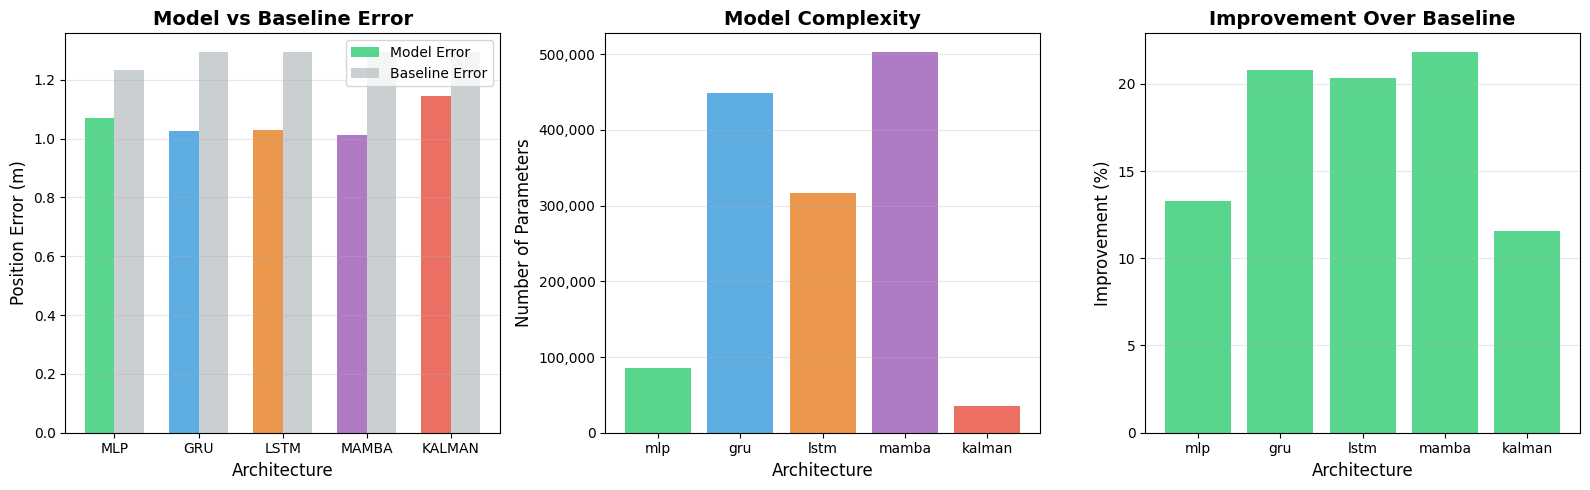

  ✓ Saved: /kaggle/working/Residual_Output/all_architectures_comparison.png


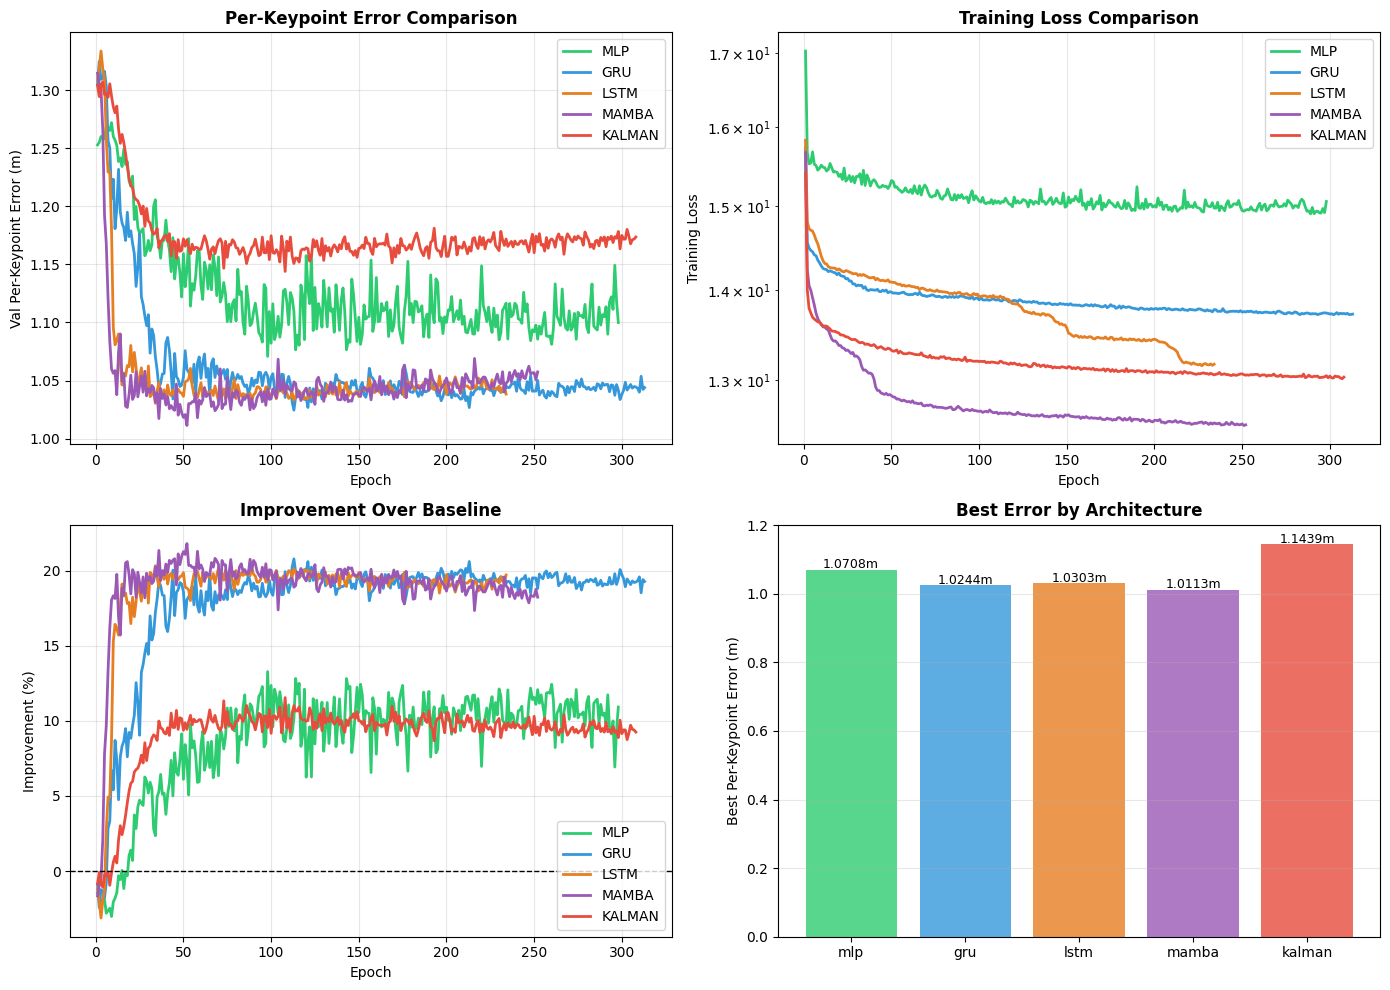


--- MLP Training History ---
  ✓ Saved: /kaggle/working/Residual_Output/mlp/plots/training_history.png
  ✓ Saved: /kaggle/working/Residual_Output/mlp/plots/progressive_horizon_results.png
  ✓ Saved progressive horizon results for mlp

--- GRU Training History ---
  ✓ Saved: /kaggle/working/Residual_Output/gru/plots/training_history.png
  ✓ Saved: /kaggle/working/Residual_Output/gru/plots/progressive_horizon_results.png
  ✓ Saved progressive horizon results for gru

--- LSTM Training History ---
  ✓ Saved: /kaggle/working/Residual_Output/lstm/plots/training_history.png
  ✓ Saved: /kaggle/working/Residual_Output/lstm/plots/progressive_horizon_results.png
  ✓ Saved progressive horizon results for lstm

--- MAMBA Training History ---
  ✓ Saved: /kaggle/working/Residual_Output/mamba/plots/training_history.png
  ✓ Saved: /kaggle/working/Residual_Output/mamba/plots/progressive_horizon_results.png
  ✓ Saved progressive horizon results for mamba

--- KALMAN Training History ---
  ✓ Saved: /kag

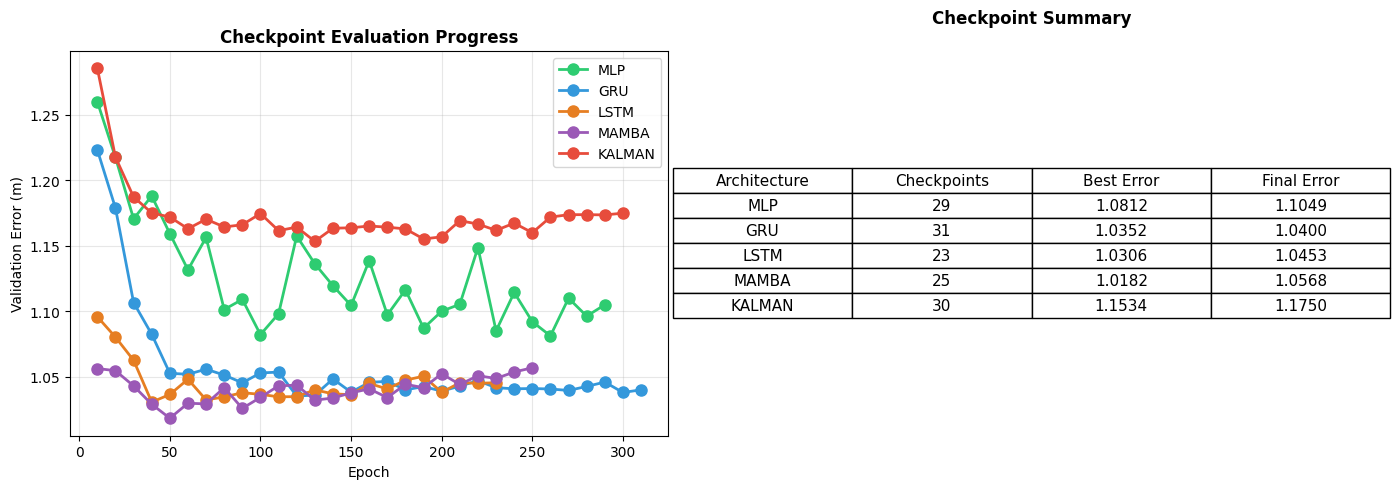


PER-JOINT AND DIRECTION/SPEED ANALYSIS

Analyzing MAMBA...
  ✓ Saved: /kaggle/working/Residual_Output/per_joint_errors.json
  ✓ Saved: /kaggle/working/Residual_Output/per_joint_errors.png


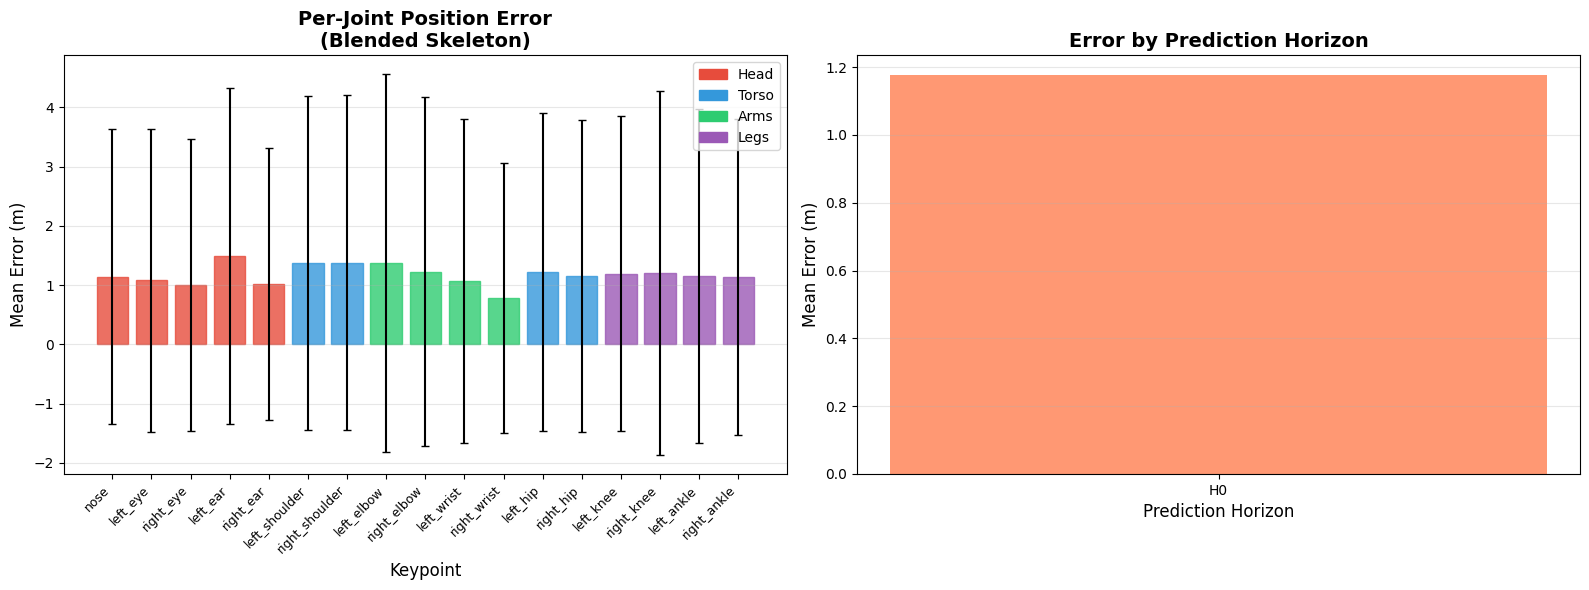

  ✓ Saved: /kaggle/working/Residual_Output/direction_speed_errors.json
  ✓ Saved: /kaggle/working/Residual_Output/direction_speed_errors.png


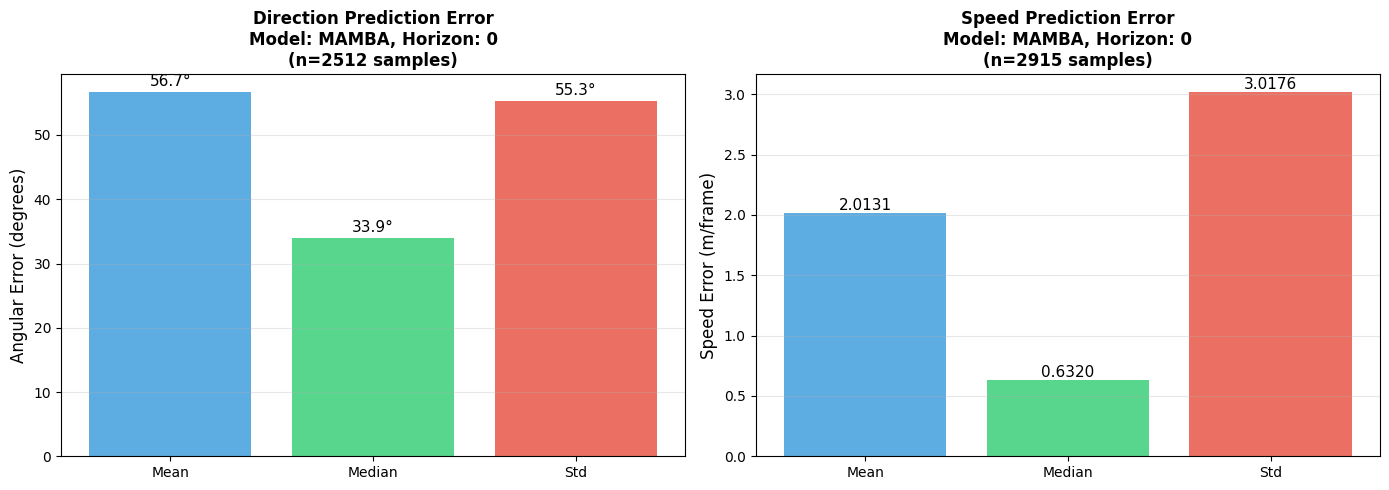

  ✓ Saved: /kaggle/working/Residual_Output/errors_per_epoch_per_architecture.png


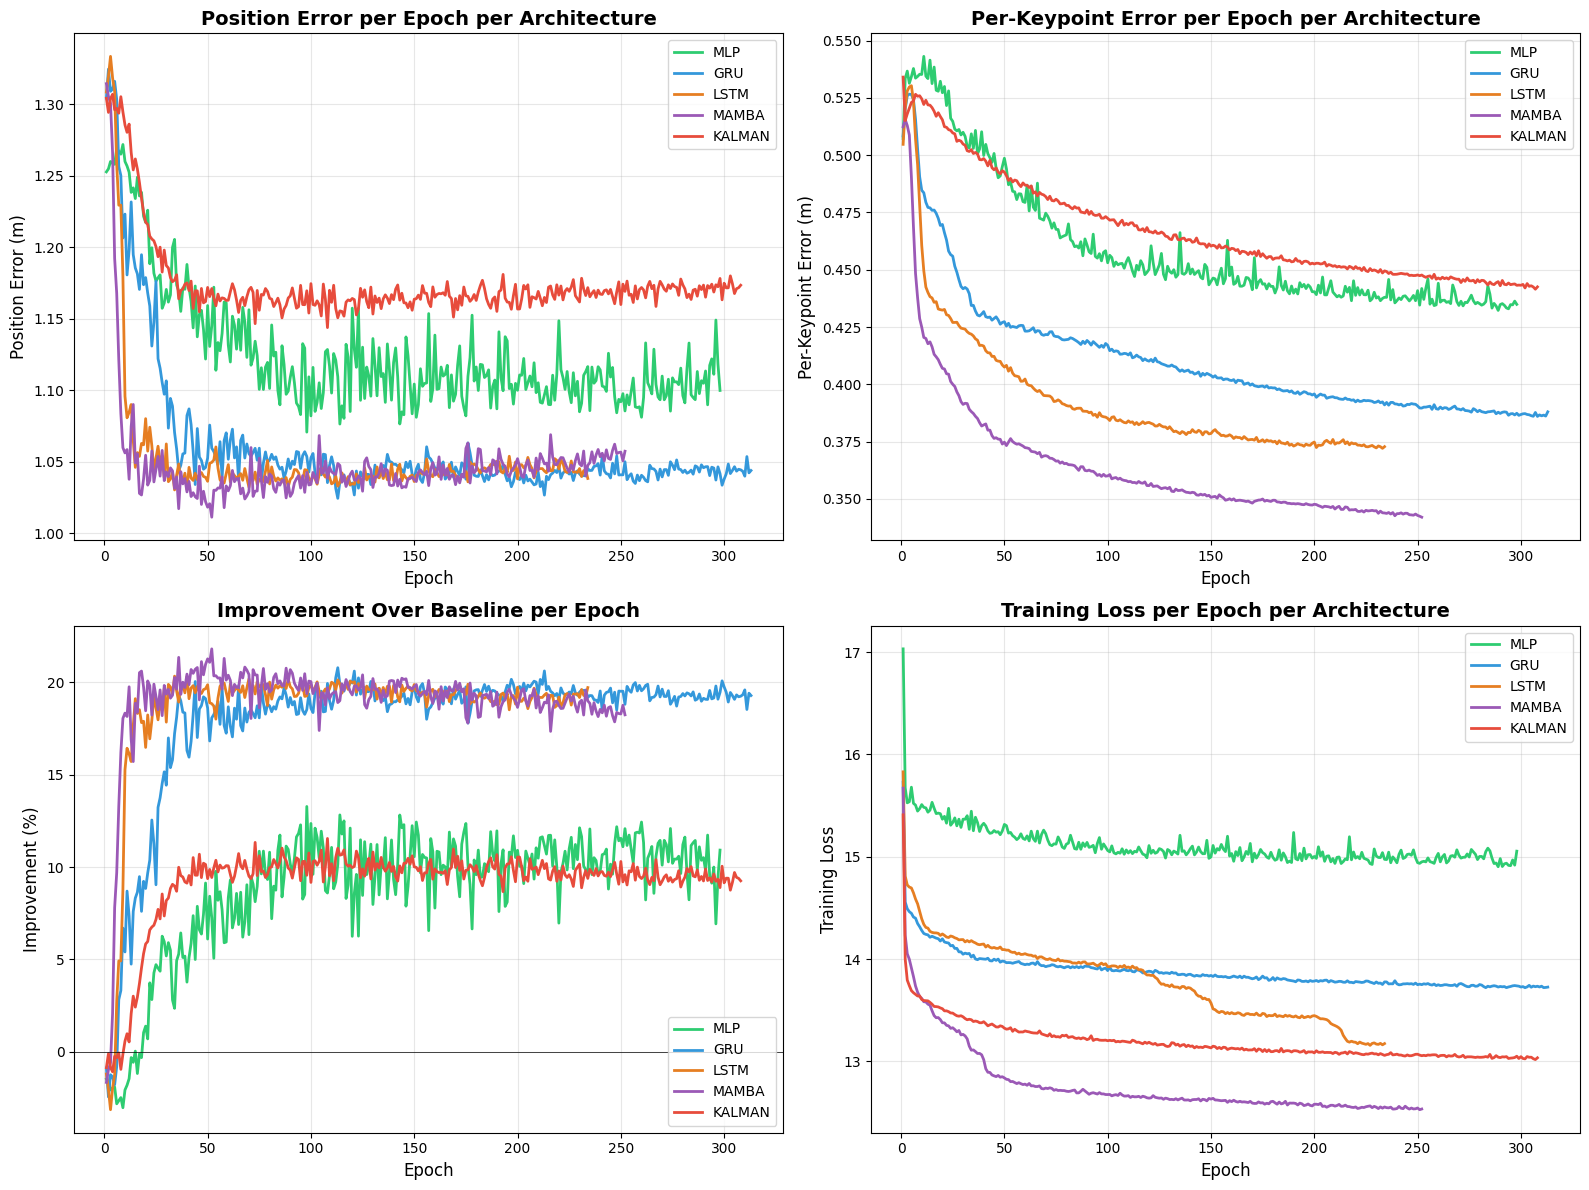

  ✓ Saved: /kaggle/working/Residual_Output/errors_per_horizon_per_architecture.png


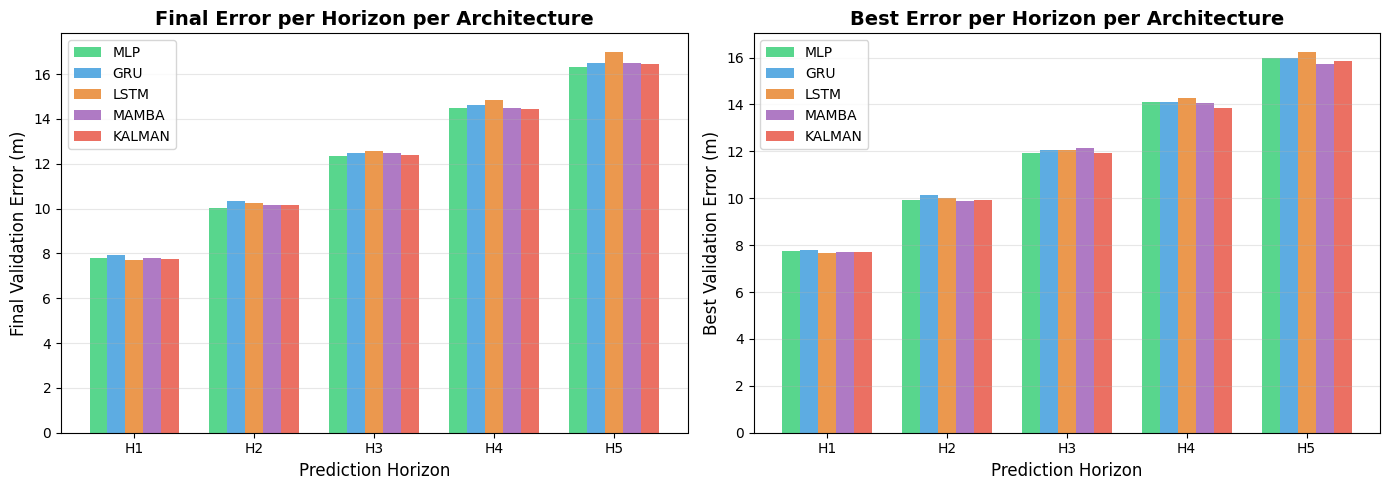


=== Running threshold analysis on best architecture: MAMBA ===

THRESHOLD ANALYSIS
Testing confidence values: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
Testing keypoint values:   [4, 6, 8, 10, 12]
Total combinations: 30
  conf=0.3, min_kp= 4: Recall=1.000, Error=1.260m, Matches=2730/2730
  conf=0.3, min_kp= 6: Recall=1.000, Error=1.260m, Matches=2730/2730
  conf=0.3, min_kp= 8: Recall=1.000, Error=1.260m, Matches=2730/2730
  conf=0.3, min_kp=10: Recall=0.880, Error=1.089m, Matches=2403/2730
  conf=0.3, min_kp=12: Recall=0.740, Error=0.867m, Matches=2021/2730
  conf=0.4, min_kp= 4: Recall=1.000, Error=1.260m, Matches=2730/2730
  conf=0.4, min_kp= 6: Recall=1.000, Error=1.260m, Matches=2730/2730
  conf=0.4, min_kp= 8: Recall=1.000, Error=1.260m, Matches=2730/2730
  conf=0.4, min_kp=10: Recall=0.880, Error=1.089m, Matches=2403/2730
  conf=0.4, min_kp=12: Recall=0.740, Error=0.867m, Matches=2021/2730
  conf=0.5, min_kp= 4: Recall=1.000, Error=1.260m, Matches=2730/2730
  conf=0.5, min_kp= 6: Recall=1

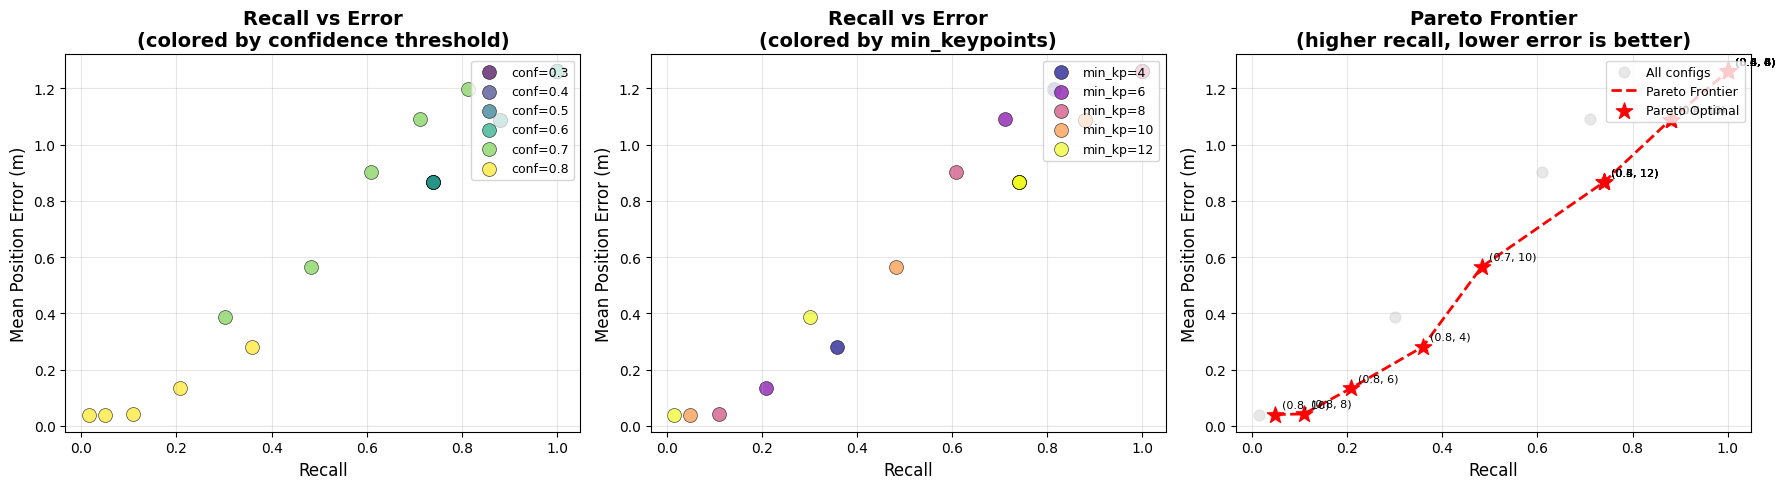


PEDESTRIAN TRACKING WITH MAMBA

📊 Tracking Statistics:
   Total Tracks: 83
   Active: 4
   Avg Length: 7.3 frames
  ✓ Saved: /kaggle/working/Residual_Output/tracking_statistics.png


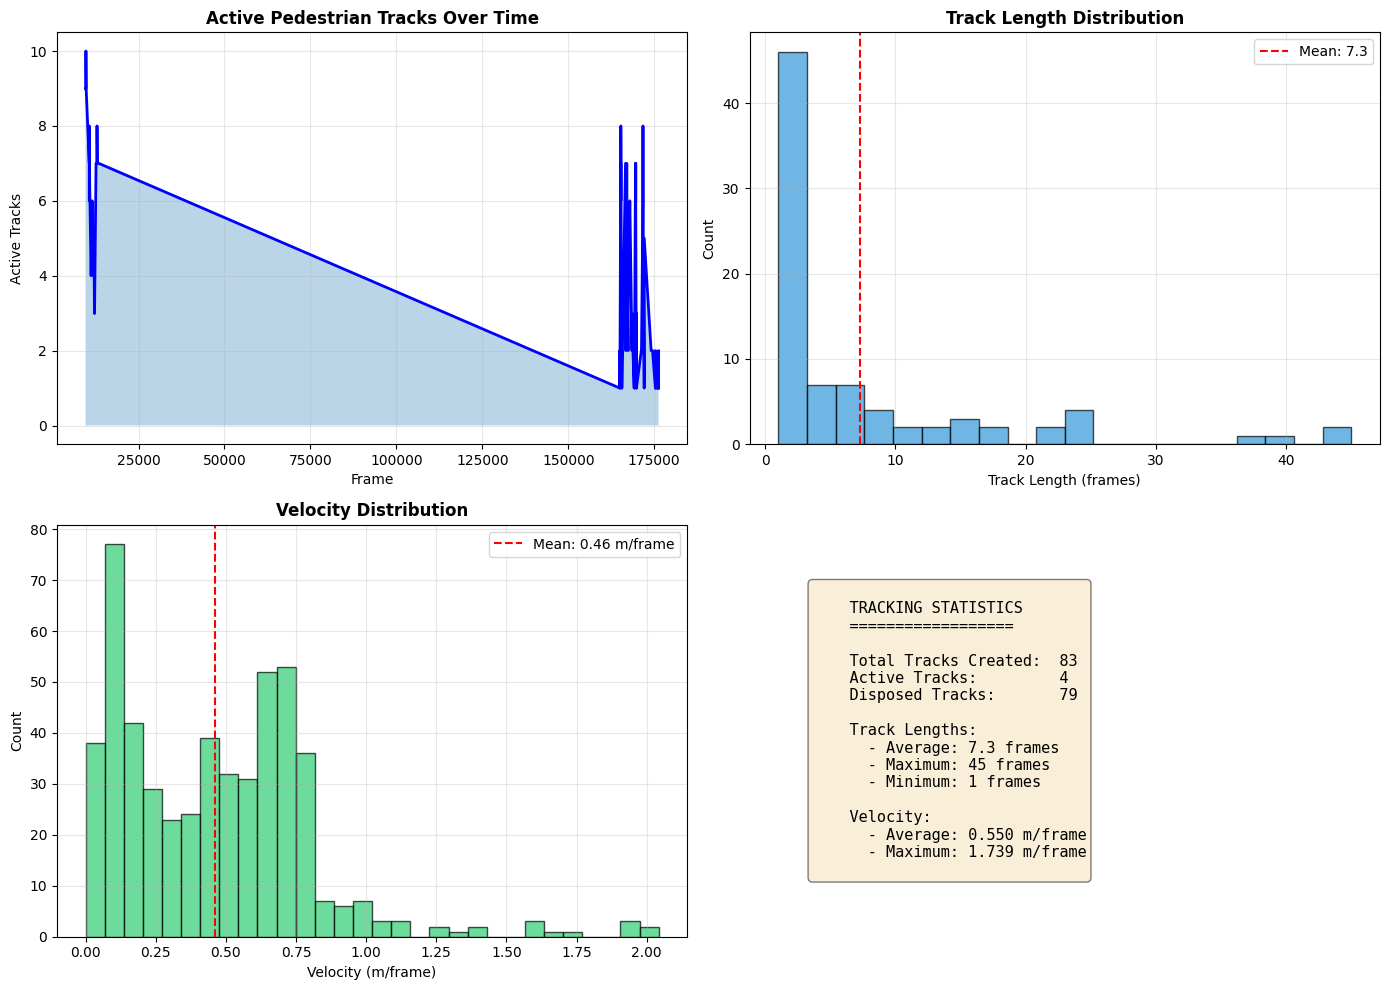

  ✓ Saved: /kaggle/working/Residual_Output/trajectory_predictions.png


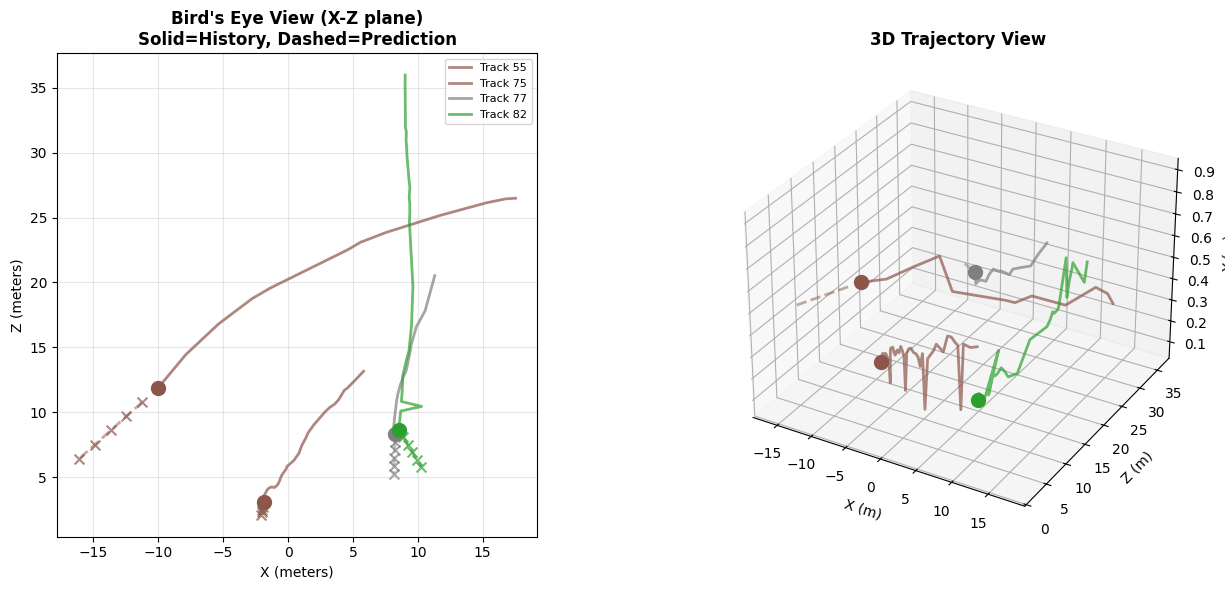


GENERATING BEST SEQUENCE VISUALIZATIONS FOR ALL ARCHITECTURES

--- MLP Architecture ---

FINDING BEST 5-FRAME PREDICTION SEQUENCE

Best sequence found:
  - Sequence index: 25
  - Starting frame: 288
  - Total per-joint error: 8.0590m
  - Mean error per frame: 1.6118m

Per-frame errors:
  Frame 1: Mean=0.1144m, Max=0.2846m, Min=0.0301m
  Frame 2: Mean=0.0978m, Max=0.2500m, Min=0.0236m
  Frame 3: Mean=0.0886m, Max=0.2274m, Min=0.0141m
  Frame 4: Mean=0.0776m, Max=0.1770m, Min=0.0157m
  Frame 5: Mean=0.0956m, Max=0.1783m, Min=0.0342m

Creating visualizations...
Saved per-frame comparison to /kaggle/working/Residual_Output/mlp/best_sequence/skeleton_per_frame_comparison.png


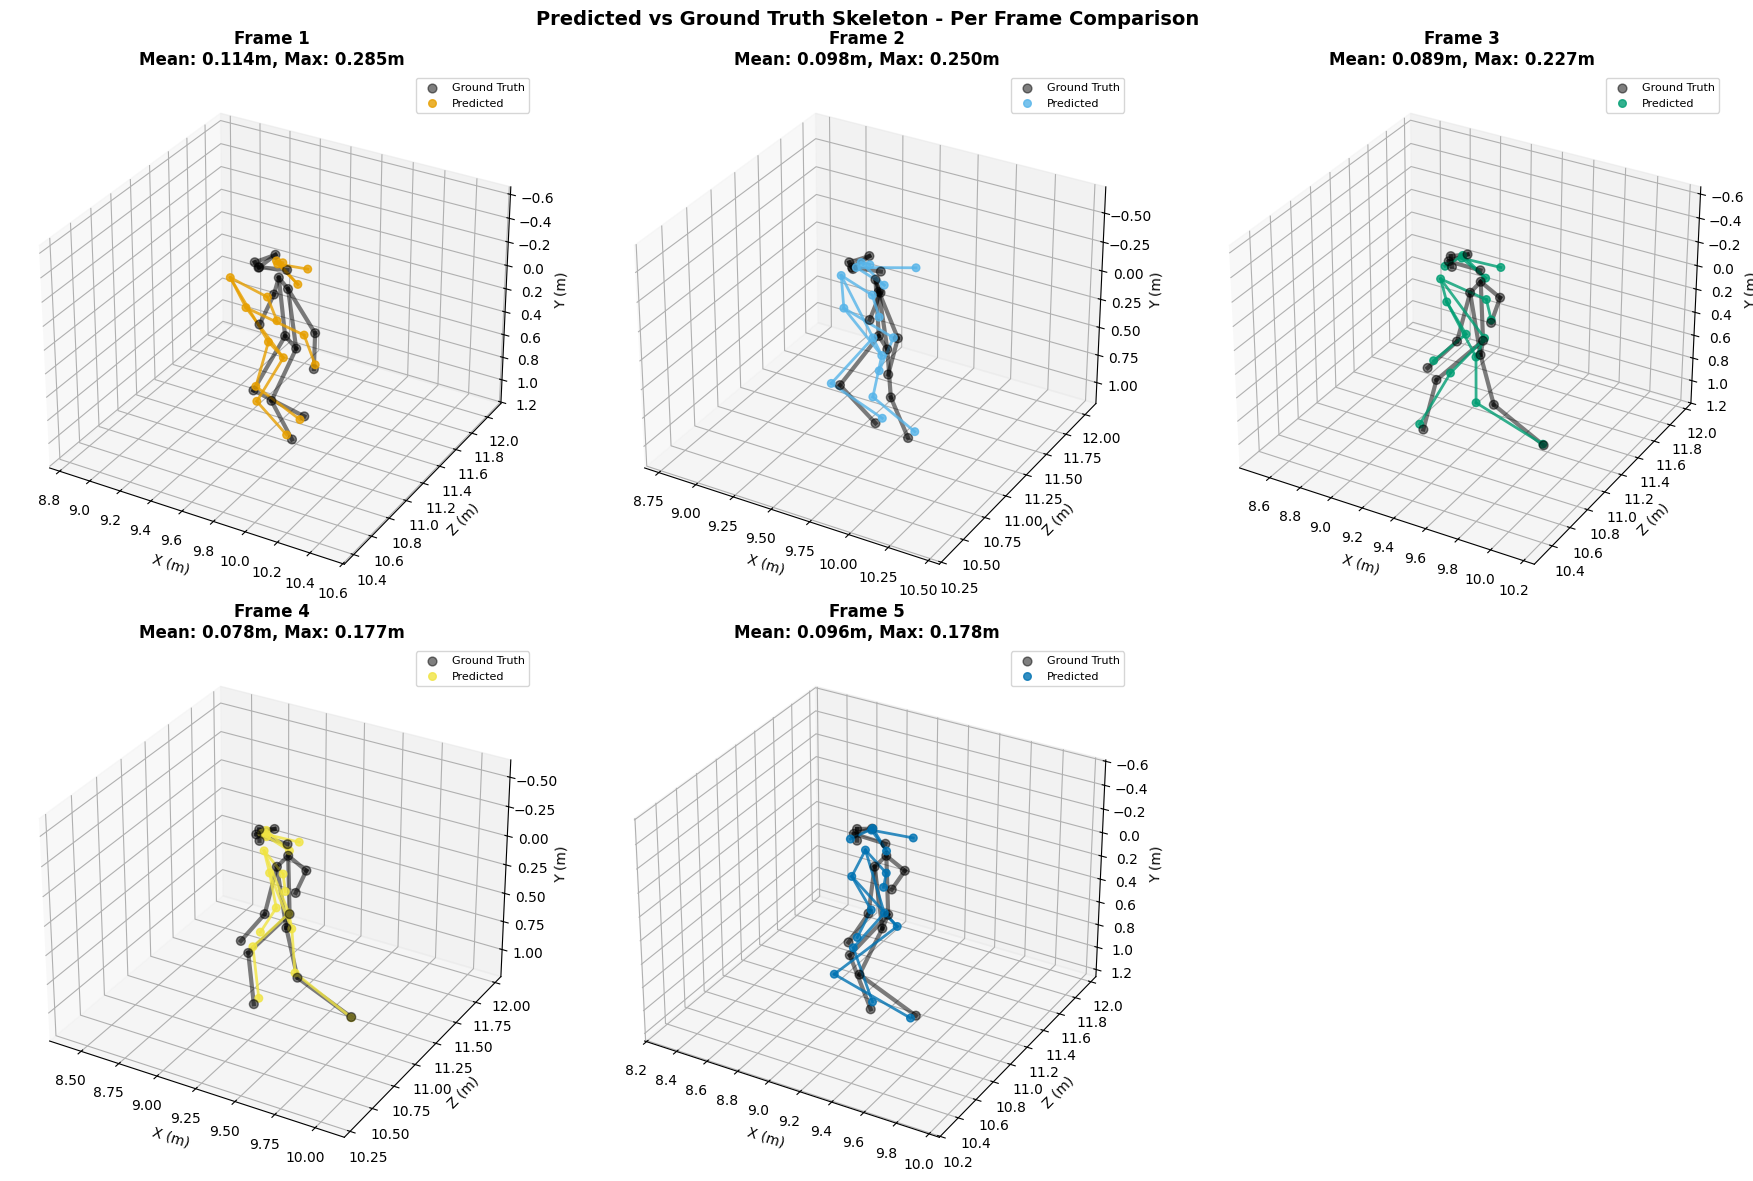

Saved combined view to /kaggle/working/Residual_Output/mlp/best_sequence/skeleton_combined_all_frames.png


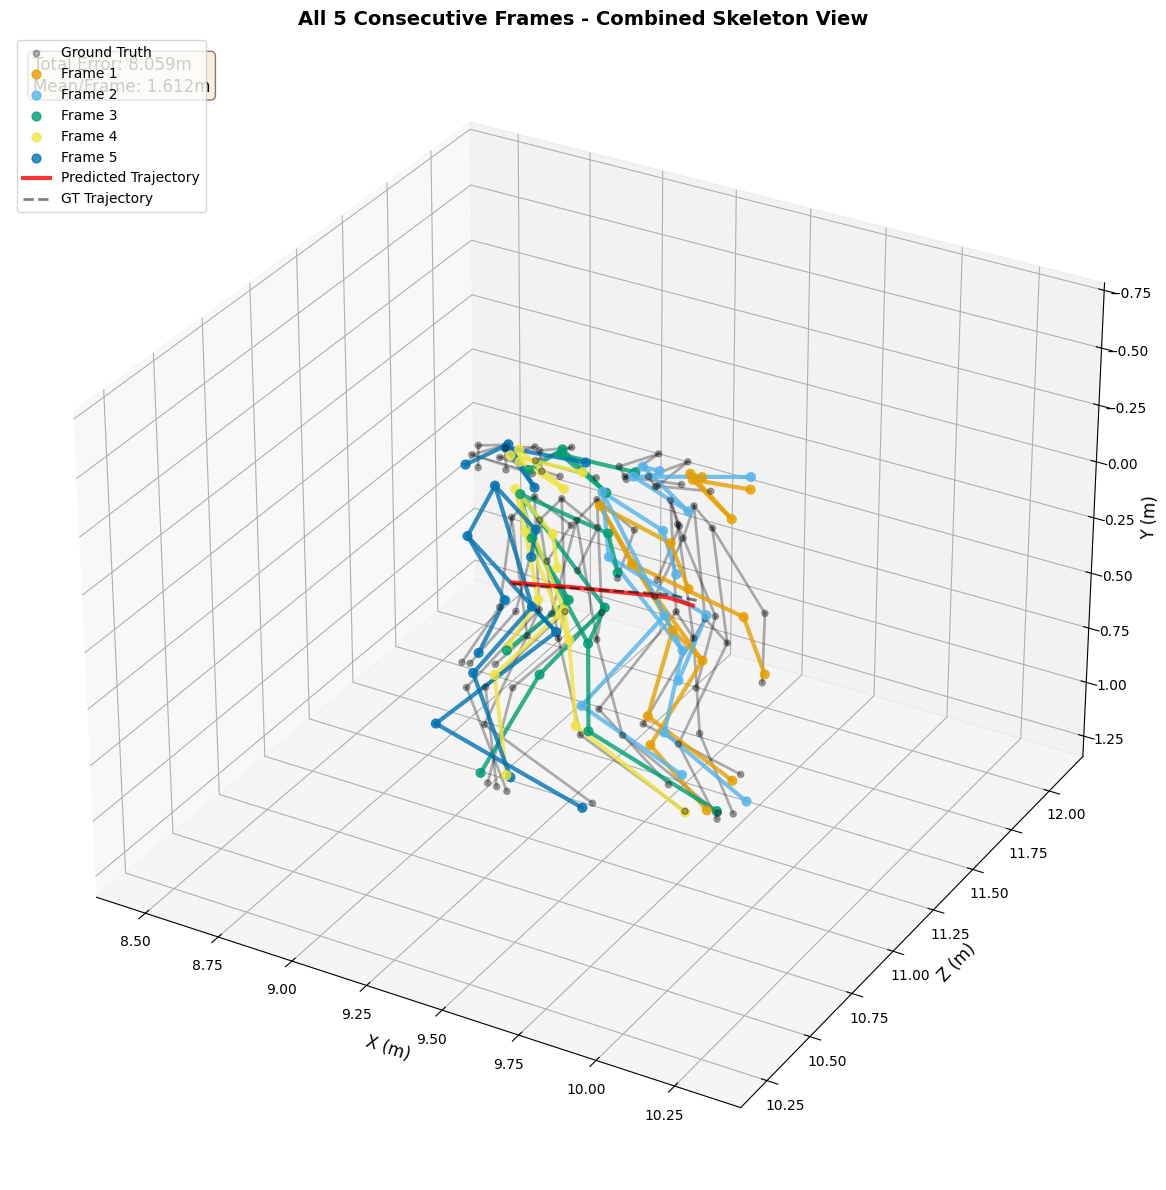

Saved error heatmap to /kaggle/working/Residual_Output/mlp/best_sequence/skeleton_error_heatmap.png


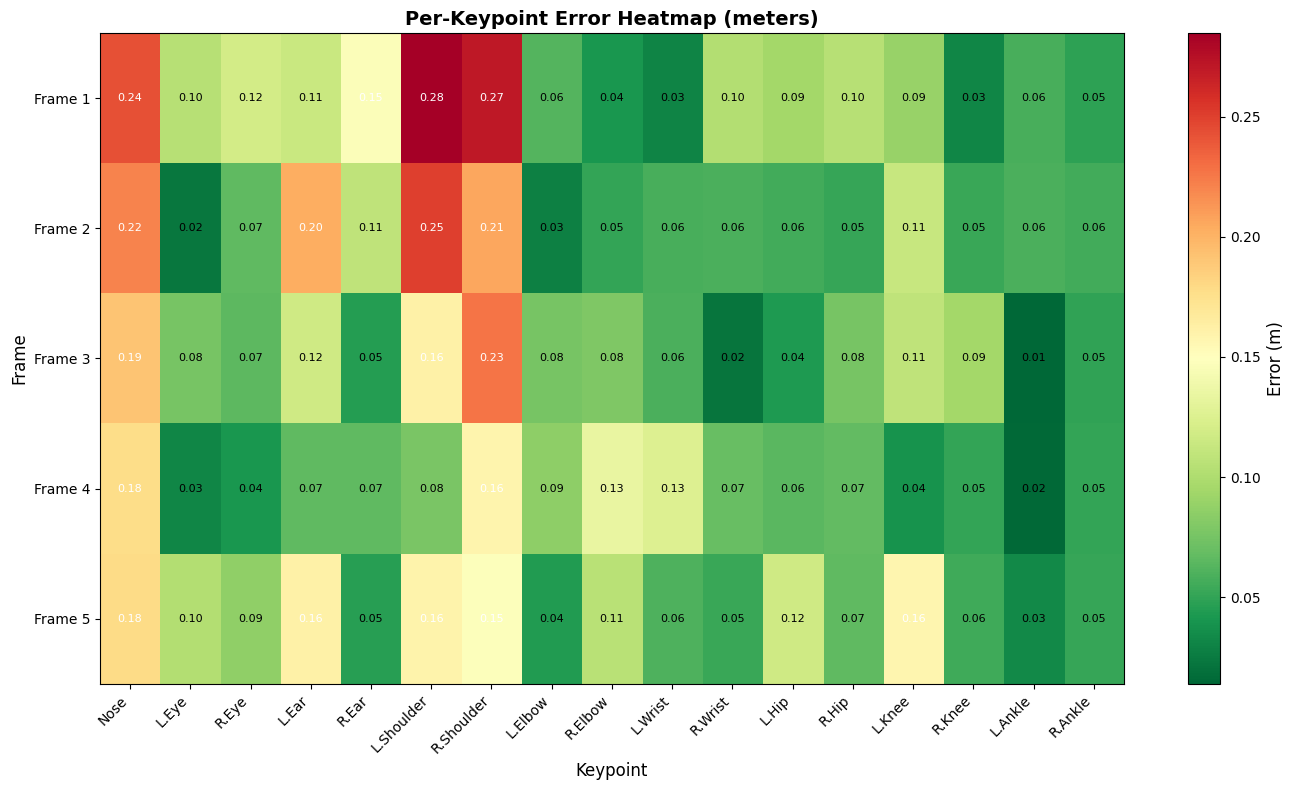

  ✓ Generated visualizations for mlp

--- GRU Architecture ---

FINDING BEST 5-FRAME PREDICTION SEQUENCE

Best sequence found:
  - Sequence index: 5
  - Starting frame: 98
  - Total per-joint error: 6.7094m
  - Mean error per frame: 1.3419m

Per-frame errors:
  Frame 1: Mean=0.0749m, Max=0.2492m, Min=0.0156m
  Frame 2: Mean=0.0795m, Max=0.2444m, Min=0.0099m
  Frame 3: Mean=0.0776m, Max=0.2480m, Min=0.0199m
  Frame 4: Mean=0.0862m, Max=0.2810m, Min=0.0024m
  Frame 5: Mean=0.0764m, Max=0.2270m, Min=0.0117m

Creating visualizations...
Saved per-frame comparison to /kaggle/working/Residual_Output/gru/best_sequence/skeleton_per_frame_comparison.png


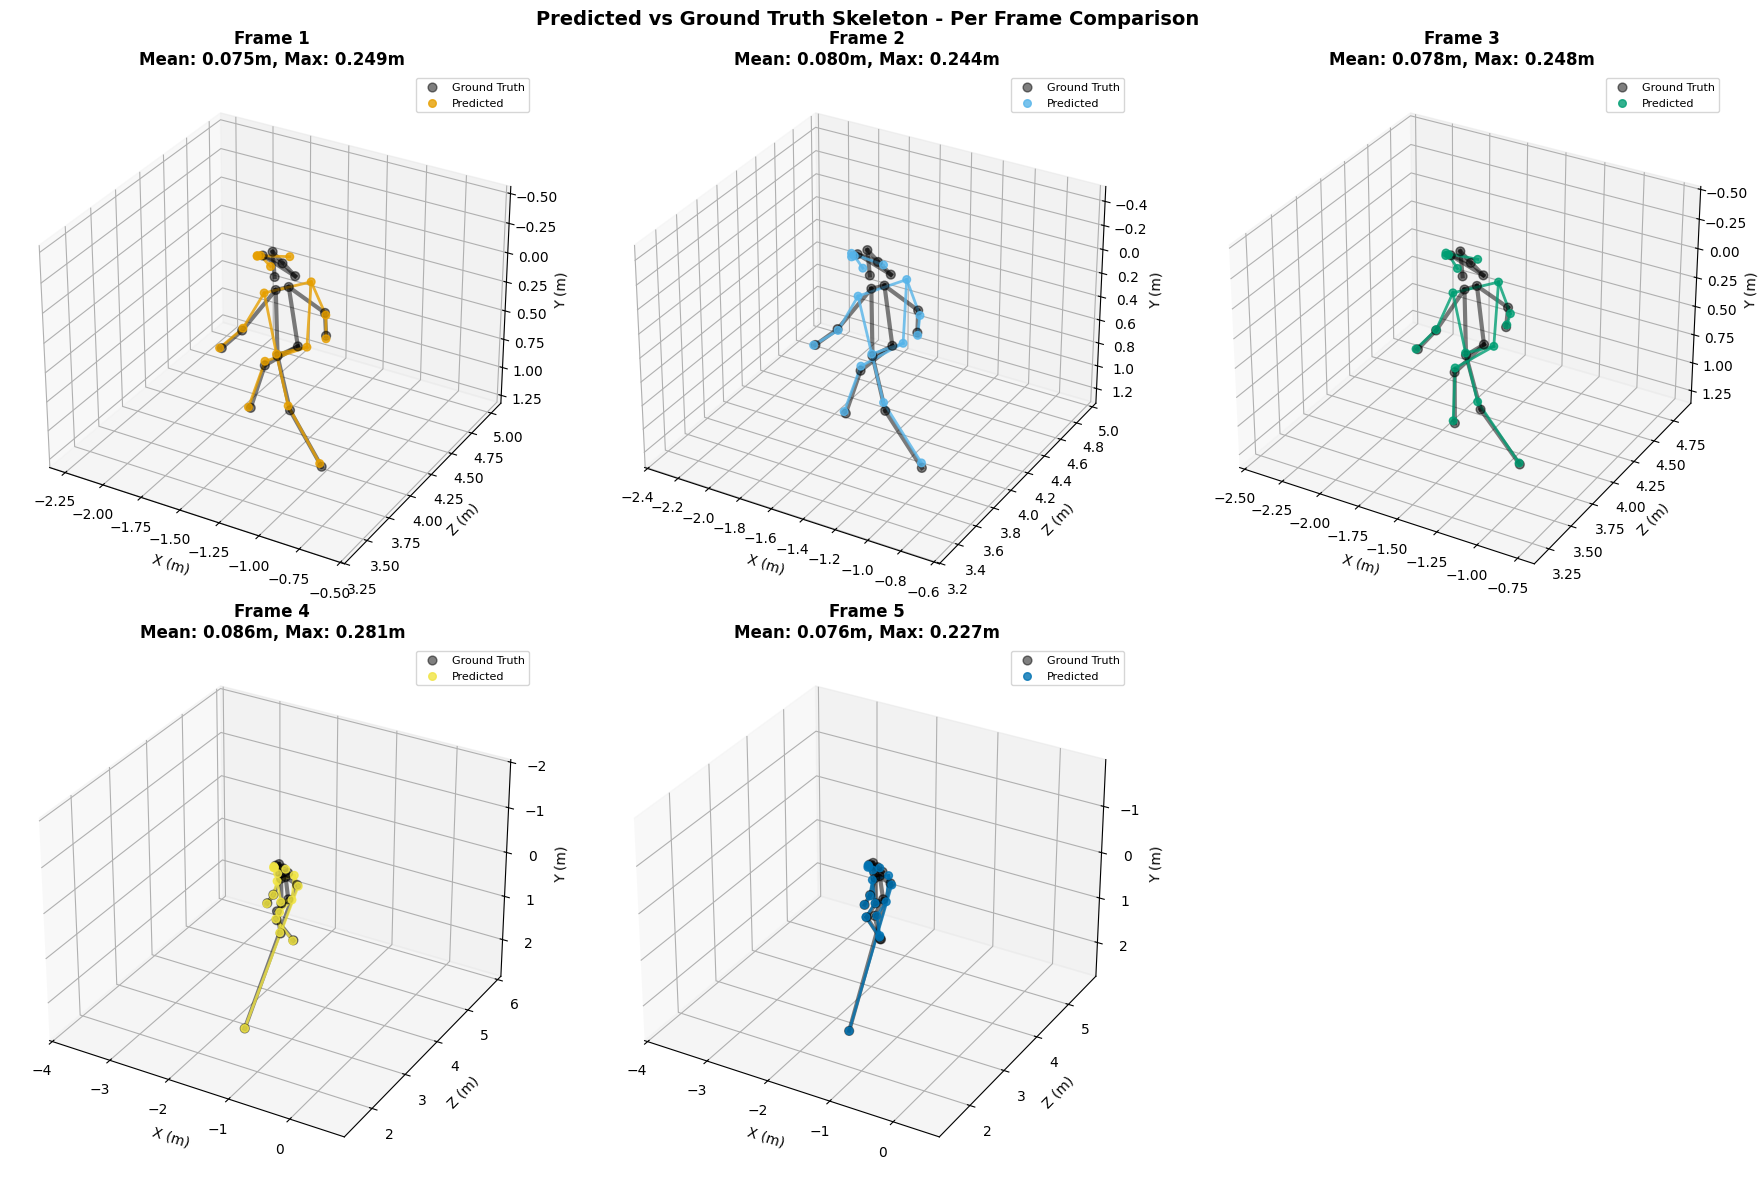

Saved combined view to /kaggle/working/Residual_Output/gru/best_sequence/skeleton_combined_all_frames.png


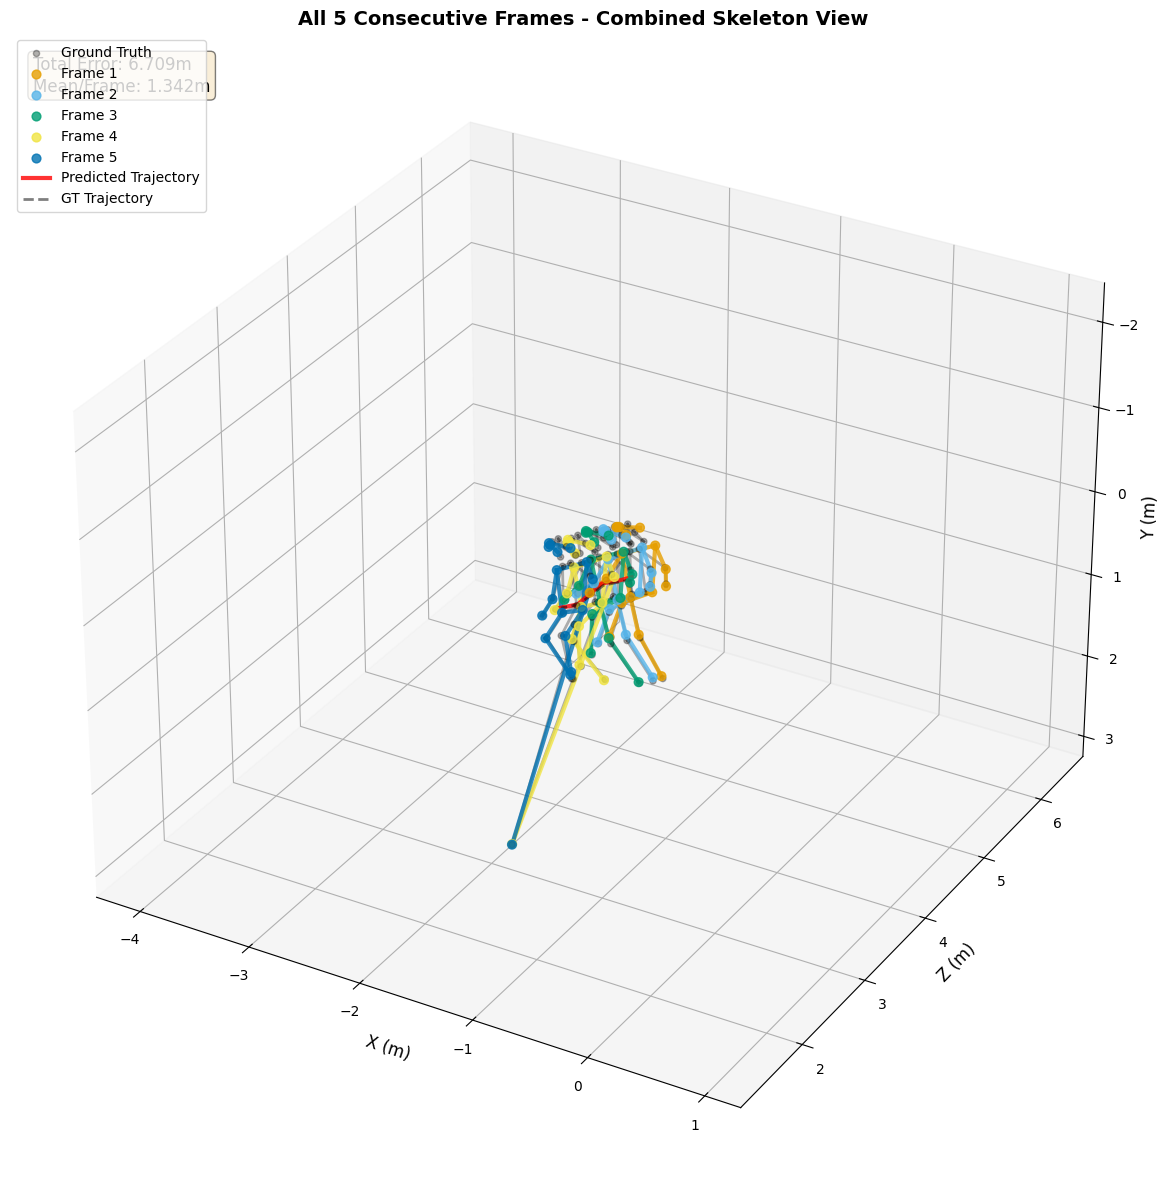

Saved error heatmap to /kaggle/working/Residual_Output/gru/best_sequence/skeleton_error_heatmap.png


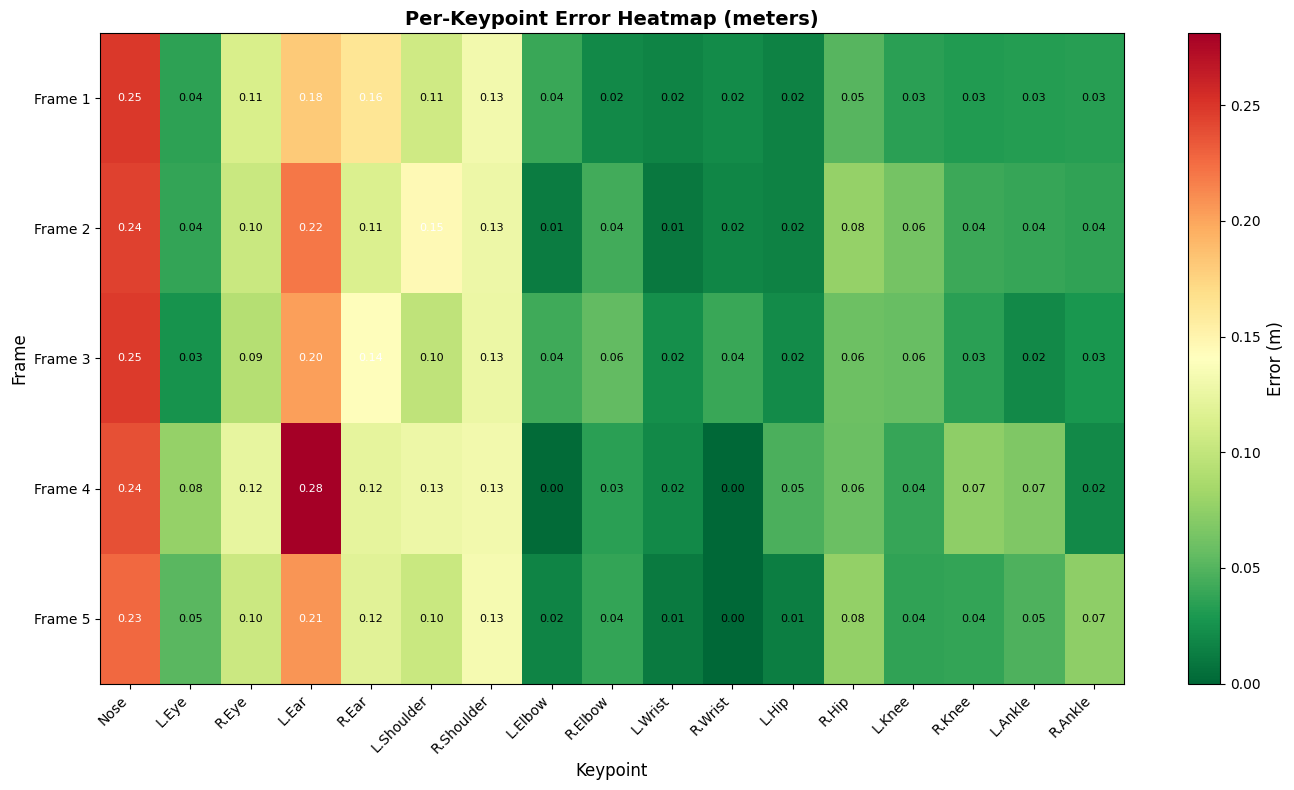

  ✓ Generated visualizations for gru

--- LSTM Architecture ---

FINDING BEST 5-FRAME PREDICTION SEQUENCE

Best sequence found:
  - Sequence index: 5
  - Starting frame: 97
  - Total per-joint error: 7.3552m
  - Mean error per frame: 1.4710m

Per-frame errors:
  Frame 1: Mean=0.0872m, Max=0.2561m, Min=0.0153m
  Frame 2: Mean=0.0813m, Max=0.2584m, Min=0.0155m
  Frame 3: Mean=0.0853m, Max=0.2528m, Min=0.0099m
  Frame 4: Mean=0.0827m, Max=0.2547m, Min=0.0199m
  Frame 5: Mean=0.0962m, Max=0.2926m, Min=0.0207m

Creating visualizations...
Saved per-frame comparison to /kaggle/working/Residual_Output/lstm/best_sequence/skeleton_per_frame_comparison.png


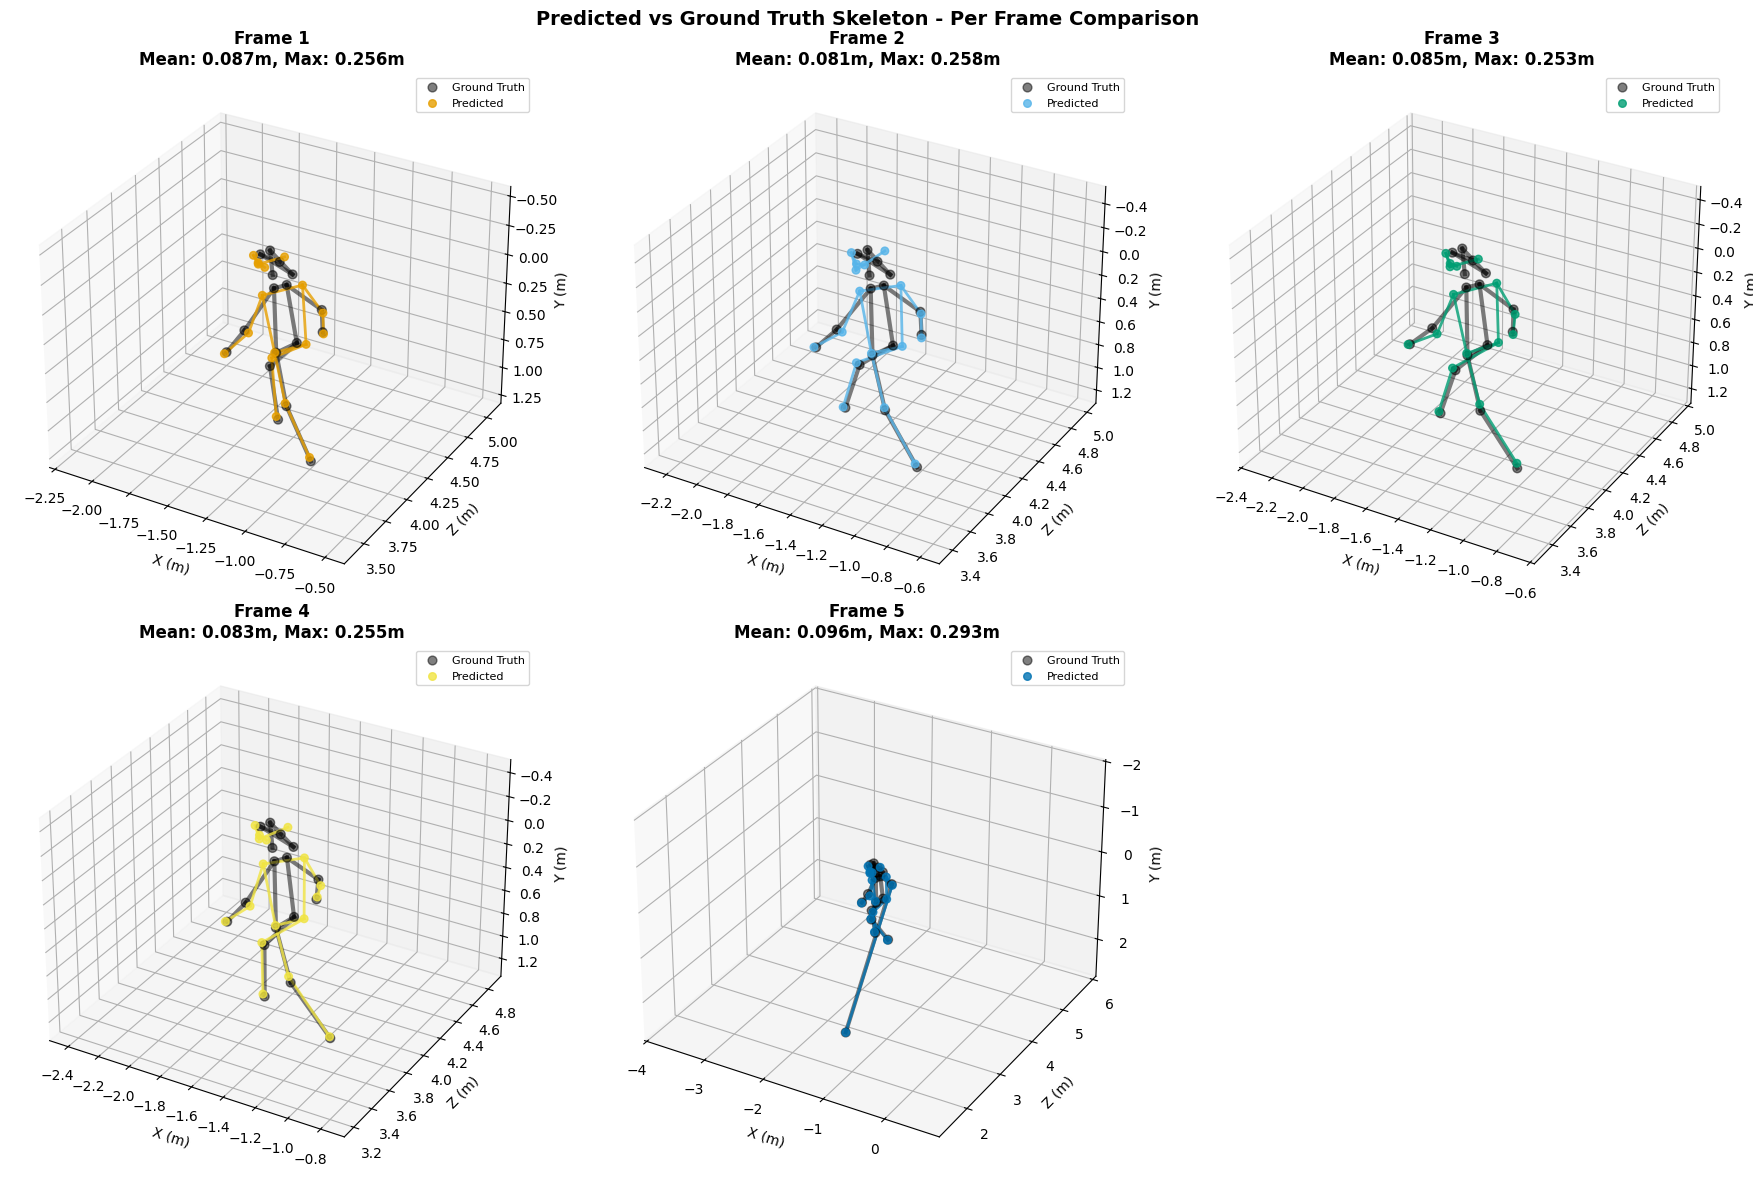

Saved combined view to /kaggle/working/Residual_Output/lstm/best_sequence/skeleton_combined_all_frames.png


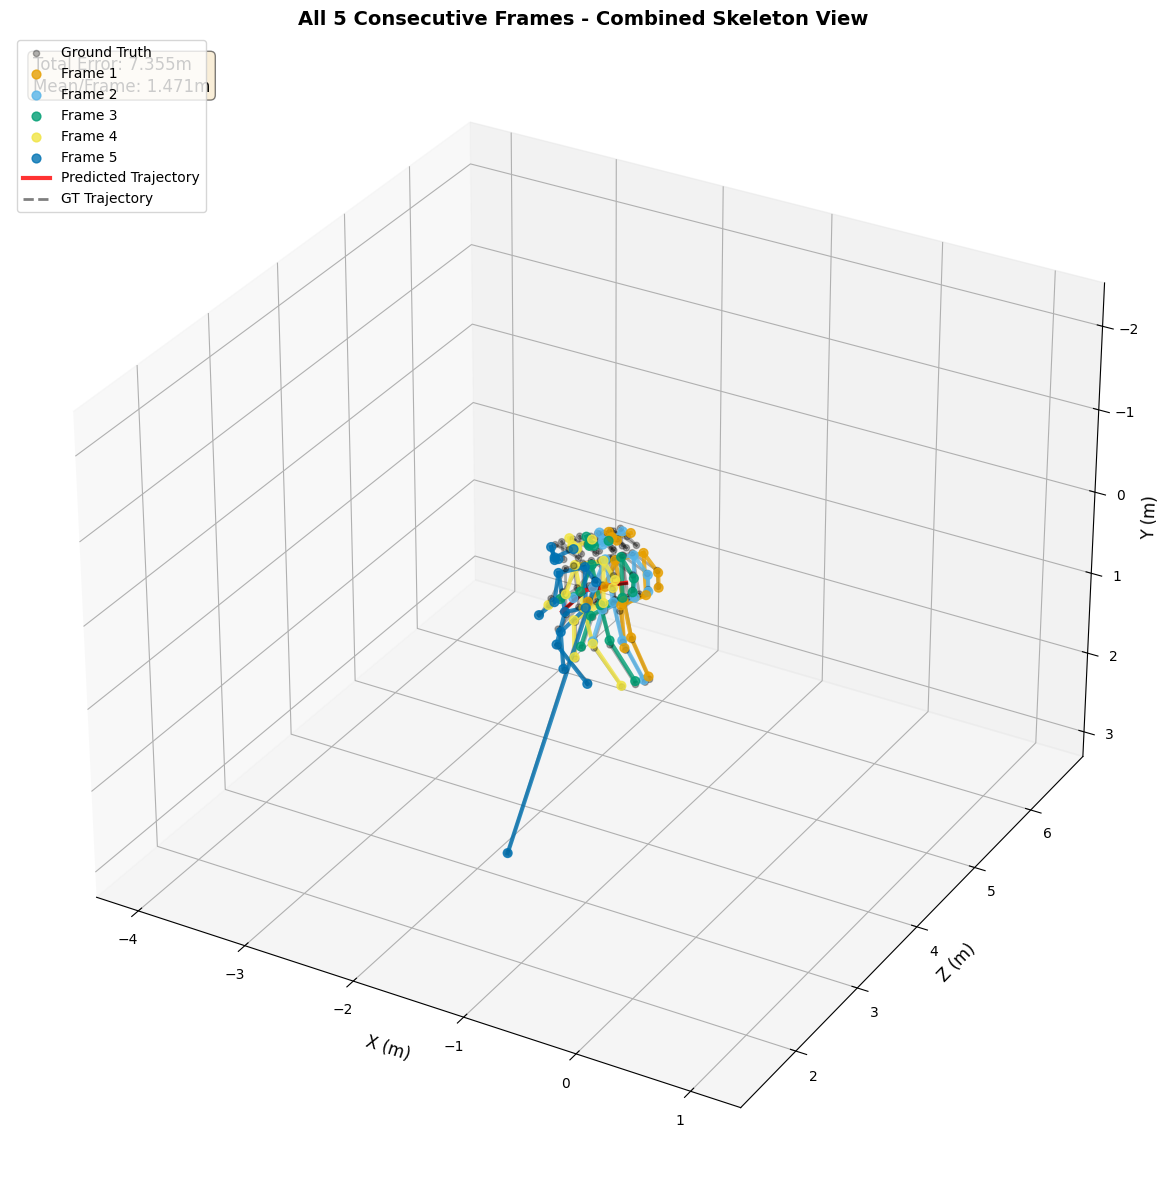

Saved error heatmap to /kaggle/working/Residual_Output/lstm/best_sequence/skeleton_error_heatmap.png


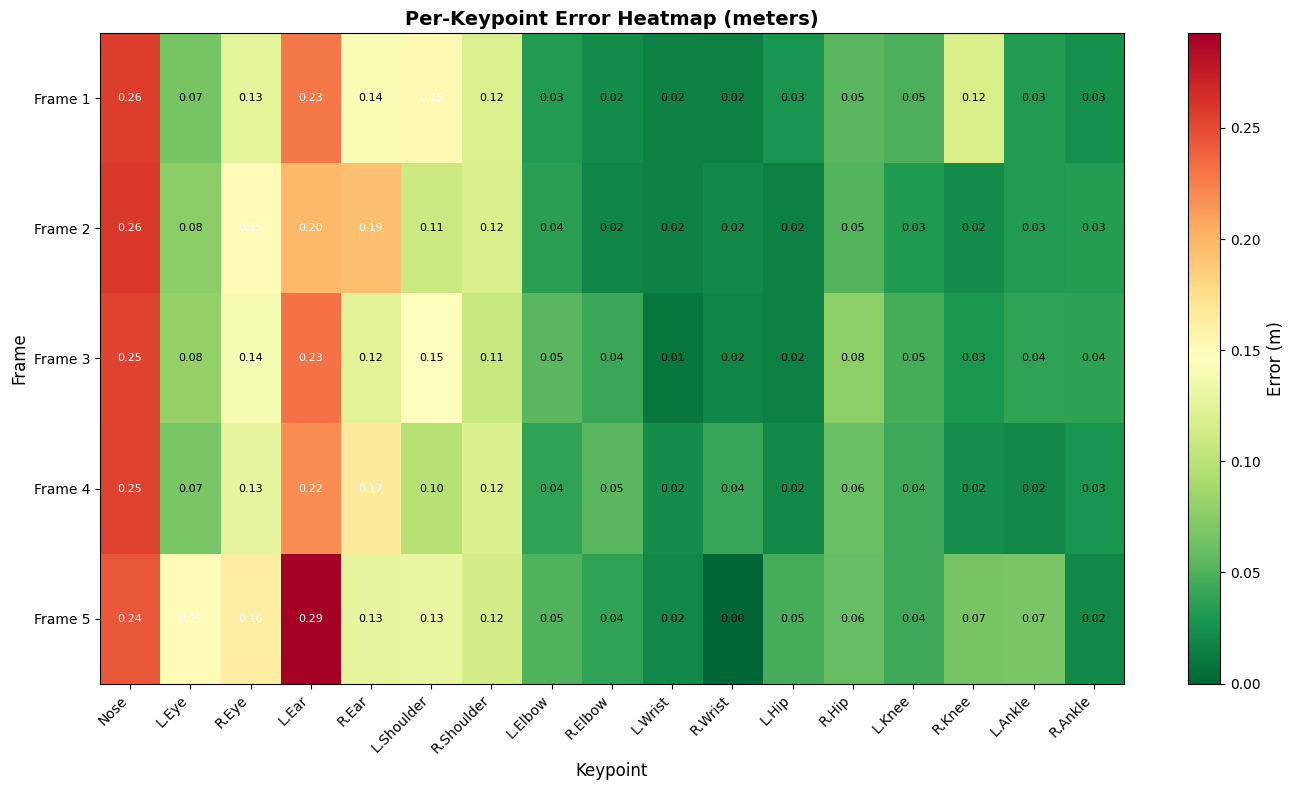

  ✓ Generated visualizations for lstm

--- MAMBA Architecture ---

FINDING BEST 5-FRAME PREDICTION SEQUENCE

Best sequence found:
  - Sequence index: 5
  - Starting frame: 97
  - Total per-joint error: 9.8294m
  - Mean error per frame: 1.9659m

Per-frame errors:
  Frame 1: Mean=0.0804m, Max=0.2485m, Min=0.0153m
  Frame 2: Mean=0.1038m, Max=0.4197m, Min=0.0155m
  Frame 3: Mean=0.1872m, Max=1.0710m, Min=0.0103m
  Frame 4: Mean=0.0880m, Max=0.2590m, Min=0.0199m
  Frame 5: Mean=0.1188m, Max=0.3990m, Min=0.0204m

Creating visualizations...
Saved per-frame comparison to /kaggle/working/Residual_Output/mamba/best_sequence/skeleton_per_frame_comparison.png


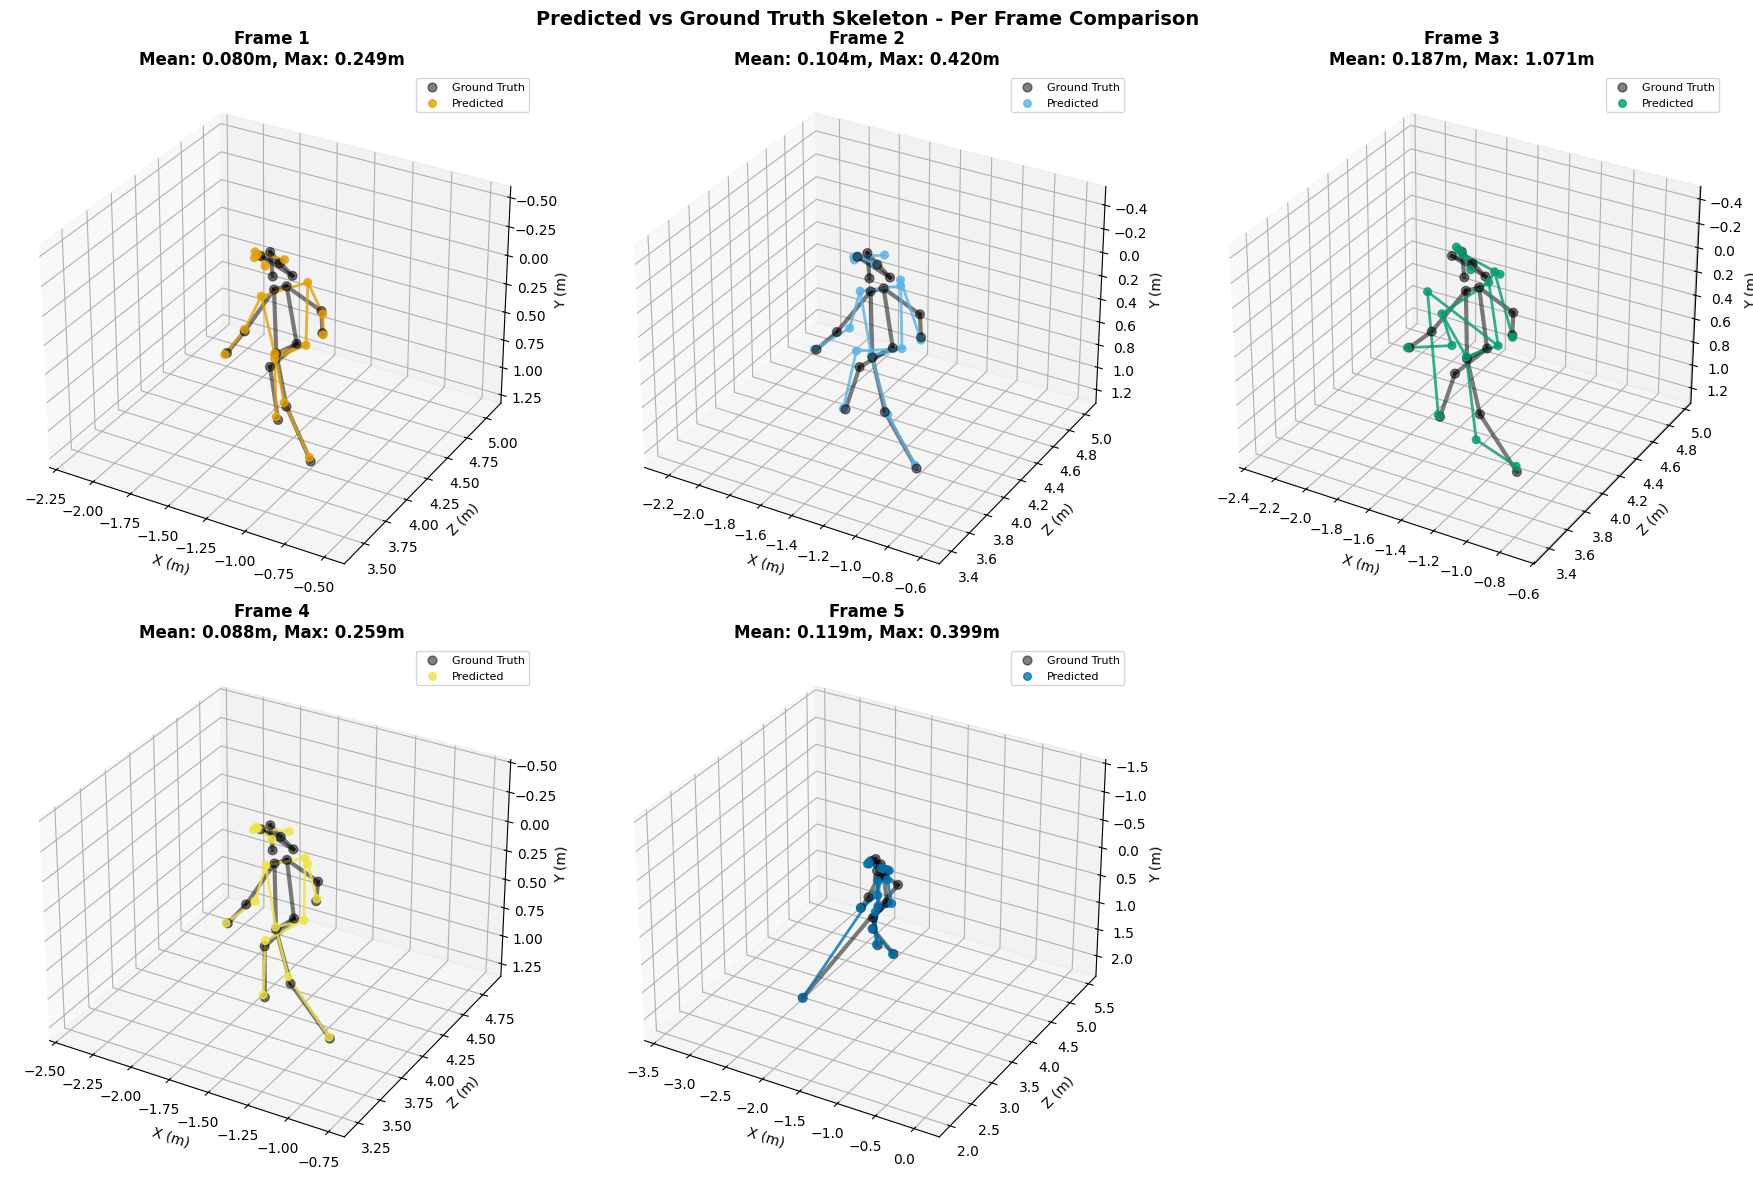

Saved combined view to /kaggle/working/Residual_Output/mamba/best_sequence/skeleton_combined_all_frames.png


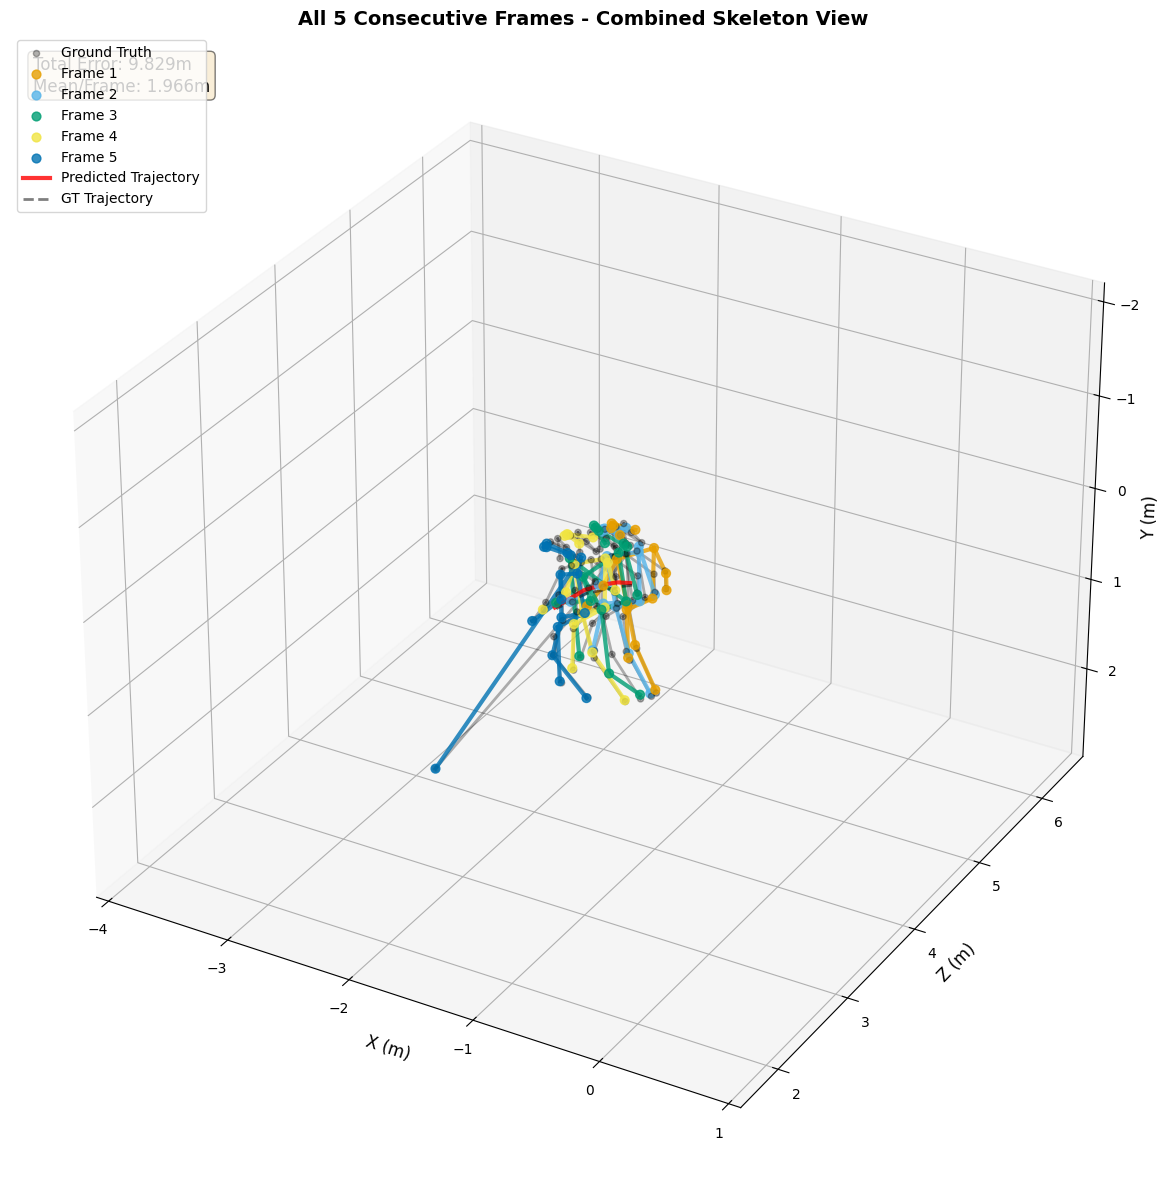

Saved error heatmap to /kaggle/working/Residual_Output/mamba/best_sequence/skeleton_error_heatmap.png


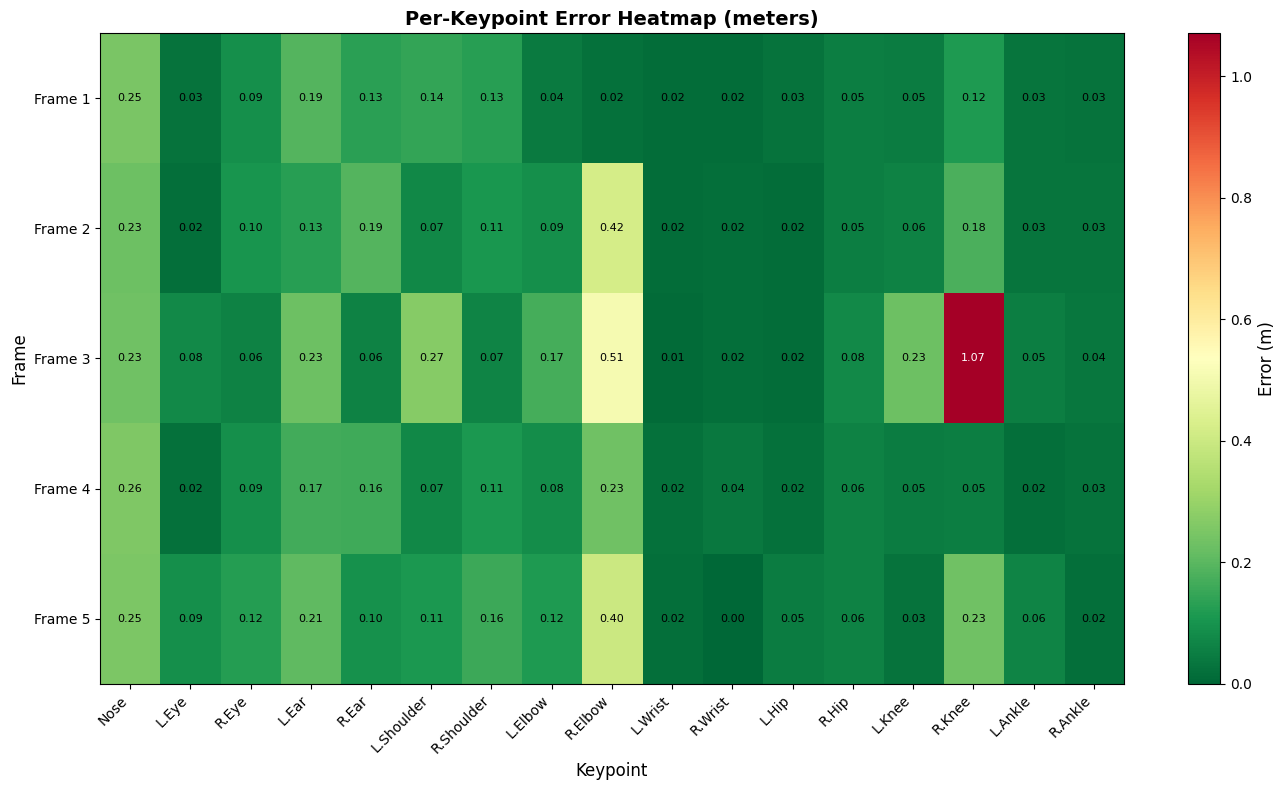

  ✓ Generated visualizations for mamba

--- KALMAN Architecture ---

FINDING BEST 5-FRAME PREDICTION SEQUENCE

Best sequence found:
  - Sequence index: 5
  - Starting frame: 98
  - Total per-joint error: 6.7077m
  - Mean error per frame: 1.3415m

Per-frame errors:
  Frame 1: Mean=0.0777m, Max=0.2502m, Min=0.0197m
  Frame 2: Mean=0.0806m, Max=0.2460m, Min=0.0163m
  Frame 3: Mean=0.0769m, Max=0.2489m, Min=0.0139m
  Frame 4: Mean=0.0838m, Max=0.2549m, Min=0.0023m
  Frame 5: Mean=0.0757m, Max=0.2238m, Min=0.0116m

Creating visualizations...
Saved per-frame comparison to /kaggle/working/Residual_Output/kalman/best_sequence/skeleton_per_frame_comparison.png


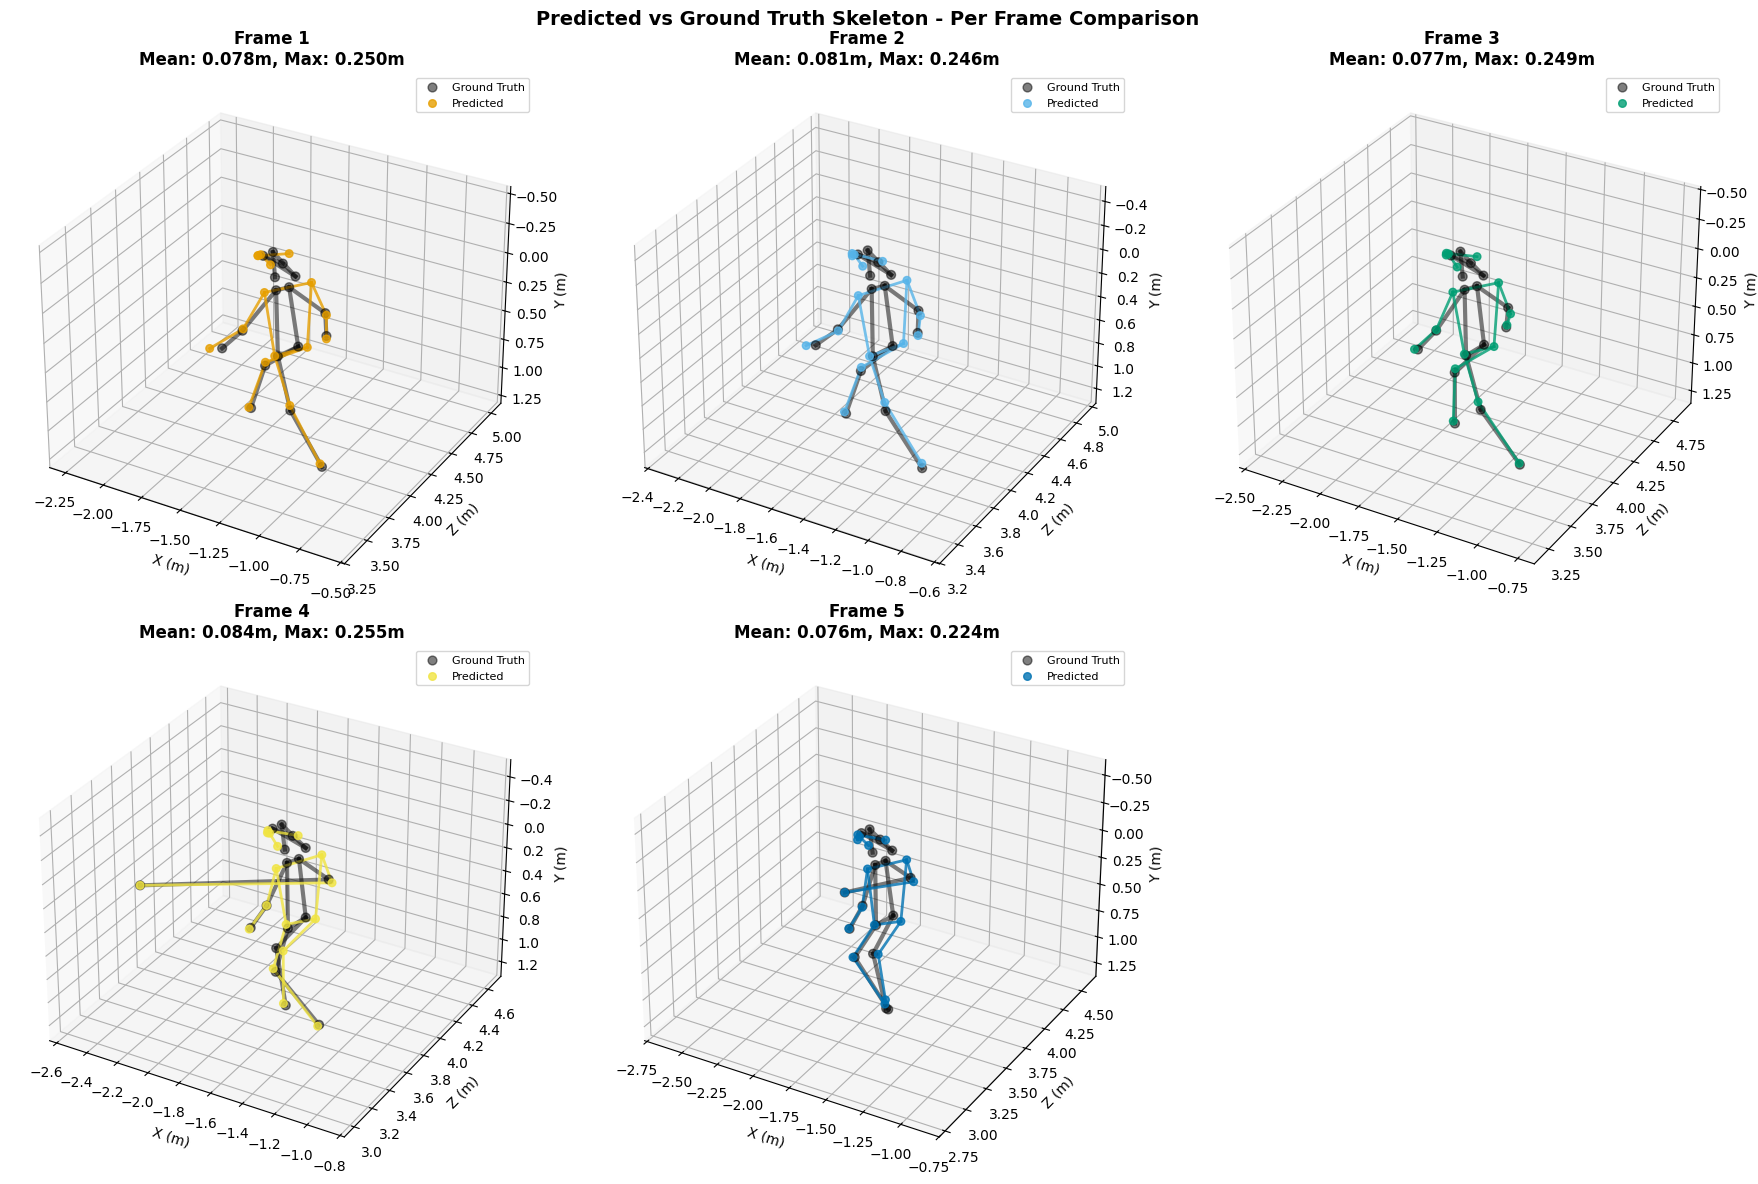

Saved combined view to /kaggle/working/Residual_Output/kalman/best_sequence/skeleton_combined_all_frames.png


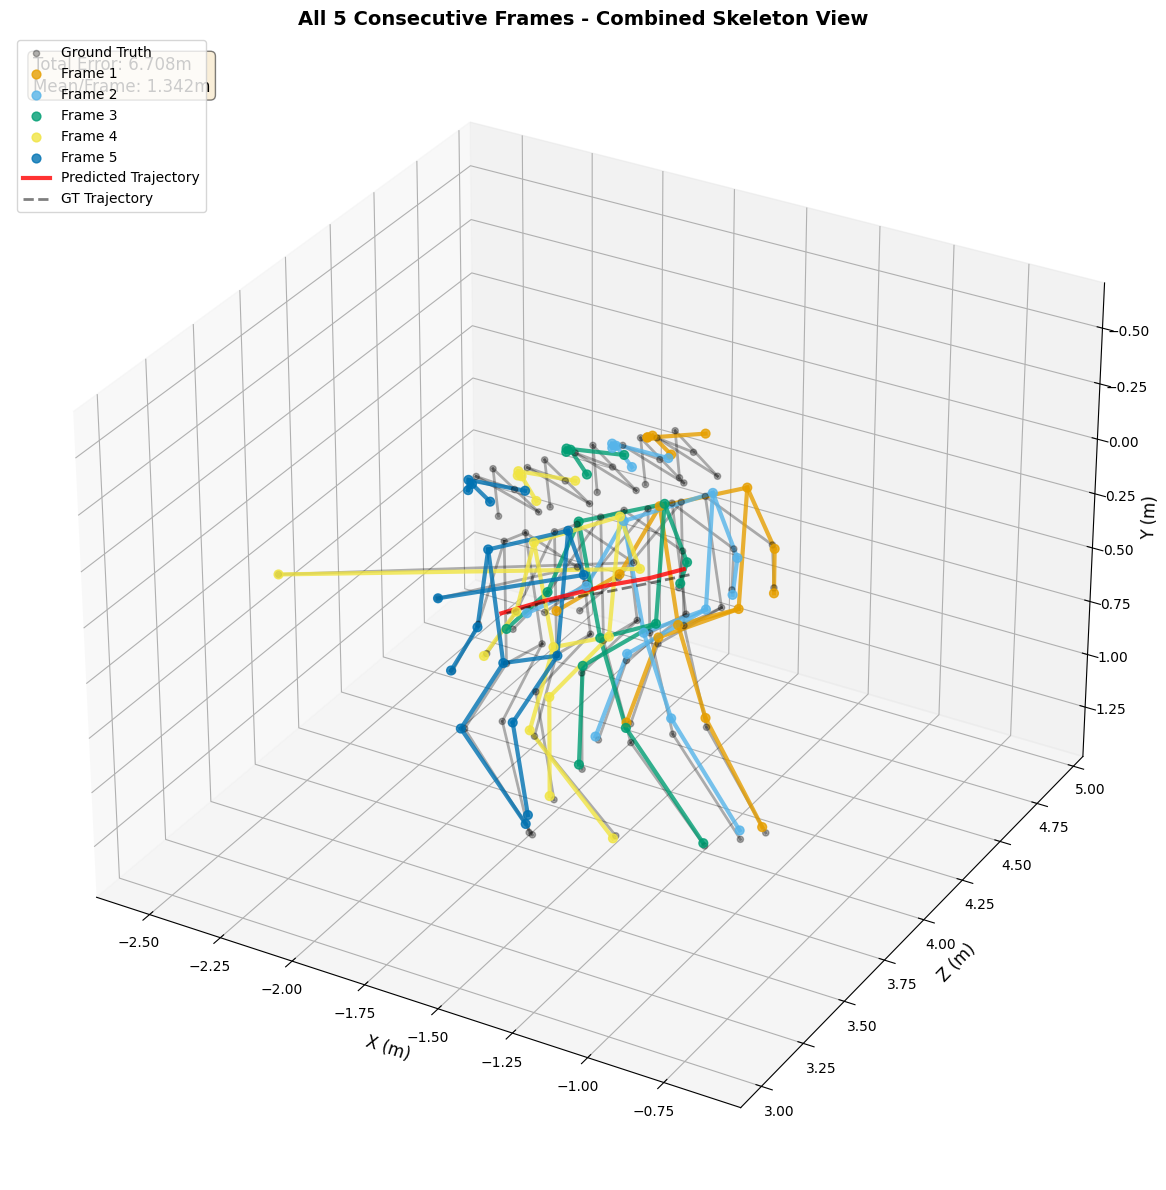

Saved error heatmap to /kaggle/working/Residual_Output/kalman/best_sequence/skeleton_error_heatmap.png


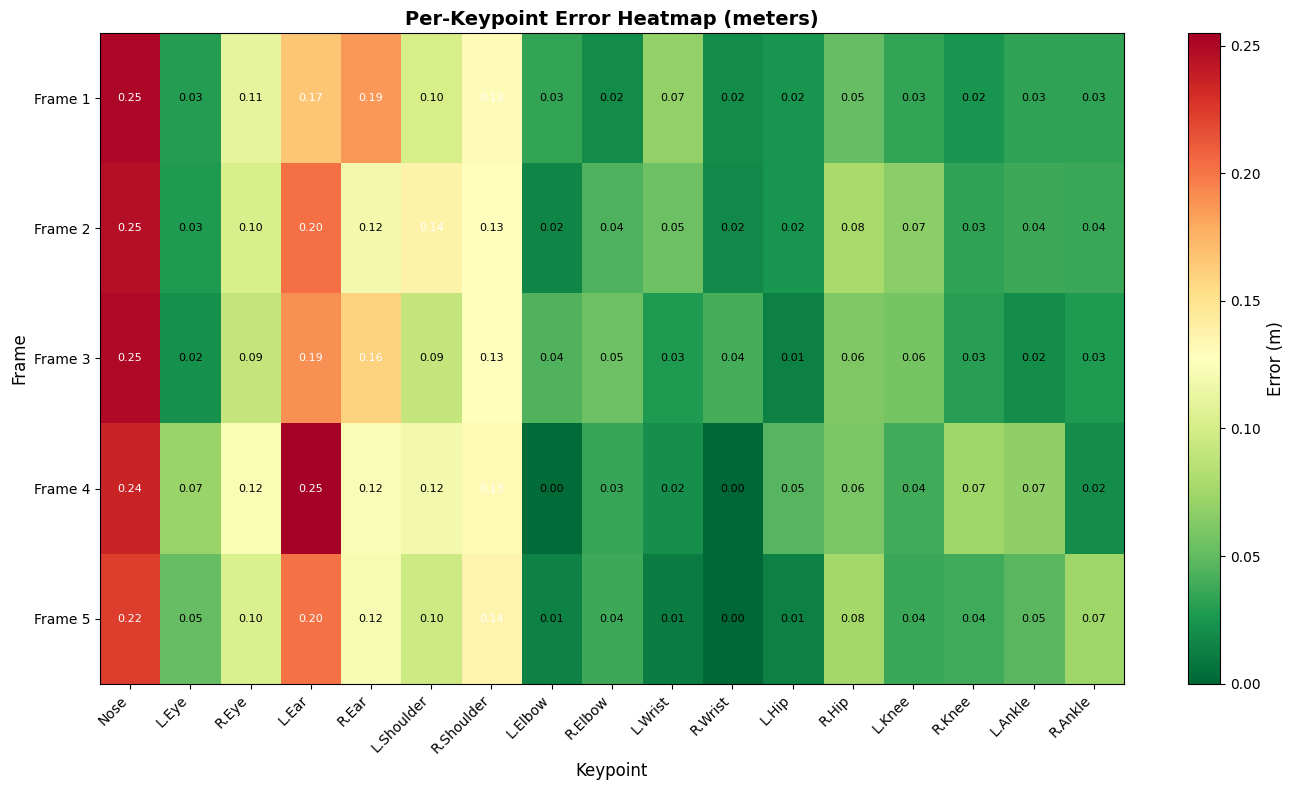

  ✓ Generated visualizations for kalman


In [26]:
# ============================================
# MODE 2: COMPARE ALL ARCHITECTURES
# ============================================

def run_compare_all():
    """Compare all architectures with support for staged training.
    
    This function trains all architectures and compares their performance.
    When ENABLE_STAGED_TRAINING is True, it performs two-stage curriculum learning:
    - Stage 1: Train localization
    - Stage 2: Train future prediction with progressive horizons
    
    All models and checkpoints are saved to OUTPUT_DIR.
    """
    print("="*70)
    print("COMPARING ALL ARCHITECTURES")
    print("="*70)
    
    # Reset random seeds for reproducibility
    set_random_seeds(RANDOM_SEED)
    print(f"Random seeds reset to {RANDOM_SEED}")
    
    config = ResidualConfig(output_dir=OUTPUT_DIR)
    device = config.get_device()
    print(f"Device: {device}")
    print(f"Staged Training: {ENABLE_STAGED_TRAINING}")
    print(f"Progressive Horizon: {ENABLE_PROGRESSIVE_HORIZON}")
    
    resource_monitor = ResourceMonitor(
        max_ram_gb=config.max_ram_gb,
        max_vram_gb=config.max_vram_gb
    ) if TRACK_RESOURCES else None
    
    output_path = Path(OUTPUT_DIR)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Load data
    print("\nLoading data...")
    gt_path = Path(GT_DIR)
    
    all_sequences = []
    for scene_dir in gt_path.iterdir():
        if scene_dir.is_dir() and not scene_dir.name.startswith('.'):
            print(f"  Loading {scene_dir.name}...")
            seqs = load_scene_data(GT_DIR, DET_DIR, scene_dir.name, config)
            all_sequences.extend(seqs)
    
    print(f"\nTotal sequences: {len(all_sequences)}")
    
    if len(all_sequences) < 5:
        print("Not enough sequences!")
        return None
    
    # Split (using shuffled copy to preserve reproducibility)
    rng = np.random.default_rng(RANDOM_SEED)
    shuffled_indices = rng.permutation(len(all_sequences))
    all_sequences = [all_sequences[i] for i in shuffled_indices]
    split_idx = int(len(all_sequences) * 0.8)
    train_sequences = all_sequences[:split_idx]
    val_sequences = all_sequences[split_idx:]
    
    print(f"Training: {len(train_sequences)}, Validation: {len(val_sequences)}")
    
    results = {}
    architectures = ['mlp', 'gru', 'lstm', 'mamba', 'kalman']
    all_histories = {}
    trained_models = {}
    trained_configs = {}
    trained_predictors = {}  # Store trajectory predictors for stage 2
    checkpoint_data = {}
    
    for arch in architectures:
        print(f"\n{'='*50}")
        print(f"Testing {arch.upper()}")
        print(f"{'='*50}")
        
        # Create architecture-specific config
        arch_config = ResidualConfig(
            output_dir=OUTPUT_DIR,
            architecture=arch
        )
        # Copy staged training settings
        arch_config.staged_training_enabled = ENABLE_STAGED_TRAINING
        arch_config.stage1_epochs = STAGE1_LOCALIZATION_EPOCHS
        arch_config.freeze_localization_in_stage2 = FREEZE_LOCALIZATION_IN_STAGE2
        arch_config.stage2_lr_multiplier = STAGE2_LEARNING_RATE_MULTIPLIER
        arch_config.prediction_horizon = PREDICTION_HORIZON
        arch_config.progressive_horizon_enabled = ENABLE_PROGRESSIVE_HORIZON
        arch_config.epochs_per_horizon = EPOCHS_PER_HORIZON
        arch_config.horizon_lr_decay = HORIZON_LR_DECAY
        
        model = create_corrector(arch_config)
        num_params = sum(p.numel() for p in model.parameters())
        print(f"Parameters: {num_params:,}")
        
        # Create architecture-specific output directory
        arch_output_dir = output_path / arch
        arch_output_dir.mkdir(parents=True, exist_ok=True)
        
        # Initialize checkpoint manager for this architecture
        checkpoint_manager = CheckpointManager(
            output_dir=arch_output_dir,
            save_interval=CHECKPOINT_INTERVAL
        ) if CHECKPOINT_INTERVAL > 0 else None
        
        # === TRAINING MODE SELECTION ===
        if ENABLE_STAGED_TRAINING and ENABLE_TRAJECTORY_PREDICTION:
            print(f"\n--- MULTI-STAGE CURRICULUM TRAINING for {arch.upper()} ---")
            
            # Create trajectory predictor for Stage 2
            trajectory_predictor = TrajectoryPredictor(arch_config)
            pred_params = sum(p.numel() for p in trajectory_predictor.parameters())
            print(f"Trajectory predictor parameters: {pred_params:,}")
            
            # Run multi-stage training with progressive horizon
            history = train_corrector_staged(
                model=model,
                train_sequences=train_sequences,
                val_sequences=val_sequences,
                config=arch_config,
                trajectory_predictor=trajectory_predictor,
                resource_monitor=resource_monitor,
                checkpoint_manager=checkpoint_manager
            )
            
            # Save staged model (both corrector and predictor)
            model_path = arch_output_dir / f'{arch}_staged_model.pt'
            torch.save({
                'corrector_state': model.state_dict(),
                'predictor_state': trajectory_predictor.state_dict(),
                'architecture': arch,
                'hidden_dim': arch_config.hidden_dim,
                'num_layers': arch_config.num_layers,
                'staged_training': True,
                'progressive_horizon': ENABLE_PROGRESSIVE_HORIZON,
                'prediction_horizon': PREDICTION_HORIZON,
                'history': history
            }, model_path)
            print(f"💾 Saved staged model: {model_path}")
            
            # Also save to root output dir for backward compatibility
            root_model_path = output_path / f'{arch}_staged_model.pt'
            torch.save({
                'corrector_state': model.state_dict(),
                'predictor_state': trajectory_predictor.state_dict(),
                'architecture': arch,
                'hidden_dim': arch_config.hidden_dim,
                'num_layers': arch_config.num_layers,
                'staged_training': True,
                'progressive_horizon': ENABLE_PROGRESSIVE_HORIZON,
                'prediction_horizon': PREDICTION_HORIZON,
                'history': history
            }, root_model_path)
            
            trained_predictors[arch] = trajectory_predictor
            
            # Extract stage1 history for backward compatibility
            stage1_history = history.get('stage1', history)
            
        else:
            # Standard training (not staged)
            print(f"\n--- STANDARD TRAINING for {arch.upper()} ---")
            
            history = train_corrector_with_checkpoints(
                model, train_sequences, val_sequences, arch_config, NUM_EPOCHS,
                resource_monitor=resource_monitor,
                checkpoint_manager=checkpoint_manager
            )
            stage1_history = history
            
            # Save model
            model_path = arch_output_dir / f'{arch}_model.pt'
            torch.save({
                'model_state': model.state_dict(),
                'architecture': arch,
                'hidden_dim': arch_config.hidden_dim,
                'num_layers': arch_config.num_layers,
                'history': history
            }, model_path)
            
            # Also save to root output dir
            root_model_path = output_path / f'{arch}_model.pt'
            torch.save({
                'model_state': model.state_dict(),
                'architecture': arch,
                'hidden_dim': arch_config.hidden_dim,
                'num_layers': arch_config.num_layers,
                'history': history
            }, root_model_path)
        
        all_histories[arch] = history
        
        # Calculate evaluation stats using stage1 history
        eval_stats = calculate_matching_statistics(model, val_sequences, arch_config)
        
        # Store checkpoint progress if available
        if checkpoint_manager and checkpoint_manager.checkpoints:
            checkpoint_data[arch] = checkpoint_manager.checkpoints
            # Save checkpoint summary
            checkpoint_manager.save_summary()
        
        # Store trained model and config for visualization
        trained_models[arch] = model
        trained_configs[arch] = arch_config
        
        # Extract best validation error from stage1 history
        val_errors = stage1_history.get('val_error', [float('inf')])
        best_val_error = min(val_errors) if val_errors else float('inf')
        
        results[arch] = {
            'num_params': num_params,
            'best_val_error': best_val_error,
            'baseline_error': stage1_history.get('val_baseline_error', [0])[-1] if stage1_history else 0,
            'history': history,
            'evaluation': eval_stats,
            'staged_training': ENABLE_STAGED_TRAINING,
            'has_predictor': arch in trained_predictors
        }
        
        # Save individual architecture history
        arch_history_path = arch_output_dir / f'{arch}_history.json'
        history_serializable = convert_history_to_serializable(history)
        with open(arch_history_path, 'w') as f:
            json.dump(history_serializable, f, indent=2)
        
        # Also save to root output dir
        root_history_path = output_path / f'{arch}_history.json'
        with open(root_history_path, 'w') as f:
            json.dump(history_serializable, f, indent=2)
    
    # Print comparison results
    print("\n" + "="*70)
    print("COMPARISON RESULTS")
    print("="*70)
    print(f"{'Architecture':<15} {'Params':<12} {'Val Error':<12} {'Baseline':<12} {'Improvement':<12} {'Staged':<8}")
    print("-"*80)
    
    for arch, res in results.items():
        baseline = res['baseline_error']
        val_err = res['best_val_error']
        imp = (baseline - val_err) / baseline * 100 if baseline > 0 else 0
        staged = "Yes" if res.get('staged_training', False) else "No"
        
        print(f"{arch:<15} {res['num_params']:<12,} {val_err:<12.4f} {baseline:<12.4f} {imp:>+11.1f}% {staged:<8}")
    
    # Print evaluation statistics
    print("\n" + "="*70)
    print("EVALUATION STATISTICS BY ARCHITECTURE")
    print("="*70)
    print(f"{'Architecture':<15} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Mean Error':<12}")
    print("-"*70)
    
    for arch, res in results.items():
        eval_s = res.get('evaluation', {})
        print(f"{arch:<15} {eval_s.get('precision', 0):<12.4f} {eval_s.get('recall', 0):<12.4f} "
              f"{eval_s.get('f1', 0):<12.4f} {eval_s.get('mean_position_error', 0):<12.4f}")
    
    # Save comparison results
    comp_path = output_path / 'comparison_results.json'
    comparison_data = {}
    for arch, res in results.items():
        arch_data = {k: convert_to_python(v) for k, v in res.items() if k != 'history'}
        if 'evaluation' in arch_data:
            arch_data['evaluation'] = {k: convert_to_python(v) for k, v in arch_data['evaluation'].items()}
        comparison_data[arch] = arch_data
    
    with open(comp_path, 'w') as f:
        json.dump(comparison_data, f, indent=2)
    print(f"\nSaved comparison to {comp_path}")
    
    # === VISUALIZATIONS ===
    print("\n" + "="*70)
    print("GENERATING COMPARISON VISUALIZATIONS")
    print("="*70)
    
    # Plot comparison charts
    plot_architecture_comparison(results, output_path)
    
    # Plot all histories on same axes for comparison
    plot_comparison_all_histories(all_histories, output_path, show=True)
    
    # Plot training histories for all architectures
    for arch, hist in all_histories.items():
        print(f"\n--- {arch.upper()} Training History ---")
        arch_output = output_path / arch / 'plots'
        arch_output.mkdir(parents=True, exist_ok=True)
        
        # For staged training, plot stage1 history
        if isinstance(hist, dict) and 'stage1' in hist:
            plot_training_history(hist['stage1'], arch_output, show=False)
            
            # Plot progressive horizon results if available
            if 'stage2' in hist and 'horizons' in hist['stage2']:
                plot_progressive_horizon_results(hist['stage2'], arch_output, show=False)
                print(f"  ✓ Saved progressive horizon results for {arch}")
        else:
            plot_training_history(hist, arch_output, show=False)
    
    # === CHECKPOINT PROGRESS VISUALIZATION ===
    if checkpoint_data:
        print("\n" + "="*70)
        print("CHECKPOINT PROGRESS ANALYSIS")
        print("="*70)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        ax = axes[0]
        colors = ARCH_COLORS
        
        for arch, checkpoints in checkpoint_data.items():
            epochs = [c['epoch'] for c in checkpoints]
            errors = [c.get('val_error', None) for c in checkpoints if c.get('val_error') is not None]
            valid_epochs = [c['epoch'] for c in checkpoints if c.get('val_error') is not None]
            if valid_epochs and errors:
                ax.plot(valid_epochs, errors, 'o-', color=colors.get(arch, 'gray'),
                       linewidth=2, markersize=8, label=arch.upper())
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Error (m)')
        ax.set_title('Checkpoint Evaluation Progress', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        ax = axes[1]
        ax.axis('off')
        
        table_data = []
        for arch, checkpoints in checkpoint_data.items():
            errors = [c.get('val_error', float('inf')) for c in checkpoints if c.get('val_error') is not None]
            if errors:
                table_data.append([
                    arch.upper(),
                    len(checkpoints),
                    f"{min(errors):.4f}",
                    f"{errors[-1]:.4f}" if errors else "N/A"
                ])
        
        if table_data:
            table = ax.table(
                cellText=table_data,
                colLabels=['Architecture', 'Checkpoints', 'Best Error', 'Final Error'],
                loc='center',
                cellLoc='center'
            )
            table.auto_set_font_size(False)
            table.set_fontsize(11)
            table.scale(1.2, 1.5)
        
        ax.set_title('Checkpoint Summary', fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(output_path / 'checkpoint_progress_comparison.png', dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {output_path / 'checkpoint_progress_comparison.png'}")
        plt.show()
        plt.close()
    
    # === PER-JOINT AND DIRECTION/SPEED ANALYSIS ===
    print("\n" + "="*70)
    print("PER-JOINT AND DIRECTION/SPEED ANALYSIS")
    print("="*70)
    
    # Run per-joint analysis on best architecture
    best_arch = min(results.keys(), key=lambda a: results[a]['best_val_error'])
    print(f"\nAnalyzing {best_arch.upper()}...")
    
    best_model = trained_models[best_arch]
    best_config = trained_configs[best_arch]
    
    # Per-joint errors
    per_joint_stats = calculate_per_joint_errors(
        best_model, val_sequences, best_config,
        prediction_horizon=PREDICTION_HORIZON if ENABLE_TRAJECTORY_PREDICTION else 0
    )
    
    # Save per-joint stats
    with open(output_path / 'per_joint_errors.json', 'w') as f:
        json.dump(per_joint_stats, f, indent=2)
    print(f"  ✓ Saved: {output_path / 'per_joint_errors.json'}")
    
    # Plot per-joint errors
    plot_per_joint_errors(per_joint_stats, output_path, show=True)
    
    # Direction and speed errors - include model name for clarity
    direction_speed_stats = calculate_direction_speed_errors(
        val_sequences, best_config,
        model_name=best_arch,
        epoch=-1,  # Final model (not per-epoch)
        horizon=0   # Current frame prediction
    )
    
    # Save direction/speed stats
    with open(output_path / 'direction_speed_errors.json', 'w') as f:
        json.dump(direction_speed_stats, f, indent=2)
    print(f"  ✓ Saved: {output_path / 'direction_speed_errors.json'}")
    
    # Plot direction/speed errors
    plot_direction_speed_errors(direction_speed_stats, output_path, show=True)
    
    # Plot errors per epoch per architecture (position, per-joint, speed, direction)
    plot_errors_per_epoch_per_architecture(all_histories, output_path, show=True)
    
    # Run threshold analysis on best architecture
    if RUN_THRESHOLD_ANALYSIS:
        print(f"\n=== Running threshold analysis on best architecture: {best_arch.upper()} ===")
        
        threshold_results = run_threshold_analysis(
            best_model, val_sequences, best_config,
            confidence_values=CONFIDENCE_VALUES,
            keypoint_values=KEYPOINT_VALUES,
            output_dir=output_path
        )
        plot_threshold_analysis(threshold_results, output_path, show=True)
    
    # === PEDESTRIAN TRACKING ON BEST MODEL ===
    if ENABLE_PEDESTRIAN_TRACKING:
        print("\n" + "="*70)
        print(f"PEDESTRIAN TRACKING WITH {best_arch.upper()}")
        print("="*70)
        
        tracker = PedestrianTracker(best_config)
        
        for seq in val_sequences[:10]:
            frames = seq.get('frames', [])
            for frame in frames:
                triangulated = np.array(frame.get('triangulated_3d', np.zeros((17, 3)))).reshape(-1, 3)
                confidences = np.array(frame.get('triangulated_conf', np.ones(17)))
                valid_mask = confidences >= best_config.min_confidence
                
                if valid_mask.sum() >= best_config.min_valid_keypoints:
                    skel = Skeleton3D(
                        keypoints=triangulated,
                        confidences=confidences,
                        valid_mask=valid_mask,
                        frame_idx=frame.get('frame_idx', 0)
                    )
                    tracker.update([skel], frame.get('frame_idx', 0))
        
        track_stats = tracker.get_statistics()
        print(f"\n📊 Tracking Statistics:")
        print(f"   Total Tracks: {track_stats['total_tracks_created']}")
        print(f"   Active: {track_stats['active_tracks']}")
        print(f"   Avg Length: {track_stats['avg_track_length']:.1f} frames")
        
        plot_tracking_statistics(tracker, output_path, show=True)
        
        if ENABLE_TRAJECTORY_PREDICTION:
            predictions = tracker.get_trajectory_predictions(horizon=PREDICTION_HORIZON)
            if predictions:
                plot_trajectory_predictions(tracker, predictions, output_path, show=True)
    
    # Return results along with models and validation sequences for visualization
    return {
        'results': results,
        'models': trained_models,
        'configs': trained_configs,
        'predictors': trained_predictors,
        'val_sequences': val_sequences,
        'all_histories': all_histories
    }


def convert_history_to_serializable(obj):
    """Convert training history to JSON-serializable format."""
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_history_to_serializable(v) for k, v in obj.items() if k != 'resource_usage'}
    elif isinstance(obj, list):
        return [convert_history_to_serializable(i) for i in obj]
    return obj


def convert_to_python(obj):
    """Convert numpy types to Python types."""
    if hasattr(obj, 'item'):
        return obj.item()
    if hasattr(obj, 'tolist'):
        return obj.tolist()
    return obj


def plot_architecture_comparison(results: Dict, output_dir: Path) -> None:
    """Plot architecture comparison visualizations."""
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    architectures = list(results.keys())
    colors = ARCH_COLORS
    
    # Plot 1: Model vs Baseline Error
    ax = axes[0]
    x = np.arange(len(architectures))
    width = 0.35
    
    val_errors = [results[arch]['best_val_error'] for arch in architectures]
    baseline_errors = [results[arch]['baseline_error'] for arch in architectures]
    
    bars1 = ax.bar(x - width/2, val_errors, width, label='Model Error', 
                   color=[colors.get(a, '#95a5a6') for a in architectures], alpha=0.8)
    bars2 = ax.bar(x + width/2, baseline_errors, width, label='Baseline Error',
                   color='#bdc3c7', alpha=0.8)
    
    ax.set_xlabel('Architecture', fontsize=12)
    ax.set_ylabel('Position Error (m)', fontsize=12)
    ax.set_title('Model vs Baseline Error', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([a.upper() for a in architectures])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Parameter count
    ax = axes[1]
    params = [results[arch]['num_params'] for arch in architectures]
    bars = ax.bar(architectures, params, color=[colors.get(a, '#95a5a6') for a in architectures], alpha=0.8)
    ax.set_xlabel('Architecture', fontsize=12)
    ax.set_ylabel('Number of Parameters', fontsize=12)
    ax.set_title('Model Complexity', fontsize=14, fontweight='bold')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Improvement percentage
    ax = axes[2]
    improvements = []
    for arch in architectures:
        baseline = results[arch]['baseline_error']
        val_err = results[arch]['best_val_error']
        imp = (baseline - val_err) / baseline * 100 if baseline > 0 else 0
        improvements.append(imp)
    
    bar_colors = ['#2ecc71' if imp >= 0 else '#e74c3c' for imp in improvements]
    bars = ax.bar(architectures, improvements, color=bar_colors, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Architecture', fontsize=12)
    ax.set_ylabel('Improvement (%)', fontsize=12)
    ax.set_title('Improvement Over Baseline', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'architecture_comparison.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {output_dir / 'architecture_comparison.png'}")
    plt.show()
    plt.close()


# Run comparison
if COMPARE_ALL_ARCHITECTURES:
    comparison_results = run_compare_all()
    
    # === BEST SEQUENCE VISUALIZATION FOR EACH ARCHITECTURE ===
    if comparison_results and 'models' in comparison_results:
        print("\n" + "="*70)
        print("GENERATING BEST SEQUENCE VISUALIZATIONS FOR ALL ARCHITECTURES")
        print("="*70)
        
        for arch, model in comparison_results['models'].items():
            print(f"\n--- {arch.upper()} Architecture ---")
            arch_output_dir = Path(OUTPUT_DIR) / arch / 'best_sequence'
            
            # Run best sequence visualization
            viz_result = run_best_sequence_visualization(
                model=model,
                sequences=comparison_results.get('val_sequences', []),
                config=comparison_results['configs'][arch],
                output_dir=arch_output_dir,
                num_consecutive_frames=5,
                show=True
            )
            
            if viz_result:
                print(f"  ✓ Generated visualizations for {arch}")
else:
    print("Skipping comparison mode (COMPARE_ALL_ARCHITECTURES is False)")
    print("Run the 'Mode 1' cell above instead.")
    